# 05 - Damage-Size Sensitivity Dataset Generation

**Origin:** Existing Notebook 05  
**Refactor status:** Finished       
**Validation status:** Finished       
**Completion gate passed:** Yes  
**Output root:** `outputs/05_damage_size_sensitivity_dataset_generation/`  
**Depends on:** Notebook 02 - Image Preprocessing; Notebook 03 - Canonical Mask Generation

## Purpose

Create a matched experimental dataset for evaluating how restoration behaviour changes as the damaged painting-content percentage increases.

The experiment uses:

- five explicitly pinned paintings, one from each controlled visual category;
- the canonical Notebook 03 `loss_large` mask for each painting;
- target damaged-content levels of 2%, 4%, 6%, 8%, 10%, 15%, and 20%;
- isotropic scaling about the actual base-mask centroid;
- strict nesting, so every smaller mask is a subset of the next larger mask;
- deterministic boundary correction to reach the rounded target pixel count;
- constant white RGB damage fill consistent with Notebook 04;
- normalized case and generation-audit tables;
- one compact matched-progression figure.

The expected design contains 35 cases: 5 paintings × 7 damage levels.

## Interpretation boundary

This notebook constructs and validates the controlled damage-size dataset.

It does not execute restoration models or calculate restoration-performance curves, PSNR, SSIM, LPIPS, feature similarity, colour fidelity, seam quality, perceptual realism, or model rankings. Those responsibilities belong to downstream notebooks.

## Batch 1 - Contract, Initialization, and Output Preflight

This batch:

- initializes the execution identity;
- loads the approved versioned configuration;
- resolves every explicit Notebook 02 and Notebook 03 input;
- loads the refreshed global inventory and project-path registry;
- declares the complete normalized input and output contracts;
- verifies the configured cohort, level and output cardinalities;
- verifies inventory coverage and absence of targeted legacy artifacts;
- verifies upstream and output ownership;
- performs exactly 12 consolidated blocking preflight checks;
- creates only the required Notebook 05 output directories.

No mask, damaged image, case table, audit table, figure, validation CSV, artifact manifest, or run manifest is written in this batch.

In [1]:
from pathlib import Path
import json
import platform
import sys

import pandas as pd
import PIL
import yaml


# ---------------------------------------------------------------------------
# Minimal import bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (
            candidate
            / "notebooks"
        ).is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration "
        f"repository root from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = (
    PROJECT_ROOT
    / "src"
)

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIRECTORY),
    )


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import (
    __version__ as PACKAGE_VERSION,
)

from restoration_eval.damage_sensitivity import (
    DAMAGE_SIZE_CONFIG_SCHEMA_VERSION,
    DAMAGE_SIZE_MODULE_VERSION,
    GENERATOR_VERSION,
    cohort_painting_ids,
    configured_levels,
    load_damage_size_config,
    resolve_damage_size_inputs,
    validate_damage_size_config,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    PROJECT_PATHS_MARKDOWN_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CANONICAL_MASKS_SCHEMA,
    DAMAGE_SIZE_CASES_SCHEMA,
    DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "05"

NOTEBOOK_STEM = (
    "05_damage_size_sensitivity_"
    "dataset_generation"
)

NOTEBOOK_NAME = (
    "Damage-Size Sensitivity "
    "Dataset Generation"
)

ORIGIN = "Existing Notebook 05"

PREPROCESSING_NOTEBOOK_STEM = (
    "02_image_preprocessing"
)

MASK_NOTEBOOK_STEM = (
    "03_canonical_mask_generation"
)

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "damage_size": (
        DAMAGE_SIZE_MODULE_VERSION
    ),
}

print(
    "Notebook:",
    f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}",
)

print(
    "Repository root:",
    PROJECT_ROOT,
)

print(
    "Run started:",
    RUN_STARTED_AT_UTC,
)

print(
    "Python:",
    platform.python_version(),
)

print(
    "pandas:",
    pd.__version__,
)

print(
    "Pillow:",
    PIL.__version__,
)

print(
    "PyYAML:",
    yaml.__version__,
)

print(
    "Damage-size generator:",
    GENERATOR_VERSION,
)

Notebook: 05 - Damage-Size Sensitivity Dataset Generation
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-19T17:48:48.070631Z
Python: 3.12.6
pandas: 2.3.3
Pillow: 9.5.0
PyYAML: 6.0.3
Damage-size generator: 3.0.0


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration
# ---------------------------------------------------------------------------

SENSITIVITY_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "damage_size_sensitivity.yaml"
)

sensitivity_config = (
    load_damage_size_config(
        SENSITIVITY_CONFIG_PATH
    )
)

sensitivity_input_paths = (
    resolve_damage_size_inputs(
        sensitivity_config,
        PROJECT_ROOT,
        must_exist=True,
    )
)


# ---------------------------------------------------------------------------
# Explicit Notebook 02 and Notebook 03 handoffs
# ---------------------------------------------------------------------------

UPSTREAM_GEOMETRY_PATH = (
    sensitivity_input_paths[
        "geometry_path"
    ]
)

UPSTREAM_CLEAN_IMAGE_DIRECTORY = (
    sensitivity_input_paths[
        "clean_images_path"
    ]
)

PREPROCESSING_ARTIFACT_MANIFEST_PATH = (
    sensitivity_input_paths[
        "preprocessing_artifacts_path"
    ]
)

PREPROCESSING_RUN_MANIFEST_PATH = (
    sensitivity_input_paths[
        "preprocessing_run_manifest_path"
    ]
)

UPSTREAM_MASKS_PATH = (
    sensitivity_input_paths[
        "masks_path"
    ]
)

UPSTREAM_MASK_IMAGE_DIRECTORY = (
    sensitivity_input_paths[
        "mask_images_path"
    ]
)

MASK_ARTIFACT_MANIFEST_PATH = (
    sensitivity_input_paths[
        "masks_artifacts_path"
    ]
)

MASK_RUN_MANIFEST_PATH = (
    sensitivity_input_paths[
        "masks_run_manifest_path"
    ]
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / (
        "05_damage_size_sensitivity_"
        "dataset_generation.ipynb"
    )
)


# ---------------------------------------------------------------------------
# Current inventory and global artifact registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_file:
    inventory_run = json.load(
        inventory_file
    )

project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

MASK_OUTPUT_DIRECTORY = (
    OUTPUT_ROOT
    / sensitivity_config[
        "output"
    ][
        "mask_directory"
    ]
)

DAMAGED_OUTPUT_DIRECTORY = (
    OUTPUT_ROOT
    / sensitivity_config[
        "output"
    ][
        "damaged_directory"
    ]
)

OUTPUT_PATHS = {
    "damage_size_cases": (
        OUTPUT_ROOT
        / sensitivity_config[
            "output"
        ][
            "cases_path"
        ]
    ),
    "damage_size_masks": (
        MASK_OUTPUT_DIRECTORY
    ),
    "damage_size_damaged_images": (
        DAMAGED_OUTPUT_DIRECTORY
    ),
    "damage_size_generation_audit": (
        OUTPUT_ROOT
        / sensitivity_config[
            "output"
        ][
            "audit_path"
        ]
    ),
    "damage_size_progression_figure": (
        OUTPUT_ROOT
        / sensitivity_config[
            "output"
        ][
            "progression_figure_path"
        ]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}

POST_GATE_PATHS = {
    "project_paths_json": (
        PROJECT_PATHS_JSON_PATH
    ),
    "project_paths_markdown": (
        PROJECT_PATHS_MARKDOWN_PATH
    ),
}


# ---------------------------------------------------------------------------
# Expected controlled-experiment cardinalities
# ---------------------------------------------------------------------------

EXPECTED_UPSTREAM_PAINTING_COUNT = 50
EXPECTED_UPSTREAM_MASK_COUNT = 250

EXPECTED_PAINTING_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "painting_count"
    ]
)

EXPECTED_CATEGORY_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "category_count"
    ]
)

EXPECTED_TARGET_LEVEL_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "target_level_count"
    ]
)

EXPECTED_CASE_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "case_count"
    ]
)

EXPECTED_AUDIT_ROW_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "audit_row_count"
    ]
)

EXPECTED_MASK_FILE_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "mask_file_count"
    ]
)

EXPECTED_DAMAGED_FILE_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "damaged_file_count"
    ]
)

EXPECTED_ARTIFACT_RECORD_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "artifact_record_count"
    ]
)

EXPECTED_TOTAL_OUTPUT_FILE_COUNT = int(
    sensitivity_config[
        "expected"
    ][
        "total_output_file_count"
    ]
)

COHORT_PAINTING_IDS = (
    cohort_painting_ids(
        sensitivity_config
    )
)

CONFIGURED_LEVELS = (
    configured_levels(
        sensitivity_config
    )
)

LEVEL_IDS = tuple(
    level_id
    for level_id, _ in CONFIGURED_LEVELS
)

TARGET_PERCENTAGES = tuple(
    percentage
    for _, percentage in CONFIGURED_LEVELS
)

BASE_MASK_TYPE = str(
    sensitivity_config[
        "cohort"
    ][
        "base_mask_type"
    ]
)


# ---------------------------------------------------------------------------
# Complete explicit input contract
# ---------------------------------------------------------------------------

INPUTS = {
    "damage_size_config": {
        "producer": (
            "project configuration"
        ),
        "relative_path": to_repo_relative(
            SENSITIVITY_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": (
            DAMAGE_SIZE_CONFIG_SCHEMA_VERSION
        ),
        "required_contract": (
            "complete versioned Notebook 05 "
            "configuration"
        ),
        "expected_cardinality": 1,
        "applicability": (
            "controlled_50; damage_size_sensitivity"
        ),
    },
    "project_inventory": {
        "producer": (
            "build_project_inventory.py"
        ),
        "relative_path": to_repo_relative(
            PROJECT_FILE_INVENTORY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            "project_file_inventory.v1"
        ),
        "required_contract": (
            "completed current inventory "
            "without read errors"
        ),
        "expected_cardinality": int(
            inventory_run[
                "summary"
            ][
                "file_count"
            ]
        ),
        "applicability": "repository",
    },
    "inventory_run": {
        "producer": (
            "build_project_inventory.py"
        ),
        "relative_path": to_repo_relative(
            INVENTORY_RUN_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "inventory_run.v1"
        ),
        "required_contract": (
            "completed run and matching "
            "inventory checksum"
        ),
        "expected_cardinality": 1,
        "applicability": "repository",
    },
    "project_paths_registry": {
        "producer": (
            "validated upstream notebooks"
        ),
        "relative_path": to_repo_relative(
            PROJECT_PATHS_JSON_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "project_paths.v1"
        ),
        "required_contract": tuple(
            sensitivity_config[
                "inputs"
            ][
                "required_registry_keys"
            ]
        ),
        "expected_cardinality": 1,
        "applicability": "repository",
    },
    "preprocessed_images": {
        "producer": (
            PREPROCESSING_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "required_contract": (
            PREPROCESSED_IMAGES_SCHEMA
            .required_columns
        ),
        "expected_cardinality": (
            EXPECTED_UPSTREAM_PAINTING_COUNT
        ),
        "applicability": "controlled_50",
    },
    "clean_images": {
        "producer": (
            PREPROCESSING_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "png_collection",
        "schema_version": (
            "clean_image_collection.v1"
        ),
        "required_contract": (
            "one validated RGB PNG per painting"
        ),
        "expected_cardinality": (
            EXPECTED_UPSTREAM_PAINTING_COUNT
        ),
        "applicability": "controlled_50",
    },
    "preprocessing_artifacts": {
        "producer": (
            PREPROCESSING_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            PREPROCESSING_ARTIFACT_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "required_contract": (
            ARTIFACT_MANIFEST_SCHEMA
            .required_columns
        ),
        "expected_cardinality": 5,
        "applicability": "controlled_50",
    },
    "preprocessing_run_manifest": {
        "producer": (
            PREPROCESSING_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            PREPROCESSING_RUN_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "run_manifest.v1"
        ),
        "required_contract": (
            "run_status=completed"
        ),
        "expected_cardinality": 1,
        "applicability": "controlled_50",
    },
    "canonical_masks": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_MASKS_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "required_contract": (
            CANONICAL_MASKS_SCHEMA
            .required_columns
        ),
        "expected_cardinality": (
            EXPECTED_UPSTREAM_MASK_COUNT
        ),
        "applicability": (
            "controlled_50; canonical_missing_region"
        ),
    },
    "canonical_mask_images": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_MASK_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "png_collection",
        "schema_version": (
            "canonical_mask_collection.v1"
        ),
        "required_contract": (
            "one validated binary PNG "
            "per canonical mask row"
        ),
        "expected_cardinality": (
            EXPECTED_UPSTREAM_MASK_COUNT
        ),
        "applicability": (
            "controlled_50; canonical_missing_region"
        ),
    },
    "mask_artifacts": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            MASK_ARTIFACT_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "required_contract": (
            ARTIFACT_MANIFEST_SCHEMA
            .required_columns
        ),
        "expected_cardinality": 7,
        "applicability": (
            "controlled_50; canonical_missing_region"
        ),
    },
    "mask_run_manifest": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            MASK_RUN_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": (
            "run_manifest.v1"
        ),
        "required_contract": (
            "run_status=completed"
        ),
        "expected_cardinality": 1,
        "applicability": (
            "controlled_50; canonical_missing_region"
        ),
    },
}


# ---------------------------------------------------------------------------
# Complete explicit output contract
# ---------------------------------------------------------------------------

DOWNSTREAM_NOTEBOOKS = (
    "08-12, 22, 25, 28, 32, and 33"
)

OUTPUTS = {
    "damage_size_cases": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "damage_size_cases"
            ],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            DAMAGE_SIZE_CASES_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_CASE_COUNT
        ),
        "artifact_role": (
            "primary_downstream"
        ),
        "downstream_consumers": (
            DOWNSTREAM_NOTEBOOKS
        ),
    },
    "damage_size_masks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "damage_size_masks"
            ],
            PROJECT_ROOT,
        ),
        "format": "png_collection",
        "schema_version": (
            "damage_size_mask_collection.v1"
        ),
        "expected_cardinality": (
            EXPECTED_MASK_FILE_COUNT
        ),
        "artifact_role": (
            "primary_downstream"
        ),
        "downstream_consumers": (
            DOWNSTREAM_NOTEBOOKS
        ),
    },
    "damage_size_damaged_images": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "damage_size_damaged_images"
            ],
            PROJECT_ROOT,
        ),
        "format": "png_collection",
        "schema_version": (
            "damage_size_damaged_collection.v1"
        ),
        "expected_cardinality": (
            EXPECTED_DAMAGED_FILE_COUNT
        ),
        "artifact_role": (
            "primary_downstream"
        ),
        "downstream_consumers": (
            DOWNSTREAM_NOTEBOOKS
        ),
    },
    "damage_size_generation_audit": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "damage_size_generation_audit"
            ],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA
            .version
        ),
        "expected_cardinality": (
            EXPECTED_AUDIT_ROW_COUNT
        ),
        "artifact_role": (
            "audit_reporting"
        ),
        "downstream_consumers": (
            "Notebook 08 and completion audit"
        ),
    },
    "damage_size_progression_figure": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "damage_size_progression_figure"
            ],
            PROJECT_ROOT,
        ),
        "format": "png",
        "schema_version": (
            "figure.damage_size_progression.v1"
        ),
        "expected_cardinality": 1,
        "artifact_role": (
            "thesis_reporting"
        ),
        "downstream_consumers": (
            "thesis and dashboard"
        ),
    },
    "validation_checks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "validation_checks"
            ],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "expected_cardinality": (
            "one consolidated validation table"
        ),
        "artifact_role": "validation",
        "downstream_consumers": (
            "completion audit"
        ),
    },
    "artifact_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "artifact_manifest"
            ],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "artifact_role": "manifest",
        "downstream_consumers": (
            "Notebook 08 and project registry"
        ),
    },
    "run_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "run_manifest"
            ],
            PROJECT_ROOT,
        ),
        "format": "json",
        "schema_version": (
            "run_manifest.v1"
        ),
        "expected_cardinality": 1,
        "artifact_role": "manifest",
        "downstream_consumers": (
            "Notebook 08 and completion audit"
        ),
    },
}

print(
    "Pinned paintings:",
    COHORT_PAINTING_IDS,
)

print(
    "Base mask type:",
    BASE_MASK_TYPE,
)

print(
    "Target percentages:",
    TARGET_PERCENTAGES,
)

print(
    "Expected cases:",
    EXPECTED_CASE_COUNT,
)

print(
    "Inventory run:",
    inventory_run[
        "inventory_run_id"
    ],
)

Pinned paintings: ('p001', 'p018', 'p026', 'p039', 'p043')
Base mask type: loss_large
Target percentages: (2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0)
Expected cases: 35
Inventory run: inventory_20260819T172830Z_5fa3bfd0


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 consolidated preflight validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


# 1. Supported Python runtime

observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="python_runtime",
    check_description=(
        "Python runtime is one of the "
        "provisionally supported versions."
    ),
    severity="blocking",
    expected=sorted(
        SUPPORTED_PYTHON_MINORS
    ),
    observed=observed_python_minor,
    passed=(
        observed_python_minor
        in SUPPORTED_PYTHON_MINORS
    ),
)


# 2. Versioned configuration contract

configuration_errors = (
    validate_damage_size_config(
        sensitivity_config
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="configuration_contract",
    check_description=(
        "Notebook 05 configuration satisfies "
        "damage_size_sensitivity_config.v1."
    ),
    severity="blocking",
    expected="zero configuration errors",
    observed=len(
        configuration_errors
    ),
    passed=not configuration_errors,
    details=configuration_errors,
)


# 3. Canonical notebook identity

legacy_notebook_path = (
    PROJECT_ROOT
    / "notebooks"
    / "05_damage_size_sensitivity_generation.ipynb"
)

extensionless_notebook_path = (
    PROJECT_ROOT
    / "notebooks"
    / NOTEBOOK_STEM
)

notebook_identity_passed = (
    NOTEBOOK_PATH.is_file()
    and NOTEBOOK_PATH.name
    == f"{NOTEBOOK_STEM}.ipynb"
    and not legacy_notebook_path.exists()
    and not extensionless_notebook_path.exists()
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="notebook_identity",
    check_description=(
        "Only the correctly named canonical "
        "Notebook 05 file is present."
    ),
    severity="blocking",
    expected={
        "canonical_notebook": (
            f"{NOTEBOOK_STEM}.ipynb"
        ),
        "legacy_notebook_present": False,
        "extensionless_notebook_present": False,
    },
    observed={
        "canonical_notebook_present": (
            NOTEBOOK_PATH.is_file()
        ),
        "legacy_notebook_present": (
            legacy_notebook_path.exists()
        ),
        "extensionless_notebook_present": (
            extensionless_notebook_path.exists()
        ),
    },
    passed=notebook_identity_passed,
)


# 4. Inventory run structure and consistency

REQUIRED_INVENTORY_COLUMNS = {
    "inventory_schema_version",
    "inventory_run_id",
    "relative_path",
    "format",
    "file_kind",
    "size_bytes",
    "read_error_count",
}

missing_inventory_columns = sorted(
    REQUIRED_INVENTORY_COLUMNS
    - set(inventory_df.columns)
)

inventory_run_ids = set(
    inventory_df[
        "inventory_run_id"
    ]
    .dropna()
    .astype(str)
)

inventory_read_error_count = int(
    pd.to_numeric(
        inventory_df[
            "read_error_count"
        ],
        errors="coerce",
    )
    .fillna(0)
    .sum()
)

inventory_run_passed = (
    inventory_run.get("status")
    == "completed"
    and inventory_run.get(
        "inventory_schema_version"
    )
    == "project_file_inventory.v1"
    and inventory_run.get(
        "run_schema_version"
    )
    == "inventory_run.v1"
    and inventory_run_ids
    == {
        inventory_run[
            "inventory_run_id"
        ]
    }
    and not missing_inventory_columns
    and inventory_read_error_count == 0
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_run",
    check_description=(
        "Inventory run is completed, "
        "internally consistent, and has "
        "no recorded read errors."
    ),
    severity="blocking",
    expected={
        "status": "completed",
        "inventory_schema": (
            "project_file_inventory.v1"
        ),
        "run_schema": "inventory_run.v1",
        "read_errors": 0,
    },
    observed={
        "status": inventory_run.get(
            "status"
        ),
        "inventory_schema": (
            inventory_run.get(
                "inventory_schema_version"
            )
        ),
        "run_schema": inventory_run.get(
            "run_schema_version"
        ),
        "inventory_run_ids": sorted(
            inventory_run_ids
        ),
        "missing_columns": (
            missing_inventory_columns
        ),
        "read_errors": (
            inventory_read_error_count
        ),
    },
    passed=inventory_run_passed,
)


# 5. Inventory checksum

observed_inventory_checksum = (
    sha256_file(
        PROJECT_FILE_INVENTORY_PATH
    )
)

expected_inventory_checksum = (
    inventory_run.get(
        "inventory_sha256",
        "",
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_checksum",
    check_description=(
        "Inventory CSV checksum matches "
        "its inventory run manifest."
    ),
    severity="blocking",
    expected=expected_inventory_checksum,
    observed=observed_inventory_checksum,
    passed=(
        observed_inventory_checksum
        == expected_inventory_checksum
    ),
)


# 6. Inventory coverage and targeted legacy absence

known_inventory_paths = set(
    inventory_df[
        "relative_path"
    ]
    .dropna()
    .astype(str)
)

declared_inventory_files = {
    to_repo_relative(
        SENSITIVITY_CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PREPROCESSING_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PREPROCESSING_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_MASKS_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        MASK_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        MASK_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PROJECT_PATHS_JSON_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        NOTEBOOK_PATH,
        PROJECT_ROOT,
    ),
    "src/restoration_eval/damage_sensitivity.py",
    "src/restoration_eval/schemas.py",
    "src/restoration_eval/paths.py",
    "src/restoration_eval/manifests.py",
    "src/restoration_eval/validation.py",
    "tests/test_damage_sensitivity.py",
}

missing_declared_inventory_files = sorted(
    declared_inventory_files
    - known_inventory_paths
)

clean_image_prefix = (
    to_repo_relative(
        UPSTREAM_CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ).rstrip("/")
    + "/"
)

canonical_mask_prefix = (
    to_repo_relative(
        UPSTREAM_MASK_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ).rstrip("/")
    + "/"
)

inventory_clean_images = sorted(
    path
    for path in known_inventory_paths
    if (
        path.startswith(
            clean_image_prefix
        )
        and path.lower().endswith(
            ".png"
        )
    )
)

inventory_canonical_masks = sorted(
    path
    for path in known_inventory_paths
    if (
        path.startswith(
            canonical_mask_prefix
        )
        and path.lower().endswith(
            ".png"
        )
    )
)

legacy_exact_paths = {
    (
        "notebooks/"
        "05_damage_size_sensitivity_generation.ipynb"
    ),
    (
        "notebooks/"
        "05_damage_size_sensitivity_"
        "dataset_generation"
    ),
    (
        "data/processed/metadata/"
        "metadata_damage_size_sensitivity.csv"
    ),
    (
        "outputs/reports/"
        "damage_size_sensitivity_manifest.json"
    ),
    (
        "outputs/reports/"
        "damage_size_sensitivity_report.md"
    ),
}

legacy_prefixes = (
    (
        "data/processed/masks/"
        "damage_size_sensitivity/"
    ),
    (
        "data/processed/damaged/"
        "damage_size_sensitivity/"
    ),
    "outputs/05_damage_size_sensitivity/",
    (
        "outputs/figures/"
        "damage_size_sensitivity/"
    ),
)

legacy_inventory_hits = sorted(
    path
    for path in known_inventory_paths
    if (
        path in legacy_exact_paths
        or any(
            path.startswith(prefix)
            for prefix in legacy_prefixes
        )
    )
)

inventory_coverage_passed = (
    not missing_declared_inventory_files
    and len(
        inventory_clean_images
    )
    == EXPECTED_UPSTREAM_PAINTING_COUNT
    and len(
        inventory_canonical_masks
    )
    == EXPECTED_UPSTREAM_MASK_COUNT
    and not legacy_inventory_hits
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_input_coverage",
    check_description=(
        "Inventory contains all declared "
        "inputs and preparation files while "
        "excluding targeted Notebook 05 "
        "legacy artifacts."
    ),
    severity="blocking",
    expected={
        "missing_declared_files": 0,
        "clean_images": (
            EXPECTED_UPSTREAM_PAINTING_COUNT
        ),
        "canonical_masks": (
            EXPECTED_UPSTREAM_MASK_COUNT
        ),
        "legacy_hits": 0,
    },
    observed={
        "missing_declared_files": (
            missing_declared_inventory_files
        ),
        "clean_images": len(
            inventory_clean_images
        ),
        "canonical_masks": len(
            inventory_canonical_masks
        ),
        "legacy_hits": (
            legacy_inventory_hits
        ),
    },
    passed=inventory_coverage_passed,
    details=(
        "The inventory CSV and inventory run "
        "JSON are intentionally excluded from "
        "inventory self-indexing and are "
        "validated directly."
    ),
)


# 7. Project paths registry structure

registry_errors = (
    validate_project_paths_registry(
        project_paths_registry
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="registry_schema",
    check_description=(
        "Global project paths registry "
        "satisfies project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry errors",
    observed=len(
        registry_errors
    ),
    passed=not registry_errors,
    details=registry_errors,
)


# Shared ownership utility

def collect_ownership_errors(
    named_paths,
    expected_root,
):
    errors = []

    for path_key, path_value in (
        named_paths.items()
    ):
        try:
            path_value.resolve().relative_to(
                expected_root.resolve()
            )
        except ValueError:
            errors.append(
                {
                    "path_key": path_key,
                    "path": str(
                        path_value
                    ),
                    "expected_parent": str(
                        expected_root
                    ),
                }
            )

    return errors


# 8. Notebook 02 and Notebook 03 input ownership

PREPROCESSING_OUTPUT_ROOT = (
    notebook_output_root(
        PREPROCESSING_NOTEBOOK_STEM,
        PROJECT_ROOT,
        create=False,
    )
)

MASK_OUTPUT_ROOT = (
    notebook_output_root(
        MASK_NOTEBOOK_STEM,
        PROJECT_ROOT,
        create=False,
    )
)

upstream_ownership_errors = []

upstream_ownership_errors.extend(
    collect_ownership_errors(
        {
            "preprocessed_images": (
                UPSTREAM_GEOMETRY_PATH
            ),
            "clean_images": (
                UPSTREAM_CLEAN_IMAGE_DIRECTORY
            ),
            "preprocessing_artifacts": (
                PREPROCESSING_ARTIFACT_MANIFEST_PATH
            ),
            "preprocessing_run_manifest": (
                PREPROCESSING_RUN_MANIFEST_PATH
            ),
        },
        PREPROCESSING_OUTPUT_ROOT,
    )
)

upstream_ownership_errors.extend(
    collect_ownership_errors(
        {
            "canonical_masks": (
                UPSTREAM_MASKS_PATH
            ),
            "canonical_mask_images": (
                UPSTREAM_MASK_IMAGE_DIRECTORY
            ),
            "mask_artifacts": (
                MASK_ARTIFACT_MANIFEST_PATH
            ),
            "mask_run_manifest": (
                MASK_RUN_MANIFEST_PATH
            ),
        },
        MASK_OUTPUT_ROOT,
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="upstream_output_ownership",
    check_description=(
        "Every Notebook 02 and Notebook 03 "
        "handoff remains inside its producing "
        "notebook output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(
        upstream_ownership_errors
    ),
    passed=not upstream_ownership_errors,
    details=upstream_ownership_errors,
)


# 9. Required registered upstream handoffs

registry_records_by_key = {
    record["artifact_key"]: record
    for record in (
        project_paths_registry[
            "artifacts"
        ]
    )
}

required_registry_expectations = {
    "preprocessing.geometry": {
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "row_count": 50,
        "file_count": 1,
    },
    "preprocessing.clean_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "clean_image_collection.v1"
        ),
        "row_count": 50,
        "file_count": 50,
    },
    "masks.canonical": {
        "relative_path": to_repo_relative(
            UPSTREAM_MASKS_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "row_count": 250,
        "file_count": 1,
    },
    "masks.canonical_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_MASK_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "canonical_mask_collection.v1"
        ),
        "row_count": 250,
        "file_count": 250,
    },
}

registry_handoff_errors = []

for (
    artifact_key,
    expectation,
) in required_registry_expectations.items():
    record = registry_records_by_key.get(
        artifact_key
    )

    if record is None:
        registry_handoff_errors.append(
            {
                "artifact_key": artifact_key,
                "issue": (
                    "missing_registry_record"
                ),
            }
        )
        continue

    mismatches = {}

    for field_name in (
        "relative_path",
        "schema_version",
        "row_count",
        "file_count",
    ):
        if record.get(
            field_name
        ) != expectation[
            field_name
        ]:
            mismatches[field_name] = {
                "expected": (
                    expectation[
                        field_name
                    ]
                ),
                "observed": record.get(
                    field_name
                ),
            }

    if (
        record.get(
            "validation_status"
        )
        != "passed"
    ):
        mismatches[
            "validation_status"
        ] = {
            "expected": "passed",
            "observed": record.get(
                "validation_status"
            ),
        }

    if mismatches:
        registry_handoff_errors.append(
            {
                "artifact_key": artifact_key,
                "mismatches": mismatches,
            }
        )

VALIDATION.add(
    validation_stage="preflight",
    check_id="registered_upstream_handoffs",
    check_description=(
        "Registry contains the four passed "
        "Notebook 02 and Notebook 03 primary "
        "handoffs required by Notebook 05."
    ),
    severity="blocking",
    expected={
        "required_keys": sorted(
            required_registry_expectations
        ),
        "error_count": 0,
    },
    observed={
        "present_keys": sorted(
            set(
                required_registry_expectations
            )
            & set(
                registry_records_by_key
            )
        ),
        "error_count": len(
            registry_handoff_errors
        ),
    },
    passed=not registry_handoff_errors,
    details=registry_handoff_errors,
)


# 10. Internal matched-design cardinalities

cohort_categories = tuple(
    str(record["category"])
    for record in (
        sensitivity_config[
            "cohort"
        ][
            "paintings"
        ]
    )
)

cardinality_observation = {
    "painting_count": len(
        COHORT_PAINTING_IDS
    ),
    "unique_painting_count": len(
        set(
            COHORT_PAINTING_IDS
        )
    ),
    "category_count": len(
        set(
            cohort_categories
        )
    ),
    "base_mask_type_count": 1,
    "target_level_count": len(
        CONFIGURED_LEVELS
    ),
    "case_count": (
        len(
            COHORT_PAINTING_IDS
        )
        * len(
            CONFIGURED_LEVELS
        )
    ),
    "mask_file_count": (
        EXPECTED_MASK_FILE_COUNT
    ),
    "damaged_file_count": (
        EXPECTED_DAMAGED_FILE_COUNT
    ),
    "artifact_record_count": (
        EXPECTED_ARTIFACT_RECORD_COUNT
    ),
    "total_output_file_count": (
        EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    ),
}

cardinality_expectation = {
    "painting_count": 5,
    "unique_painting_count": 5,
    "category_count": 5,
    "base_mask_type_count": 1,
    "target_level_count": 7,
    "case_count": 35,
    "mask_file_count": 35,
    "damaged_file_count": 35,
    "artifact_record_count": 6,
    "total_output_file_count": 76,
}

VALIDATION.add(
    validation_stage="preflight",
    check_id="matched_design_cardinality",
    check_description=(
        "Pinned cohort, category strata, "
        "target levels, cases, files, and "
        "artifact counts match the approved "
        "Notebook 05 design."
    ),
    severity="blocking",
    expected=cardinality_expectation,
    observed=cardinality_observation,
    passed=(
        cardinality_observation
        == cardinality_expectation
    ),
)


# 11. Notebook 05 output ownership

output_ownership_errors = []

for (
    output_key,
    output_path,
) in OUTPUT_PATHS.items():
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exception:
        output_ownership_errors.append(
            {
                "output_key": output_key,
                "error": str(
                    exception
                ),
            }
        )

VALIDATION.add(
    validation_stage="preflight",
    check_id="output_ownership",
    check_description=(
        "Every declared output belongs to "
        "the exact canonical Notebook 05 "
        "output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(
        output_ownership_errors
    ),
    passed=not output_ownership_errors,
    details=output_ownership_errors,
)


# 12. Existing stale or undeclared output files

declared_single_file_paths = {
    output_path.resolve()
    for output_key, output_path in (
        OUTPUT_PATHS.items()
    )
    if output_key not in {
        "damage_size_masks",
        "damage_size_damaged_images",
    }
}

expected_image_paths = set()

for painting_id in COHORT_PAINTING_IDS:
    for level_id in LEVEL_IDS:
        expected_image_paths.add(
            (
                MASK_OUTPUT_DIRECTORY
                / painting_id
                / f"{level_id}.png"
            ).resolve()
        )

        expected_image_paths.add(
            (
                DAMAGED_OUTPUT_DIRECTORY
                / painting_id
                / f"{level_id}.png"
            ).resolve()
        )

allowed_existing_files = (
    declared_single_file_paths
    | expected_image_paths
)

existing_output_files = (
    {
        path.resolve()
        for path in (
            OUTPUT_ROOT.rglob("*")
        )
        if path.is_file()
    }
    if OUTPUT_ROOT.exists()
    else set()
)

unexpected_existing_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        existing_output_files
        - allowed_existing_files
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="stale_outputs",
    check_description=(
        "Notebook 05 output root contains "
        "no undeclared, incorrectly nested, "
        "temporary, or legacy-named files."
    ),
    severity="blocking",
    expected=(
        "zero undeclared existing files"
    ),
    observed=len(
        unexpected_existing_files
    ),
    passed=not unexpected_existing_files,
    details=unexpected_existing_files,
)


# ---------------------------------------------------------------------------
# Stop before folder creation on any blocking failure
# ---------------------------------------------------------------------------

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Create only the approved Notebook 05 directories
# ---------------------------------------------------------------------------

OUTPUT_DIRECTORIES = (
    ensure_output_subdirs(
        NOTEBOOK_STEM,
        (
            "data",
            "images",
            "metrics",
            "figures",
            "manifests",
            "validation",
        ),
        PROJECT_ROOT,
    )
)

for directory in (
    MASK_OUTPUT_DIRECTORY,
    DAMAGED_OUTPUT_DIRECTORY,
):
    require_notebook_output_path(
        directory,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    ).mkdir(
        parents=True,
        exist_ok=True,
    )

OUTPUT_DIRECTORIES[
    "masks"
] = MASK_OUTPUT_DIRECTORY

OUTPUT_DIRECTORIES[
    "damaged"
] = DAMAGED_OUTPUT_DIRECTORY


# ---------------------------------------------------------------------------
# Concise preflight and contract summaries
# ---------------------------------------------------------------------------

preflight_checks_df = (
    VALIDATION.to_dataframe()
)

if len(
    preflight_checks_df
) != 12:
    raise RuntimeError(
        "Batch 1 must produce exactly "
        "12 preflight checks; observed "
        f"{len(preflight_checks_df)}."
    )

print(
    "Batch 1 preflight checks:"
)

display(
    preflight_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

input_contract_df = (
    pd.DataFrame.from_dict(
        INPUTS,
        orient="index",
    )
    .reset_index(
        names="input_key"
    )
)

output_contract_df = (
    pd.DataFrame.from_dict(
        OUTPUTS,
        orient="index",
    )
    .reset_index(
        names="output_key"
    )
)

print(
    "\nDeclared inputs:"
)

display(
    input_contract_df[
        [
            "input_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
            "applicability",
        ]
    ]
)

print(
    "\nDeclared outputs:"
)

display(
    output_contract_df[
        [
            "output_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
            "artifact_role",
        ]
    ]
)

print(
    "\nCreated or verified output directories:"
)

for (
    directory_key,
    directory_path,
) in OUTPUT_DIRECTORIES.items():
    print(
        f"  {directory_key}: "
        f"{to_repo_relative(directory_path, PROJECT_ROOT)}"
    )

print(
    "\nBatch 1 completed successfully."
)

print(
    "Preflight checks:",
    len(
        preflight_checks_df
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Pinned paintings:",
    COHORT_PAINTING_IDS,
)

print(
    "Target levels:",
    TARGET_PERCENTAGES,
)

print(
    "Expected cases:",
    EXPECTED_CASE_COUNT,
)

print(
    "No canonical scientific artifact "
    "has been written."
)

print(
    "Next approved stage: Batch 2 - "
    "validated upstream manifests, tables, "
    "foreign keys, and pinned cohort."
)

Batch 1 preflight checks:


,check_id,severity,expected,observed,passed
0,python_runtime,blocking,"[[3, 11], [3, 12]]","[3, 12]",True
1,configuration_contract,blocking,zero configuration errors,0,True
2,notebook_identity,blocking,"{""canonical_notebook"": ""05_damage_size_sensiti...","{""canonical_notebook_present"": true, ""extensio...",True
3,inventory_run,blocking,"{""inventory_schema"": ""project_file_inventory.v...","{""inventory_run_ids"": [""inventory_20260819T172...",True
4,inventory_checksum,blocking,6ca768009d000edd06f1d38f63bd5a5d434c347c6ba22d...,6ca768009d000edd06f1d38f63bd5a5d434c347c6ba22d...,True
5,inventory_input_coverage,blocking,"{""canonical_masks"": 250, ""clean_images"": 50, ""...","{""canonical_masks"": 250, ""clean_images"": 50, ""...",True
6,registry_schema,blocking,zero registry errors,0,True
7,upstream_output_ownership,blocking,zero ownership violations,0,True
8,registered_upstream_handoffs,blocking,"{""error_count"": 0, ""required_keys"": [""masks.ca...","{""error_count"": 0, ""present_keys"": [""masks.can...",True
9,matched_design_cardinality,blocking,"{""artifact_record_count"": 6, ""base_mask_type_c...","{""artifact_record_count"": 6, ""base_mask_type_c...",True



Declared inputs:


,input_key,relative_path,format,schema_version,expected_cardinality,applicability
0,damage_size_config,config/experiments/damage_size_sensitivity.yaml,yaml,damage_size_sensitivity_config.v1,1,controlled_50; damage_size_sensitivity
1,project_inventory,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,10948,repository
2,inventory_run,outputs/inventory/inventory_run.json,json,inventory_run.v1,1,repository
3,project_paths_registry,outputs/inventory/project_paths.json,json,project_paths.v1,1,repository
4,preprocessed_images,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50,controlled_50
5,clean_images,outputs/02_image_preprocessing/images/clean,png_collection,clean_image_collection.v1,50,controlled_50
6,preprocessing_artifacts,outputs/02_image_preprocessing/manifests/artif...,csv,artifact_manifest.v1,5,controlled_50
7,preprocessing_run_manifest,outputs/02_image_preprocessing/manifests/run_m...,json,run_manifest.v1,1,controlled_50
8,canonical_masks,outputs/03_canonical_mask_generation/data/mask...,csv,canonical_masks.v1,250,controlled_50; canonical_missing_region
9,canonical_mask_images,outputs/03_canonical_mask_generation/images/masks,png_collection,canonical_mask_collection.v1,250,controlled_50; canonical_missing_region



Declared outputs:


,output_key,relative_path,format,schema_version,expected_cardinality,artifact_role
0,damage_size_cases,outputs/05_damage_size_sensitivity_dataset_gen...,csv,damage_size_cases.v1,35,primary_downstream
1,damage_size_masks,outputs/05_damage_size_sensitivity_dataset_gen...,png_collection,damage_size_mask_collection.v1,35,primary_downstream
2,damage_size_damaged_images,outputs/05_damage_size_sensitivity_dataset_gen...,png_collection,damage_size_damaged_collection.v1,35,primary_downstream
3,damage_size_generation_audit,outputs/05_damage_size_sensitivity_dataset_gen...,csv,damage_size_generation_audit.v1,35,audit_reporting
4,damage_size_progression_figure,outputs/05_damage_size_sensitivity_dataset_gen...,png,figure.damage_size_progression.v1,1,thesis_reporting
5,validation_checks,outputs/05_damage_size_sensitivity_dataset_gen...,csv,validation_checks.v1,one consolidated validation table,validation
6,artifact_manifest,outputs/05_damage_size_sensitivity_dataset_gen...,csv,artifact_manifest.v1,6,manifest
7,run_manifest,outputs/05_damage_size_sensitivity_dataset_gen...,json,run_manifest.v1,1,manifest



Created or verified output directories:
  data: outputs/05_damage_size_sensitivity_dataset_generation/data
  images: outputs/05_damage_size_sensitivity_dataset_generation/images
  metrics: outputs/05_damage_size_sensitivity_dataset_generation/metrics
  figures: outputs/05_damage_size_sensitivity_dataset_generation/figures
  manifests: outputs/05_damage_size_sensitivity_dataset_generation/manifests
  validation: outputs/05_damage_size_sensitivity_dataset_generation/validation
  masks: outputs/05_damage_size_sensitivity_dataset_generation/images/masks
  damaged: outputs/05_damage_size_sensitivity_dataset_generation/images/damaged

Batch 1 completed successfully.
Preflight checks: 12
Blocking failures: 0
Pinned paintings: ('p001', 'p018', 'p026', 'p039', 'p043')
Target levels: (2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0)
Expected cases: 35
No canonical scientific artifact has been written.
Next approved stage: Batch 2 - validated upstream manifests, tables, foreign keys, and pinned cohort.


## Batch 2 - Validated Upstream Handoff and Pinned Cohort

This batch validates the complete Notebook 02 and Notebook 03 handoff before generating any sensitivity mask.

It will:

- load both upstream artifact manifests and run manifests;
- require both upstream completion gates to have passed;
- validate both artifact manifests against `artifact_manifest.v1`;
- verify required artifact paths, schemas, row counts, file counts, statuses, and checksums;
- validate the complete 50-row preprocessing table;
- validate the complete 250-row canonical-mask table;
- validate dataset identities, experiment identities, statuses, and foreign keys;
- select exactly the five configured paintings;
- select exactly one canonical `loss_large` base mask per painting;
- confirm that the pinned cohort represents five distinct configured visual categories;
- independently reload the five clean images and five base masks;
- verify dimensions, modes, formats, binary values, content support, recorded areas, and checksums;
- confirm the smoke and final-figure representative-selection policies;
- add exactly 20 consolidated Batch 2 checks.

No sensitivity mask, damaged image, case table, audit, figure, validation CSV, or manifest is written in this batch.

In [4]:
import numpy as np
from PIL import Image

from restoration_eval.damage_sensitivity import (
    select_sensitivity_cohort,
    validate_damage_size_handoff,
)

from restoration_eval.manifests import (
    sha256_path,
)

from restoration_eval.paths import (
    resolve_repo_path,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Load Notebook 02 and Notebook 03 manifests
# ---------------------------------------------------------------------------

preprocessing_artifacts_df = pd.read_csv(
    PREPROCESSING_ARTIFACT_MANIFEST_PATH,
)

mask_artifacts_df = pd.read_csv(
    MASK_ARTIFACT_MANIFEST_PATH,
)

with PREPROCESSING_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    preprocessing_run_manifest = json.load(
        manifest_file
    )

with MASK_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    mask_run_manifest = json.load(
        manifest_file
    )


# ---------------------------------------------------------------------------
# Load normalized Notebook 02 and Notebook 03 tables
# ---------------------------------------------------------------------------

preprocessed_images_df = pd.read_csv(
    UPSTREAM_GEOMETRY_PATH,
)

canonical_masks_df = pd.read_csv(
    UPSTREAM_MASKS_PATH,
)


# ---------------------------------------------------------------------------
# Select the pinned cohort through the validated helper contract
# ---------------------------------------------------------------------------

sensitivity_cohort_df = (
    select_sensitivity_cohort(
        preprocessed_images_df,
        canonical_masks_df,
        sensitivity_config,
    )
)

configured_category_by_painting = {
    str(record["painting_id"]): str(
        record["category"]
    )
    for record in (
        sensitivity_config[
            "cohort"
        ][
            "paintings"
        ]
    )
}

cohort_policy_df = (
    sensitivity_cohort_df[
        [
            "painting_id",
            "dataset_sort_index",
            "processed_image_id",
            "processed_path",
            "content_width",
            "content_height",
            "content_area_pixels",
            "base_mask_id",
            "base_mask_type",
            "base_mask_path",
            "base_mask_pixels",
            "base_damage_fraction",
        ]
    ]
    .copy()
)

cohort_policy_df.insert(
    1,
    "configured_category",
    cohort_policy_df[
        "painting_id"
    ].map(
        configured_category_by_painting
    ),
)


# ---------------------------------------------------------------------------
# Independent five-case source-image audit
# ---------------------------------------------------------------------------

source_file_records = []

for cohort_row in (
    sensitivity_cohort_df.itertuples(
        index=False
    )
):
    clean_path = resolve_repo_path(
        cohort_row.processed_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    base_mask_path = resolve_repo_path(
        cohort_row.base_mask_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    with Image.open(
        clean_path
    ) as clean_handle:
        clean_mode = clean_handle.mode
        clean_format = clean_handle.format
        clean_size = clean_handle.size

    with Image.open(
        base_mask_path
    ) as mask_handle:
        mask_mode = mask_handle.mode
        mask_format = mask_handle.format
        mask_size = mask_handle.size

        mask_array = np.asarray(
            mask_handle.convert("L"),
            dtype=np.uint8,
        )

    unique_values = sorted(
        np.unique(
            mask_array
        )
        .astype(int)
        .tolist()
    )

    binary_values_valid = (
        set(unique_values)
        .issubset(
            {
                0,
                255,
            }
        )
    )

    content_array = np.zeros(
        mask_array.shape,
        dtype=bool,
    )

    content_array[
        int(cohort_row.content_y_min):
        int(cohort_row.content_y_max),
        int(cohort_row.content_x_min):
        int(cohort_row.content_x_max),
    ] = True

    damaged_pixels = int(
        (
            mask_array
            == 255
        ).sum()
    )

    padding_overlap_pixels = int(
        (
            (
                mask_array
                == 255
            )
            & ~content_array
        ).sum()
    )

    source_file_records.append(
        {
            "painting_id": str(
                cohort_row.painting_id
            ),
            "configured_category": (
                configured_category_by_painting[
                    str(
                        cohort_row.painting_id
                    )
                ]
            ),
            "clean_file_exists": (
                clean_path.is_file()
            ),
            "base_mask_file_exists": (
                base_mask_path.is_file()
            ),
            "clean_width": int(
                clean_size[0]
            ),
            "clean_height": int(
                clean_size[1]
            ),
            "clean_mode": clean_mode,
            "clean_format": clean_format,
            "mask_width": int(
                mask_size[0]
            ),
            "mask_height": int(
                mask_size[1]
            ),
            "mask_mode": mask_mode,
            "mask_format": mask_format,
            "mask_unique_values": (
                "|".join(
                    str(value)
                    for value in unique_values
                )
            ),
            "binary_values_valid": (
                binary_values_valid
            ),
            "damaged_pixels": (
                damaged_pixels
            ),
            "metadata_damaged_pixels": int(
                cohort_row.base_mask_pixels
            ),
            "mask_pixels_match_metadata": (
                damaged_pixels
                == int(
                    cohort_row.base_mask_pixels
                )
            ),
            "padding_overlap_pixels": (
                padding_overlap_pixels
            ),
            "content_only_valid": (
                padding_overlap_pixels
                == 0
            ),
            "clean_sha256_matches": (
                sha256_file(
                    clean_path
                )
                == str(
                    cohort_row.clean_image_sha256
                )
            ),
            "base_mask_sha256_matches": (
                sha256_file(
                    base_mask_path
                )
                == str(
                    cohort_row.base_mask_sha256
                )
            ),
        }
    )

source_file_audit_df = pd.DataFrame(
    source_file_records
)


# ---------------------------------------------------------------------------
# Deterministic representative policies
# ---------------------------------------------------------------------------

content_area_order_df = (
    sensitivity_cohort_df
    .sort_values(
        [
            "content_area_pixels",
            "dataset_sort_index",
            "painting_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

observed_minimum_painting_id = str(
    content_area_order_df.iloc[
        0
    ][
        "painting_id"
    ]
)

observed_median_painting_id = str(
    content_area_order_df.iloc[
        len(
            content_area_order_df
        )
        // 2
    ][
        "painting_id"
    ]
)

observed_maximum_painting_id = str(
    content_area_order_df.iloc[
        -1
    ][
        "painting_id"
    ]
)

observed_example_painting_ids = (
    observed_minimum_painting_id,
    observed_median_painting_id,
    observed_maximum_painting_id,
)

configured_example_painting_ids = tuple(
    str(value)
    for value in (
        sensitivity_config[
            "examples"
        ][
            "painting_ids"
        ]
    )
)

configured_smoke_painting_id = str(
    sensitivity_config[
        "smoke"
    ][
        "painting_id"
    ]
)

print(
    "Preprocessed rows:",
    len(
        preprocessed_images_df
    ),
)

print(
    "Canonical mask rows:",
    len(
        canonical_masks_df
    ),
)

print(
    "Pinned cohort rows:",
    len(
        sensitivity_cohort_df
    ),
)

print(
    "Observed min/median/max paintings:",
    observed_example_painting_ids,
)

print(
    "Configured smoke painting:",
    configured_smoke_painting_id,
)

Preprocessed rows: 50
Canonical mask rows: 250
Pinned cohort rows: 5
Observed min/median/max paintings: ('p018', 'p039', 'p001')
Configured smoke painting: p039


In [5]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

BATCH_2_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_2_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "upstream_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1-2. Artifact-manifest schemas
# ---------------------------------------------------------------------------

preprocessing_artifact_schema_result = (
    validate_dataframe(
        preprocessing_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

preprocessing_artifact_schema_passed = (
    preprocessing_artifact_schema_result.passed
    and not (
        preprocessing_artifact_schema_result
        .unexpected_columns
    )
    and len(
        preprocessing_artifacts_df
    )
    == 5
)

add_batch_2_check(
    check_id=(
        "preprocessing_artifact_schema"
    ),
    description=(
        "Notebook 02 artifact manifest "
        "satisfies artifact_manifest.v1."
    ),
    expected={
        "schema": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "rows": 5,
        "unexpected_columns": 0,
    },
    observed={
        "rows": len(
            preprocessing_artifacts_df
        ),
        "missing_columns": (
            preprocessing_artifact_schema_result
            .missing_columns
        ),
        "unexpected_columns": (
            preprocessing_artifact_schema_result
            .unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            preprocessing_artifact_schema_result
            .duplicate_primary_key_rows
        ),
    },
    passed=(
        preprocessing_artifact_schema_passed
    ),
)

mask_artifact_schema_result = (
    validate_dataframe(
        mask_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

mask_artifact_schema_passed = (
    mask_artifact_schema_result.passed
    and not (
        mask_artifact_schema_result
        .unexpected_columns
    )
    and len(
        mask_artifacts_df
    )
    == 7
)

add_batch_2_check(
    check_id="mask_artifact_schema",
    description=(
        "Notebook 03 artifact manifest "
        "satisfies artifact_manifest.v1."
    ),
    expected={
        "schema": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "rows": 7,
        "unexpected_columns": 0,
    },
    observed={
        "rows": len(
            mask_artifacts_df
        ),
        "missing_columns": (
            mask_artifact_schema_result
            .missing_columns
        ),
        "unexpected_columns": (
            mask_artifact_schema_result
            .unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            mask_artifact_schema_result
            .duplicate_primary_key_rows
        ),
    },
    passed=mask_artifact_schema_passed,
)


# ---------------------------------------------------------------------------
# 3-4. Completed upstream run manifests
# ---------------------------------------------------------------------------

def run_manifest_errors(
    payload,
    expected_notebook_id,
):
    errors = []

    missing_keys = sorted(
        set(
            RUN_MANIFEST_REQUIRED_KEYS
        )
        - set(
            payload
        )
    )

    if missing_keys:
        errors.append(
            {
                "issue": (
                    "missing_required_keys"
                ),
                "keys": missing_keys,
            }
        )

    if str(
        payload.get(
            "notebook_id",
            "",
        )
    ) != str(
        expected_notebook_id
    ):
        errors.append(
            {
                "issue": (
                    "unexpected_notebook_id"
                ),
                "observed": payload.get(
                    "notebook_id"
                ),
            }
        )

    if payload.get(
        "run_status"
    ) != "completed":
        errors.append(
            {
                "issue": (
                    "run_not_completed"
                ),
                "observed": payload.get(
                    "run_status"
                ),
            }
        )

    completion_gate = (
        payload.get(
            "validation_summary",
            {},
        )
        .get(
            "completion_gate",
            {},
        )
    )

    if (
        completion_gate.get(
            "passed"
        )
        is not True
        or completion_gate.get(
            "status"
        )
        != "passed"
    ):
        errors.append(
            {
                "issue": (
                    "completion_gate_failed"
                ),
                "observed": (
                    completion_gate
                ),
            }
        )

    return errors


preprocessing_run_errors = (
    run_manifest_errors(
        preprocessing_run_manifest,
        "02",
    )
)

add_batch_2_check(
    check_id=(
        "preprocessing_run_manifest"
    ),
    description=(
        "Notebook 02 run manifest is "
        "complete and its completion gate "
        "passed."
    ),
    expected={
        "notebook_id": "02",
        "run_status": "completed",
        "completion_gate": "passed",
        "errors": 0,
    },
    observed={
        "notebook_id": (
            preprocessing_run_manifest
            .get(
                "notebook_id"
            )
        ),
        "run_status": (
            preprocessing_run_manifest
            .get(
                "run_status"
            )
        ),
        "errors": len(
            preprocessing_run_errors
        ),
    },
    passed=not preprocessing_run_errors,
    details=preprocessing_run_errors,
)

mask_run_errors = (
    run_manifest_errors(
        mask_run_manifest,
        "03",
    )
)

add_batch_2_check(
    check_id="mask_run_manifest",
    description=(
        "Notebook 03 run manifest is "
        "complete and its completion gate "
        "passed."
    ),
    expected={
        "notebook_id": "03",
        "run_status": "completed",
        "completion_gate": "passed",
        "errors": 0,
    },
    observed={
        "notebook_id": (
            mask_run_manifest.get(
                "notebook_id"
            )
        ),
        "run_status": (
            mask_run_manifest.get(
                "run_status"
            )
        ),
        "errors": len(
            mask_run_errors
        ),
    },
    passed=not mask_run_errors,
    details=mask_run_errors,
)


# ---------------------------------------------------------------------------
# Required artifact-record validation utility
# ---------------------------------------------------------------------------

def validate_required_artifacts(
    artifact_frame,
    expectations,
):
    record_errors = []
    integrity_errors = []

    for (
        artifact_key,
        expectation,
    ) in expectations.items():
        matching_rows = (
            artifact_frame.loc[
                artifact_frame[
                    "artifact_key"
                ]
                .astype(str)
                .eq(
                    artifact_key
                )
            ]
        )

        if len(
            matching_rows
        ) != 1:
            record_errors.append(
                {
                    "artifact_key": (
                        artifact_key
                    ),
                    "issue": (
                        "expected_exactly_one_record"
                    ),
                    "observed_rows": len(
                        matching_rows
                    ),
                }
            )
            continue

        record = matching_rows.iloc[
            0
        ]

        field_mismatches = {}

        if str(
            record[
                "relative_path"
            ]
        ) != str(
            expectation[
                "relative_path"
            ]
        ):
            field_mismatches[
                "relative_path"
            ] = {
                "expected": (
                    expectation[
                        "relative_path"
                    ]
                ),
                "observed": str(
                    record[
                        "relative_path"
                    ]
                ),
            }

        if str(
            record[
                "schema_version"
            ]
        ) != str(
            expectation[
                "schema_version"
            ]
        ):
            field_mismatches[
                "schema_version"
            ] = {
                "expected": (
                    expectation[
                        "schema_version"
                    ]
                ),
                "observed": str(
                    record[
                        "schema_version"
                    ]
                ),
            }

        observed_row_count = int(
            record[
                "row_count"
            ]
        )

        observed_file_count = int(
            record[
                "file_count"
            ]
        )

        if (
            observed_row_count
            != int(
                expectation[
                    "row_count"
                ]
            )
        ):
            field_mismatches[
                "row_count"
            ] = {
                "expected": int(
                    expectation[
                        "row_count"
                    ]
                ),
                "observed": (
                    observed_row_count
                ),
            }

        if (
            observed_file_count
            != int(
                expectation[
                    "file_count"
                ]
            )
        ):
            field_mismatches[
                "file_count"
            ] = {
                "expected": int(
                    expectation[
                        "file_count"
                    ]
                ),
                "observed": (
                    observed_file_count
                ),
            }

        if str(
            record[
                "validation_status"
            ]
        ) != "passed":
            field_mismatches[
                "validation_status"
            ] = {
                "expected": "passed",
                "observed": str(
                    record[
                        "validation_status"
                    ]
                ),
            }

        if field_mismatches:
            record_errors.append(
                {
                    "artifact_key": (
                        artifact_key
                    ),
                    "mismatches": (
                        field_mismatches
                    ),
                }
            )

        artifact_path = resolve_repo_path(
            str(
                record[
                    "relative_path"
                ]
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        expected_checksum = str(
            record[
                "checksum"
            ]
        )

        if (
            observed_checksum
            != expected_checksum
        ):
            integrity_errors.append(
                {
                    "artifact_key": (
                        artifact_key
                    ),
                    "path": str(
                        record[
                            "relative_path"
                        ]
                    ),
                    "expected_checksum": (
                        expected_checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    return (
        record_errors,
        integrity_errors,
    )


preprocessing_artifact_expectations = {
    "preprocessed_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "row_count": 50,
        "file_count": 1,
    },
    "clean_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "clean_image_collection.v1"
        ),
        "row_count": 50,
        "file_count": 50,
    },
}

mask_artifact_expectations = {
    "canonical_masks": {
        "relative_path": to_repo_relative(
            UPSTREAM_MASKS_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "row_count": 250,
        "file_count": 1,
    },
    "mask_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_MASK_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "canonical_mask_collection.v1"
        ),
        "row_count": 250,
        "file_count": 250,
    },
}

(
    preprocessing_record_errors,
    preprocessing_integrity_errors,
) = validate_required_artifacts(
    preprocessing_artifacts_df,
    preprocessing_artifact_expectations,
)

(
    mask_record_errors,
    mask_integrity_errors,
) = validate_required_artifacts(
    mask_artifacts_df,
    mask_artifact_expectations,
)


# ---------------------------------------------------------------------------
# 5-8. Required artifact records and checksums
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id=(
        "preprocessing_required_artifacts"
    ),
    description=(
        "Notebook 02 artifact manifest "
        "contains the required geometry and "
        "clean-image records with exact "
        "contract fields."
    ),
    expected={
        "required_keys": sorted(
            preprocessing_artifact_expectations
        ),
        "errors": 0,
    },
    observed={
        "present_keys": sorted(
            set(
                preprocessing_artifact_expectations
            )
            & set(
                preprocessing_artifacts_df[
                    "artifact_key"
                ].astype(str)
            )
        ),
        "errors": len(
            preprocessing_record_errors
        ),
    },
    passed=not preprocessing_record_errors,
    details=preprocessing_record_errors,
)

add_batch_2_check(
    check_id=(
        "mask_required_artifacts"
    ),
    description=(
        "Notebook 03 artifact manifest "
        "contains the required mask-table "
        "and mask-image records with exact "
        "contract fields."
    ),
    expected={
        "required_keys": sorted(
            mask_artifact_expectations
        ),
        "errors": 0,
    },
    observed={
        "present_keys": sorted(
            set(
                mask_artifact_expectations
            )
            & set(
                mask_artifacts_df[
                    "artifact_key"
                ].astype(str)
            )
        ),
        "errors": len(
            mask_record_errors
        ),
    },
    passed=not mask_record_errors,
    details=mask_record_errors,
)

add_batch_2_check(
    check_id=(
        "preprocessing_artifact_integrity"
    ),
    description=(
        "Notebook 02 geometry table and "
        "clean-image collection checksums "
        "match their artifact records."
    ),
    expected="zero checksum errors",
    observed=len(
        preprocessing_integrity_errors
    ),
    passed=not preprocessing_integrity_errors,
    details=preprocessing_integrity_errors,
)

add_batch_2_check(
    check_id=(
        "mask_artifact_integrity"
    ),
    description=(
        "Notebook 03 mask table and "
        "mask-image collection checksums "
        "match their artifact records."
    ),
    expected="zero checksum errors",
    observed=len(
        mask_integrity_errors
    ),
    passed=not mask_integrity_errors,
    details=mask_integrity_errors,
)


# ---------------------------------------------------------------------------
# 9-10. Normalized upstream table schemas
# ---------------------------------------------------------------------------

geometry_schema_result = (
    validate_dataframe(
        preprocessed_images_df,
        PREPROCESSED_IMAGES_SCHEMA,
        allow_extra_columns=False,
    )
)

geometry_schema_passed = (
    geometry_schema_result.passed
    and not (
        geometry_schema_result
        .unexpected_columns
    )
)

add_batch_2_check(
    check_id="geometry_schema",
    description=(
        "Notebook 02 table satisfies "
        "preprocessed_images.v1 exactly."
    ),
    expected={
        "schema": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "missing_columns": 0,
        "unexpected_columns": 0,
        "duplicate_keys": 0,
    },
    observed={
        "missing_columns": (
            geometry_schema_result
            .missing_columns
        ),
        "unexpected_columns": (
            geometry_schema_result
            .unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            geometry_schema_result
            .duplicate_primary_key_rows
        ),
    },
    passed=geometry_schema_passed,
)

canonical_mask_schema_result = (
    validate_dataframe(
        canonical_masks_df,
        CANONICAL_MASKS_SCHEMA,
        allow_extra_columns=False,
    )
)

canonical_mask_schema_passed = (
    canonical_mask_schema_result.passed
    and not (
        canonical_mask_schema_result
        .unexpected_columns
    )
)

add_batch_2_check(
    check_id="canonical_mask_schema",
    description=(
        "Notebook 03 table satisfies "
        "canonical_masks.v1 exactly."
    ),
    expected={
        "schema": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "missing_columns": 0,
        "unexpected_columns": 0,
        "duplicate_keys": 0,
    },
    observed={
        "missing_columns": (
            canonical_mask_schema_result
            .missing_columns
        ),
        "unexpected_columns": (
            canonical_mask_schema_result
            .unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            canonical_mask_schema_result
            .duplicate_primary_key_rows
        ),
    },
    passed=canonical_mask_schema_passed,
)


# ---------------------------------------------------------------------------
# 11. Complete upstream cardinalities
# ---------------------------------------------------------------------------

upstream_cardinality_observed = {
    "preprocessed_rows": len(
        preprocessed_images_df
    ),
    "unique_paintings": int(
        preprocessed_images_df[
            "painting_id"
        ].nunique()
    ),
    "canonical_mask_rows": len(
        canonical_masks_df
    ),
    "unique_mask_ids": int(
        canonical_masks_df[
            "mask_id"
        ].nunique()
    ),
    "mask_types": int(
        canonical_masks_df[
            "mask_type"
        ].nunique()
    ),
}

upstream_cardinality_expected = {
    "preprocessed_rows": 50,
    "unique_paintings": 50,
    "canonical_mask_rows": 250,
    "unique_mask_ids": 250,
    "mask_types": 5,
}

add_batch_2_check(
    check_id="upstream_cardinality",
    description=(
        "Complete Notebook 02 and Notebook 03 "
        "handoffs contain the expected "
        "controlled_50 cardinalities."
    ),
    expected=upstream_cardinality_expected,
    observed=upstream_cardinality_observed,
    passed=(
        upstream_cardinality_observed
        == upstream_cardinality_expected
    ),
)


# ---------------------------------------------------------------------------
# 12. Dataset identities and accepted statuses
# ---------------------------------------------------------------------------

configured_dataset_identity = {
    "dataset_id": str(
        sensitivity_config[
            "dataset"
        ][
            "dataset_id"
        ]
    ),
    "dataset_version": str(
        sensitivity_config[
            "dataset"
        ][
            "dataset_version"
        ]
    ),
    "dataset_scope": str(
        sensitivity_config[
            "dataset"
        ][
            "dataset_scope"
        ]
    ),
}

identity_status_errors = []

for (
    identity_key,
    expected_value,
) in configured_dataset_identity.items():
    if set(
        preprocessed_images_df[
            identity_key
        ].astype(str)
    ) != {
        expected_value
    }:
        identity_status_errors.append(
            {
                "table": (
                    "preprocessed_images"
                ),
                "field": identity_key,
                "observed": sorted(
                    set(
                        preprocessed_images_df[
                            identity_key
                        ].astype(str)
                    )
                ),
            }
        )

    if set(
        canonical_masks_df[
            identity_key
        ].astype(str)
    ) != {
        expected_value
    }:
        identity_status_errors.append(
            {
                "table": (
                    "canonical_masks"
                ),
                "field": identity_key,
                "observed": sorted(
                    set(
                        canonical_masks_df[
                            identity_key
                        ].astype(str)
                    )
                ),
            }
        )

if not (
    preprocessed_images_df[
        "status"
    ]
    .astype(str)
    .eq(
        "passed"
    )
    .all()
):
    identity_status_errors.append(
        {
            "table": (
                "preprocessed_images"
            ),
            "issue": (
                "nonpassed_status"
            ),
        }
    )

if not (
    canonical_masks_df[
        "generation_status"
    ]
    .astype(str)
    .eq(
        "passed"
    )
    .all()
    and canonical_masks_df[
        "status"
    ]
    .astype(str)
    .eq(
        "passed"
    )
    .all()
):
    identity_status_errors.append(
        {
            "table": (
                "canonical_masks"
            ),
            "issue": (
                "nonpassed_status"
            ),
        }
    )

if set(
    canonical_masks_df[
        "experiment_id"
    ].astype(str)
) != {
    "canonical_missing_region"
}:
    identity_status_errors.append(
        {
            "table": (
                "canonical_masks"
            ),
            "field": (
                "experiment_id"
            ),
            "observed": sorted(
                set(
                    canonical_masks_df[
                        "experiment_id"
                    ].astype(str)
                )
            ),
        }
    )

add_batch_2_check(
    check_id=(
        "dataset_identity_and_status"
    ),
    description=(
        "Upstream tables use the configured "
        "dataset identity and contain only "
        "accepted completed rows."
    ),
    expected={
        **configured_dataset_identity,
        "mask_experiment_id": (
            "canonical_missing_region"
        ),
        "errors": 0,
    },
    observed={
        "errors": len(
            identity_status_errors
        ),
    },
    passed=not identity_status_errors,
    details=identity_status_errors,
)


# ---------------------------------------------------------------------------
# 13. Complete helper-level handoff validation
# ---------------------------------------------------------------------------

damage_size_handoff_errors = (
    validate_damage_size_handoff(
        preprocessed_images_df,
        canonical_masks_df,
        sensitivity_config,
        PROJECT_ROOT,
        verify_files=True,
    )
)

add_batch_2_check(
    check_id=(
        "damage_size_handoff_contract"
    ),
    description=(
        "Versioned helper validates upstream "
        "schemas, identities, statuses, files, "
        "and Notebook 02/03 foreign keys."
    ),
    expected="zero handoff errors",
    observed=len(
        damage_size_handoff_errors
    ),
    passed=not damage_size_handoff_errors,
    details=damage_size_handoff_errors,
)


# ---------------------------------------------------------------------------
# 14. Exact pinned cohort
# ---------------------------------------------------------------------------

observed_cohort_ids = tuple(
    sensitivity_cohort_df[
        "painting_id"
    ].astype(str)
)

pinned_cohort_passed = (
    len(
        sensitivity_cohort_df
    )
    == EXPECTED_PAINTING_COUNT
    and observed_cohort_ids
    == COHORT_PAINTING_IDS
    and sensitivity_cohort_df[
        "painting_id"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
)

add_batch_2_check(
    check_id="pinned_cohort",
    description=(
        "Selected cohort contains exactly "
        "the five configured paintings in "
        "stable approved order."
    ),
    expected=COHORT_PAINTING_IDS,
    observed=observed_cohort_ids,
    passed=pinned_cohort_passed,
)


# ---------------------------------------------------------------------------
# 15. Configured balanced-category policy
# ---------------------------------------------------------------------------

observed_categories = tuple(
    cohort_policy_df[
        "configured_category"
    ].astype(str)
)

category_policy_passed = (
    len(
        observed_categories
    )
    == EXPECTED_CATEGORY_COUNT
    and len(
        set(
            observed_categories
        )
    )
    == EXPECTED_CATEGORY_COUNT
    and not (
        cohort_policy_df[
            "configured_category"
        ].isna().any()
    )
)

add_batch_2_check(
    check_id=(
        "balanced_category_policy"
    ),
    description=(
        "Pinned cohort contains one unique "
        "configured visual-category stratum "
        "per painting."
    ),
    expected={
        "category_count": 5,
        "unique_categories": 5,
        "missing_categories": 0,
    },
    observed={
        "category_count": len(
            observed_categories
        ),
        "unique_categories": len(
            set(
                observed_categories
            )
        ),
        "missing_categories": int(
            cohort_policy_df[
                "configured_category"
            ].isna().sum()
        ),
        "categories": (
            observed_categories
        ),
    },
    passed=category_policy_passed,
)


# ---------------------------------------------------------------------------
# 16. Exact canonical loss-large base masks
# ---------------------------------------------------------------------------

base_mask_contract_passed = (
    len(
        sensitivity_cohort_df
    )
    == EXPECTED_PAINTING_COUNT
    and sensitivity_cohort_df[
        "base_mask_id"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and sensitivity_cohort_df[
        "base_mask_type"
    ]
    .astype(str)
    .eq(
        BASE_MASK_TYPE
    )
    .all()
    and sensitivity_cohort_df[
        "base_mask_pixels"
    ]
    .astype(int)
    .gt(0)
    .all()
)

add_batch_2_check(
    check_id="base_mask_contract",
    description=(
        "Each pinned painting has exactly "
        "one distinct, non-empty canonical "
        "loss_large base mask."
    ),
    expected={
        "rows": 5,
        "unique_mask_ids": 5,
        "mask_type": "loss_large",
        "nonempty_masks": 5,
    },
    observed={
        "rows": len(
            sensitivity_cohort_df
        ),
        "unique_mask_ids": int(
            sensitivity_cohort_df[
                "base_mask_id"
            ].nunique()
        ),
        "mask_types": sorted(
            sensitivity_cohort_df[
                "base_mask_type"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "nonempty_masks": int(
            sensitivity_cohort_df[
                "base_mask_pixels"
            ]
            .astype(int)
            .gt(0)
            .sum()
        ),
    },
    passed=base_mask_contract_passed,
)


# ---------------------------------------------------------------------------
# 17-19. Independent source-file validation
# ---------------------------------------------------------------------------

source_files_passed = (
    source_file_audit_df[
        [
            "clean_file_exists",
            "base_mask_file_exists",
        ]
    ]
    .all(
        axis=None
    )
)

add_batch_2_check(
    check_id="source_files",
    description=(
        "All five pinned clean images and "
        "base-mask files exist."
    ),
    expected={
        "clean_files": 5,
        "base_mask_files": 5,
        "missing_files": 0,
    },
    observed={
        "clean_files": int(
            source_file_audit_df[
                "clean_file_exists"
            ].sum()
        ),
        "base_mask_files": int(
            source_file_audit_df[
                "base_mask_file_exists"
            ].sum()
        ),
        "missing_files": int(
            (
                ~source_file_audit_df[
                    [
                        "clean_file_exists",
                        "base_mask_file_exists",
                    ]
                ]
            )
            .sum()
            .sum()
        ),
    },
    passed=source_files_passed,
)

source_checksums_passed = (
    source_file_audit_df[
        [
            "clean_sha256_matches",
            "base_mask_sha256_matches",
        ]
    ]
    .all(
        axis=None
    )
)

add_batch_2_check(
    check_id="source_checksums",
    description=(
        "All pinned clean-image and base-mask "
        "SHA-256 values match normalized "
        "upstream metadata."
    ),
    expected={
        "clean_checksum_failures": 0,
        "base_mask_checksum_failures": 0,
    },
    observed={
        "clean_checksum_failures": int(
            (
                ~source_file_audit_df[
                    "clean_sha256_matches"
                ]
            ).sum()
        ),
        "base_mask_checksum_failures": int(
            (
                ~source_file_audit_df[
                    "base_mask_sha256_matches"
                ]
            ).sum()
        ),
    },
    passed=source_checksums_passed,
)

source_semantics_passed = (
    source_file_audit_df[
        "clean_width"
    ].eq(768).all()
    and source_file_audit_df[
        "clean_height"
    ].eq(768).all()
    and source_file_audit_df[
        "mask_width"
    ].eq(768).all()
    and source_file_audit_df[
        "mask_height"
    ].eq(768).all()
    and source_file_audit_df[
        "clean_mode"
    ].eq("RGB").all()
    and source_file_audit_df[
        "clean_format"
    ].eq("PNG").all()
    and source_file_audit_df[
        "mask_mode"
    ].eq("L").all()
    and source_file_audit_df[
        "mask_format"
    ].eq("PNG").all()
    and source_file_audit_df[
        "binary_values_valid"
    ].all()
    and source_file_audit_df[
        "mask_pixels_match_metadata"
    ].all()
    and source_file_audit_df[
        "content_only_valid"
    ].all()
)

add_batch_2_check(
    check_id=(
        "source_image_semantics"
    ),
    description=(
        "Pinned clean images and base masks "
        "satisfy dimensions, modes, formats, "
        "binary values, content support, and "
        "area reconciliation."
    ),
    expected={
        "dimensions": "768x768",
        "clean_mode": "RGB",
        "mask_mode": "L",
        "format": "PNG",
        "binary_failures": 0,
        "area_failures": 0,
        "padding_overlap_pixels": 0,
    },
    observed={
        "clean_sizes": sorted(
            set(
                zip(
                    source_file_audit_df[
                        "clean_width"
                    ],
                    source_file_audit_df[
                        "clean_height"
                    ],
                )
            )
        ),
        "mask_sizes": sorted(
            set(
                zip(
                    source_file_audit_df[
                        "mask_width"
                    ],
                    source_file_audit_df[
                        "mask_height"
                    ],
                )
            )
        ),
        "clean_modes": sorted(
            source_file_audit_df[
                "clean_mode"
            ].unique().tolist()
        ),
        "mask_modes": sorted(
            source_file_audit_df[
                "mask_mode"
            ].unique().tolist()
        ),
        "binary_failures": int(
            (
                ~source_file_audit_df[
                    "binary_values_valid"
                ]
            ).sum()
        ),
        "area_failures": int(
            (
                ~source_file_audit_df[
                    "mask_pixels_match_metadata"
                ]
            ).sum()
        ),
        "padding_overlap_pixels": int(
            source_file_audit_df[
                "padding_overlap_pixels"
            ].sum()
        ),
    },
    passed=source_semantics_passed,
)


# ---------------------------------------------------------------------------
# 20. Smoke and final-figure representative policies
# ---------------------------------------------------------------------------

representative_policy_passed = (
    configured_smoke_painting_id
    == observed_median_painting_id
    and configured_example_painting_ids
    == observed_example_painting_ids
)

add_batch_2_check(
    check_id=(
        "representative_selection_policy"
    ),
    description=(
        "Configured smoke and figure paintings "
        "match the deterministic median and "
        "minimum/median/maximum content-area "
        "selection rules."
    ),
    expected={
        "smoke": (
            observed_median_painting_id
        ),
        "examples": (
            observed_example_painting_ids
        ),
    },
    observed={
        "smoke": (
            configured_smoke_painting_id
        ),
        "examples": (
            configured_example_painting_ids
        ),
    },
    passed=representative_policy_passed,
)


# ---------------------------------------------------------------------------
# Batch 2 completion gate and rendered evidence
# ---------------------------------------------------------------------------

BATCH_2_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_2_START_CHECK_COUNT
)

if BATCH_2_CHECK_COUNT != 20:
    raise RuntimeError(
        "Batch 2 must add exactly 20 checks; "
        f"observed {BATCH_2_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_2_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_2_START_CHECK_COUNT:
    ]
    .reset_index(drop=True)
)

print(
    "Batch 2 validation checks:"
)

display(
    batch_2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nPinned matched cohort:"
)

display(
    cohort_policy_df[
        [
            "painting_id",
            "configured_category",
            "content_width",
            "content_height",
            "content_area_pixels",
            "base_mask_id",
            "base_mask_pixels",
            "base_damage_fraction",
        ]
    ]
)

print(
    "\nIndependent source-file audit:"
)

display(
    source_file_audit_df[
        [
            "painting_id",
            "clean_mode",
            "mask_mode",
            "mask_unique_values",
            "damaged_pixels",
            "metadata_damaged_pixels",
            "padding_overlap_pixels",
            "clean_sha256_matches",
            "base_mask_sha256_matches",
        ]
    ]
)

print(
    "\nBatch 2 completed successfully."
)

print(
    "Batch 2 checks:",
    BATCH_2_CHECK_COUNT,
)

print(
    "Total checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Pinned cohort rows:",
    len(
        sensitivity_cohort_df
    ),
)

print(
    "Selected base masks:",
    sensitivity_cohort_df[
        "base_mask_id"
    ].nunique(),
)

print(
    "No sensitivity output artifact "
    "has been written."
)

print(
    "Next approved stage: Batch 3 - "
    "deterministic in-memory seven-level "
    "smoke generation."
)

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,preprocessing_artifact_schema,blocking,"{""rows"": 5, ""schema"": ""artifact_manifest.v1"", ...","{""duplicate_primary_key_rows"": 0, ""missing_col...",True
1,mask_artifact_schema,blocking,"{""rows"": 7, ""schema"": ""artifact_manifest.v1"", ...","{""duplicate_primary_key_rows"": 0, ""missing_col...",True
2,preprocessing_run_manifest,blocking,"{""completion_gate"": ""passed"", ""errors"": 0, ""no...","{""errors"": 0, ""notebook_id"": ""02"", ""run_status...",True
3,mask_run_manifest,blocking,"{""completion_gate"": ""passed"", ""errors"": 0, ""no...","{""errors"": 0, ""notebook_id"": ""03"", ""run_status...",True
4,preprocessing_required_artifacts,blocking,"{""errors"": 0, ""required_keys"": [""clean_images""...","{""errors"": 0, ""present_keys"": [""clean_images"",...",True
5,mask_required_artifacts,blocking,"{""errors"": 0, ""required_keys"": [""canonical_mas...","{""errors"": 0, ""present_keys"": [""canonical_mask...",True
6,preprocessing_artifact_integrity,blocking,zero checksum errors,0,True
7,mask_artifact_integrity,blocking,zero checksum errors,0,True
8,geometry_schema,blocking,"{""duplicate_keys"": 0, ""missing_columns"": 0, ""s...","{""duplicate_primary_key_rows"": 0, ""missing_col...",True
9,canonical_mask_schema,blocking,"{""duplicate_keys"": 0, ""missing_columns"": 0, ""s...","{""duplicate_primary_key_rows"": 0, ""missing_col...",True



Pinned matched cohort:


,painting_id,configured_category,content_width,content_height,content_area_pixels,base_mask_id,base_mask_pixels,base_damage_fraction
0,p001,portrait_figure,663,768,509184,mask__canonical__p001__loss_large,70792,0.139030
1,p018,landscape_natural,768,507,389376,mask__canonical__p018__loss_large,46039,0.118238
2,p026,architecture_structured,768,529,406272,mask__canonical__p026__loss_large,43455,0.106960
3,p039,abstraction_surrealism,768,564,433152,mask__canonical__p039__loss_large,49001,0.113127
4,p043,high_texture_brushwork,768,611,469248,mask__canonical__p043__loss_large,65809,0.140244



Independent source-file audit:


,painting_id,clean_mode,mask_mode,mask_unique_values,damaged_pixels,metadata_damaged_pixels,padding_overlap_pixels,clean_sha256_matches,base_mask_sha256_matches
0,p001,RGB,L,0|255,70792,70792,0,True,True
1,p018,RGB,L,0|255,46039,46039,0,True,True
2,p026,RGB,L,0|255,43455,43455,0,True,True
3,p039,RGB,L,0|255,49001,49001,0,True,True
4,p043,RGB,L,0|255,65809,65809,0,True,True



Batch 2 completed successfully.
Batch 2 checks: 20
Total checks: 32
Blocking failures: 0
Pinned cohort rows: 5
Selected base masks: 5
No sensitivity output artifact has been written.
Next approved stage: Batch 3 - deterministic in-memory seven-level smoke generation.


## Batch 3 - Deterministic In-Memory Seven-Level Smoke Generation

This batch tests the complete damage-size generator on the configured median-content painting, `p039`, without writing any scientific artifact.

It will:

- load the validated clean image and canonical `loss_large` base mask for `p039`;
- generate all seven configured target levels twice;
- require byte-identical mask arrays and identical deterministic seeds across repetitions;
- require exact rounded target pixel counts;
- require strict subset nesting between consecutive levels;
- apply the canonical white damage fill entirely in memory;
- verify binary values, content containment, dimensions, modes, and pixel integrity;
- measure centroid, bounding-box, compactness, component, and boundary drift;
- render an in-notebook mask and damaged-image progression;
- verify that no file was written under the Notebook 05 output root;
- add exactly 20 consolidated Batch 3 checks.

The rendered figure is notebook-only evidence. The canonical progression figure is produced later from independently reloaded full-generation outputs.

In [6]:
import matplotlib.pyplot as plt

from restoration_eval.damage import (
    apply_mask_damage,
)

from restoration_eval.damage_sensitivity import (
    generate_nested_mask_series,
)

from restoration_eval.masks import (
    calculate_mask_morphology,
)


# ---------------------------------------------------------------------------
# Snapshot Notebook 05 files before in-memory smoke generation
# ---------------------------------------------------------------------------

batch_3_files_before = {
    path.resolve()
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Resolve the configured smoke painting
# ---------------------------------------------------------------------------

smoke_cohort_rows = (
    sensitivity_cohort_df.loc[
        sensitivity_cohort_df[
            "painting_id"
        ]
        .astype(str)
        .eq(
            configured_smoke_painting_id
        )
    ]
)

if len(
    smoke_cohort_rows
) != 1:
    raise RuntimeError(
        "Expected exactly one configured "
        "smoke-painting row; observed "
        f"{len(smoke_cohort_rows)}."
    )

smoke_cohort_row = (
    smoke_cohort_rows.iloc[
        0
    ]
)

SMOKE_PAINTING_ID = str(
    smoke_cohort_row[
        "painting_id"
    ]
)

SMOKE_CLEAN_PATH = resolve_repo_path(
    str(
        smoke_cohort_row[
            "processed_path"
        ]
    ),
    PROJECT_ROOT,
    must_exist=True,
)

SMOKE_BASE_MASK_PATH = (
    resolve_repo_path(
        str(
            smoke_cohort_row[
                "base_mask_path"
            ]
        ),
        PROJECT_ROOT,
        must_exist=True,
    )
)

SMOKE_CONTENT_BOX = (
    int(
        smoke_cohort_row[
            "content_x_min"
        ]
    ),
    int(
        smoke_cohort_row[
            "content_y_min"
        ]
    ),
    int(
        smoke_cohort_row[
            "content_x_max"
        ]
    ),
    int(
        smoke_cohort_row[
            "content_y_max"
        ]
    ),
)

SMOKE_CONTENT_AREA_PIXELS = int(
    smoke_cohort_row[
        "content_area_pixels"
    ]
)

with Image.open(
    SMOKE_CLEAN_PATH
) as image_handle:
    smoke_clean_image = (
        image_handle
        .convert("RGB")
        .copy()
    )

with Image.open(
    SMOKE_BASE_MASK_PATH
) as mask_handle:
    smoke_base_mask_image = (
        mask_handle
        .convert("L")
        .copy()
    )

smoke_clean_array = np.asarray(
    smoke_clean_image,
    dtype=np.uint8,
)

smoke_base_mask_array = (
    np.asarray(
        smoke_base_mask_image,
        dtype=np.uint8,
    )
    == 255
)

smoke_content_array = np.zeros(
    smoke_base_mask_array.shape,
    dtype=bool,
)

smoke_content_array[
    SMOKE_CONTENT_BOX[1]:
    SMOKE_CONTENT_BOX[3],
    SMOKE_CONTENT_BOX[0]:
    SMOKE_CONTENT_BOX[2],
] = True

SMOKE_FILL_COLOR = tuple(
    int(value)
    for value in (
        sensitivity_config[
            "generator"
        ][
            "fill_color_rgb"
        ]
    )
)

smoke_fill_array = np.asarray(
    SMOKE_FILL_COLOR,
    dtype=np.uint8,
)


# ---------------------------------------------------------------------------
# Generate the complete sequence twice
# ---------------------------------------------------------------------------

smoke_generation_kwargs = {
    "content_bbox": (
        SMOKE_CONTENT_BOX
    ),
    "content_area_pixels": (
        SMOKE_CONTENT_AREA_PIXELS
    ),
    "levels": CONFIGURED_LEVELS,
    "global_seed": int(
        sensitivity_config[
            "generator"
        ][
            "global_seed"
        ]
    ),
    "seed_scheme_version": str(
        sensitivity_config[
            "generator"
        ][
            "seed_scheme_version"
        ]
    ),
    "painting_id": (
        SMOKE_PAINTING_ID
    ),
    "base_mask_sha256": str(
        smoke_cohort_row[
            "base_mask_sha256"
        ]
    ),
    "maximum_iterations": int(
        sensitivity_config[
            "generator"
        ][
            "maximum_scale_iterations"
        ]
    ),
}

smoke_series_first = (
    generate_nested_mask_series(
        smoke_base_mask_image,
        **smoke_generation_kwargs,
    )
)

smoke_series_second = (
    generate_nested_mask_series(
        smoke_base_mask_image,
        **smoke_generation_kwargs,
    )
)


# ---------------------------------------------------------------------------
# Morphology and pixel-integrity evidence
# ---------------------------------------------------------------------------

def binary_centroid(
    binary_array,
):
    y_values, x_values = np.nonzero(
        binary_array
    )

    if not len(
        x_values
    ):
        raise ValueError(
            "Cannot calculate the centroid "
            "of an empty mask."
        )

    return (
        float(
            x_values.mean()
        ),
        float(
            y_values.mean()
        ),
    )


def relative_drift(
    observed,
    reference,
):
    return (
        abs(
            float(observed)
            - float(reference)
        )
        / max(
            abs(
                float(reference)
            ),
            1e-12,
        )
    )


smoke_base_morphology = (
    calculate_mask_morphology(
        smoke_base_mask_image,
        content_box=(
            SMOKE_CONTENT_BOX
        ),
    )
)

smoke_base_centroid = (
    binary_centroid(
        smoke_base_mask_array
    )
)

smoke_content_diagonal = float(
    np.hypot(
        int(
            smoke_cohort_row[
                "content_width"
            ]
        ),
        int(
            smoke_cohort_row[
                "content_height"
            ]
        ),
    )
)

smoke_masks_by_level = {}
smoke_damaged_by_level = {}
smoke_records = []

previous_mask_array = None
previous_level_id = ""

for (
    first_result,
    second_result,
) in zip(
    smoke_series_first,
    smoke_series_second,
):
    level_id = str(
        first_result[
            "level_id"
        ]
    )

    target_percentage = float(
        first_result[
            "target_percentage_content"
        ]
    )

    first_mask_array = (
        first_result[
            "mask"
        ]
        .astype(bool)
    )

    second_mask_array = (
        second_result[
            "mask"
        ]
        .astype(bool)
    )

    smoke_mask_image = (
        Image.fromarray(
            (
                first_mask_array
                .astype(np.uint8)
                * 255
            ),
            mode="L",
        )
    )

    smoke_damaged_image = (
        apply_mask_damage(
            smoke_clean_image,
            smoke_mask_image,
            SMOKE_FILL_COLOR,
        )
    )

    smoke_damaged_array = np.asarray(
        smoke_damaged_image,
        dtype=np.uint8,
    )

    changed_array = np.any(
        smoke_clean_array
        != smoke_damaged_array,
        axis=2,
    )

    preexisting_fill_array = (
        np.all(
            smoke_clean_array
            == smoke_fill_array,
            axis=2,
        )
        & first_mask_array
    )

    expected_changed_pixels = int(
        first_mask_array.sum()
        - preexisting_fill_array.sum()
    )

    observed_changed_pixels = int(
        changed_array.sum()
    )

    outside_mask_changed_pixels = int(
        (
            changed_array
            & ~first_mask_array
        ).sum()
    )

    inside_mask_not_fill_pixels = int(
        np.any(
            smoke_damaged_array[
                first_mask_array
            ]
            != smoke_fill_array,
            axis=1,
        ).sum()
    )

    smoke_morphology = (
        calculate_mask_morphology(
            first_mask_array,
            content_box=(
                SMOKE_CONTENT_BOX
            ),
        )
    )

    smoke_centroid = (
        binary_centroid(
            first_mask_array
        )
    )

    centroid_shift_pixels = float(
        np.hypot(
            smoke_centroid[0]
            - smoke_base_centroid[0],
            smoke_centroid[1]
            - smoke_base_centroid[1],
        )
    )

    centroid_shift_fraction = (
        centroid_shift_pixels
        / smoke_content_diagonal
    )

    bbox_aspect_ratio_drift = (
        relative_drift(
            smoke_morphology[
                "bbox_aspect_ratio"
            ],
            smoke_base_morphology[
                "bbox_aspect_ratio"
            ],
        )
    )

    bbox_fill_ratio_drift = (
        relative_drift(
            smoke_morphology[
                "bbox_fill_ratio"
            ],
            smoke_base_morphology[
                "bbox_fill_ratio"
            ],
        )
    )

    compactness_drift = (
        relative_drift(
            smoke_morphology[
                "mask_compactness"
            ],
            smoke_base_morphology[
                "mask_compactness"
            ],
        )
    )

    component_count_delta = int(
        smoke_morphology[
            "connected_component_count"
        ]
        - smoke_base_morphology[
            "connected_component_count"
        ]
    )

    if previous_mask_array is None:
        previous_pixels_removed = 0
        pixels_added_from_previous = int(
            first_mask_array.sum()
        )
        nested_with_previous = True
    else:
        previous_pixels_removed = int(
            (
                previous_mask_array
                & ~first_mask_array
            ).sum()
        )

        pixels_added_from_previous = int(
            (
                first_mask_array
                & ~previous_mask_array
            ).sum()
        )

        nested_with_previous = (
            previous_pixels_removed
            == 0
        )

    realized_pixels = int(
        first_mask_array.sum()
    )

    realized_fraction = (
        realized_pixels
        / SMOKE_CONTENT_AREA_PIXELS
    )

    absolute_percentage_point_error = (
        abs(
            (
                realized_fraction
                * 100.0
            )
            - target_percentage
        )
    )

    smoke_records.append(
        {
            "painting_id": (
                SMOKE_PAINTING_ID
            ),
            "level_id": level_id,
            "previous_level_id": (
                previous_level_id
            ),
            "case_seed": int(
                first_result[
                    "case_seed"
                ]
            ),
            "repeat_case_seed": int(
                second_result[
                    "case_seed"
                ]
            ),
            "repeat_mask_equal": bool(
                np.array_equal(
                    first_mask_array,
                    second_mask_array,
                )
            ),
            "target_percentage_content": (
                target_percentage
            ),
            "target_pixels": int(
                first_result[
                    "target_pixels"
                ]
            ),
            "realized_pixels": (
                realized_pixels
            ),
            "absolute_percentage_point_error": (
                absolute_percentage_point_error
            ),
            "scale_factor": float(
                first_result[
                    "scale_factor"
                ]
            ),
            "pre_correction_pixels": int(
                first_result[
                    "pre_correction_pixels"
                ]
            ),
            "correction_added_pixels": int(
                first_result[
                    "correction_added_pixels"
                ]
            ),
            "correction_removed_pixels": int(
                first_result[
                    "correction_removed_pixels"
                ]
            ),
            "previous_pixels_removed": (
                previous_pixels_removed
            ),
            "pixels_added_from_previous": (
                pixels_added_from_previous
            ),
            "nested_with_previous": (
                nested_with_previous
            ),
            "mask_unique_values": (
                "|".join(
                    str(value)
                    for value in sorted(
                        np.unique(
                            (
                                first_mask_array
                                .astype(np.uint8)
                                * 255
                            )
                        )
                        .astype(int)
                        .tolist()
                    )
                )
            ),
            "padding_overlap_pixels": int(
                (
                    first_mask_array
                    & ~smoke_content_array
                ).sum()
            ),
            "connected_component_count": int(
                smoke_morphology[
                    "connected_component_count"
                ]
            ),
            "component_count_delta": (
                component_count_delta
            ),
            "centroid_shift_pixels": (
                centroid_shift_pixels
            ),
            (
                "centroid_shift_fraction_"
                "of_content_diagonal"
            ): centroid_shift_fraction,
            "bbox_aspect_ratio_drift": (
                bbox_aspect_ratio_drift
            ),
            "bbox_fill_ratio_drift": (
                bbox_fill_ratio_drift
            ),
            "compactness_drift": (
                compactness_drift
            ),
            "touches_content_boundary": bool(
                smoke_morphology[
                    "touches_content_boundary"
                ]
            ),
            (
                "minimum_distance_to_"
                "content_boundary_pixels"
            ): int(
                smoke_morphology[
                    (
                        "minimum_distance_to_"
                        "content_boundary_pixels"
                    )
                ]
            ),
            "damaged_mode": (
                smoke_damaged_image.mode
            ),
            "damaged_width": int(
                smoke_damaged_image.width
            ),
            "damaged_height": int(
                smoke_damaged_image.height
            ),
            "preexisting_fill_pixels": int(
                preexisting_fill_array.sum()
            ),
            "expected_changed_pixels": (
                expected_changed_pixels
            ),
            "observed_changed_pixels": (
                observed_changed_pixels
            ),
            "outside_mask_changed_pixels": (
                outside_mask_changed_pixels
            ),
            "inside_mask_not_fill_pixels": (
                inside_mask_not_fill_pixels
            ),
        }
    )

    smoke_masks_by_level[
        level_id
    ] = smoke_mask_image

    smoke_damaged_by_level[
        level_id
    ] = smoke_damaged_image

    previous_mask_array = (
        first_mask_array.copy()
    )

    previous_level_id = level_id

smoke_audit_df = pd.DataFrame(
    smoke_records
)

print(
    "Smoke painting:",
    SMOKE_PAINTING_ID,
)

print(
    "Generated levels:",
    tuple(
        smoke_audit_df[
            "level_id"
        ]
    ),
)

print(
    "Repeated series:",
    len(
        smoke_series_second
    ),
)

print(
    "Persisted files during generation:",
    0,
)

Smoke painting: p039
Generated levels: ('size_02pct', 'size_04pct', 'size_06pct', 'size_08pct', 'size_10pct', 'size_15pct', 'size_20pct')
Repeated series: 7
Persisted files during generation: 0


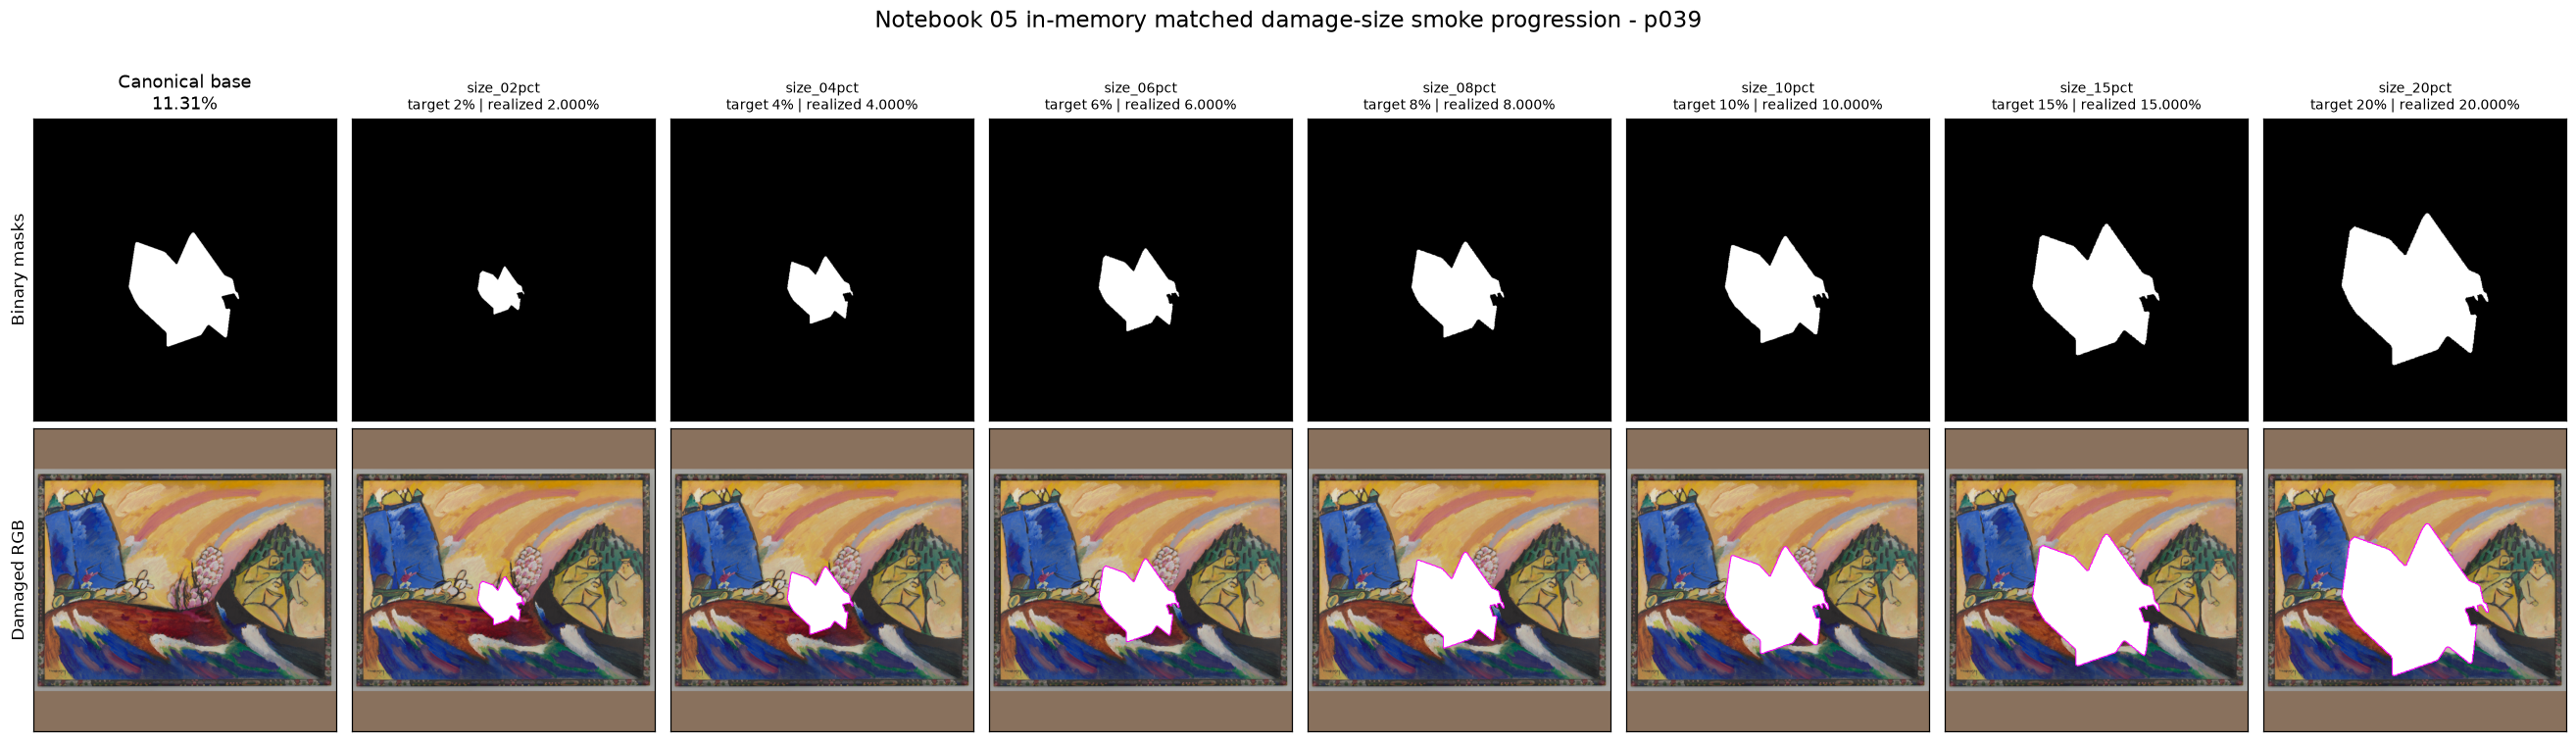

In [7]:
# ---------------------------------------------------------------------------
# In-memory mask and damaged-image progression
# ---------------------------------------------------------------------------

smoke_figure, smoke_axes = (
    plt.subplots(
        nrows=2,
        ncols=8,
        figsize=(
            24,
            7,
        ),
        dpi=110,
    )
)

smoke_axes[
    0,
    0,
].imshow(
    smoke_base_mask_image,
    cmap="gray",
    vmin=0,
    vmax=255,
)

smoke_axes[
    0,
    0,
].set_title(
    (
        "Canonical base\n"
        f"{100.0 * float(smoke_cohort_row['base_damage_fraction']):.2f}%"
    ),
)

smoke_axes[
    1,
    0,
].imshow(
    smoke_clean_image,
)

smoke_axes[
    1,
    0,
].set_title(
    "Clean reference",
)

for column_index, (
    level_id,
    target_percentage,
) in enumerate(
    CONFIGURED_LEVELS,
    start=1,
):
    smoke_row = (
        smoke_audit_df.loc[
            smoke_audit_df[
                "level_id"
            ]
            .eq(
                level_id
            )
        ]
        .iloc[
            0
        ]
    )

    mask_image = (
        smoke_masks_by_level[
            level_id
        ]
    )

    damaged_image = (
        smoke_damaged_by_level[
            level_id
        ]
    )

    mask_array = (
        np.asarray(
            mask_image,
            dtype=np.uint8,
        )
        == 255
    )

    realized_percentage = (
        100.0
        * int(
            smoke_row[
                "realized_pixels"
            ]
        )
        / SMOKE_CONTENT_AREA_PIXELS
    )

    smoke_axes[
        0,
        column_index,
    ].imshow(
        mask_image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    smoke_axes[
        0,
        column_index,
    ].set_title(
        (
            f"{level_id}\n"
            f"target {target_percentage:.0f}% | "
            f"realized {realized_percentage:.3f}%"
        ),
        fontsize=9,
    )

    smoke_axes[
        1,
        column_index,
    ].imshow(
        damaged_image,
    )

    smoke_axes[
        1,
        column_index,
    ].contour(
        mask_array.astype(
            np.uint8
        ),
        levels=[
            0.5,
        ],
        colors=[
            "magenta",
        ],
        linewidths=0.65,
    )

    smoke_axes[
        1,
        column_index,
    ].set_title(
        (
            f"Damaged input\n"
            f"scale {float(smoke_row['scale_factor']):.4f}"
        ),
        fontsize=9,
    )

for axis in (
    smoke_axes.ravel()
):
    axis.set_xticks([])
    axis.set_yticks([])

smoke_axes[
    0,
    0,
].set_ylabel(
    "Binary masks",
    fontsize=11,
)

smoke_axes[
    1,
    0,
].set_ylabel(
    "Damaged RGB",
    fontsize=11,
)

smoke_figure.suptitle(
    (
        "Notebook 05 in-memory matched damage-size smoke progression "
        f"- {SMOKE_PAINTING_ID}"
    ),
    fontsize=15,
)

smoke_figure.tight_layout(
    rect=(
        0,
        0,
        1,
        0.94,
    )
)

plt.show()

In [8]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

BATCH_3_START_CHECK_COUNT = len(
    VALIDATION.checks
)

MORPHOLOGY_CONFIG = (
    sensitivity_config[
        "morphology"
    ]
)

AREA_TOLERANCE_PP = float(
    sensitivity_config[
        "generator"
    ][
        "maximum_absolute_percentage_point_error"
    ]
)


def add_batch_3_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "in_memory_smoke"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# 1. Smoke painting identity

add_batch_3_check(
    check_id="smoke_painting",
    description=(
        "In-memory smoke generation uses "
        "the configured median-content painting."
    ),
    expected=(
        configured_smoke_painting_id
    ),
    observed=(
        SMOKE_PAINTING_ID
    ),
    passed=(
        SMOKE_PAINTING_ID
        == configured_smoke_painting_id
    ),
)


# 2. Complete configured level order

observed_smoke_levels = tuple(
    smoke_audit_df[
        "level_id"
    ].astype(str)
)

add_batch_3_check(
    check_id="smoke_level_order",
    description=(
        "Smoke series contains all seven "
        "configured levels in ascending order."
    ),
    expected=LEVEL_IDS,
    observed=observed_smoke_levels,
    passed=(
        observed_smoke_levels
        == LEVEL_IDS
        and len(
            smoke_audit_df
        )
        == EXPECTED_TARGET_LEVEL_COUNT
    ),
)


# 3. Deterministic seed replay

seed_replay_failures = int(
    (
        smoke_audit_df[
            "case_seed"
        ]
        != smoke_audit_df[
            "repeat_case_seed"
        ]
    ).sum()
)

add_batch_3_check(
    check_id="seed_replay",
    description=(
        "Repeated generation derives "
        "identical per-level deterministic seeds."
    ),
    expected=0,
    observed=seed_replay_failures,
    passed=(
        seed_replay_failures
        == 0
    ),
)


# 4. Deterministic mask replay

mask_replay_failures = int(
    (
        ~smoke_audit_df[
            "repeat_mask_equal"
        ]
    ).sum()
)

add_batch_3_check(
    check_id="mask_replay",
    description=(
        "Repeated generation produces "
        "byte-identical mask arrays."
    ),
    expected=0,
    observed=mask_replay_failures,
    passed=(
        mask_replay_failures
        == 0
    ),
)


# 5. Exact rounded target pixels

target_pixel_failures = int(
    (
        smoke_audit_df[
            "target_pixels"
        ]
        != smoke_audit_df[
            "realized_pixels"
        ]
    ).sum()
)

add_batch_3_check(
    check_id="exact_target_pixels",
    description=(
        "Every generated mask reaches its "
        "exact rounded target pixel count."
    ),
    expected=0,
    observed=target_pixel_failures,
    passed=(
        target_pixel_failures
        == 0
    ),
)


# 6. Percentage-point tolerance

area_tolerance_failures = int(
    (
        smoke_audit_df[
            "absolute_percentage_point_error"
        ]
        > AREA_TOLERANCE_PP
    ).sum()
)

add_batch_3_check(
    check_id="area_tolerance",
    description=(
        "Every realized content percentage "
        "lies within the configured tolerance."
    ),
    expected={
        "maximum_error_pp": (
            AREA_TOLERANCE_PP
        ),
        "failures": 0,
    },
    observed={
        "maximum_error_pp": float(
            smoke_audit_df[
                "absolute_percentage_point_error"
            ].max()
        ),
        "failures": (
            area_tolerance_failures
        ),
    },
    passed=(
        area_tolerance_failures
        == 0
    ),
)


# 7. Strict previous-level subset nesting

nesting_failures = int(
    (
        ~smoke_audit_df[
            "nested_with_previous"
        ]
    ).sum()
)

removed_previous_pixels = int(
    smoke_audit_df[
        "previous_pixels_removed"
    ].sum()
)

add_batch_3_check(
    check_id="strict_nesting",
    description=(
        "Every smaller mask is a strict "
        "subset-preserved predecessor of "
        "the next larger mask."
    ),
    expected={
        "nesting_failures": 0,
        "removed_previous_pixels": 0,
    },
    observed={
        "nesting_failures": (
            nesting_failures
        ),
        "removed_previous_pixels": (
            removed_previous_pixels
        ),
    },
    passed=(
        nesting_failures == 0
        and removed_previous_pixels == 0
    ),
)


# 8. Strictly increasing realized areas

realized_pixel_values = (
    smoke_audit_df[
        "realized_pixels"
    ]
    .astype(int)
    .tolist()
)

strictly_increasing = all(
    later > earlier
    for earlier, later in zip(
        realized_pixel_values,
        realized_pixel_values[
            1:
        ],
    )
)

add_batch_3_check(
    check_id="monotonic_area",
    description=(
        "Realized mask area increases "
        "strictly across configured levels."
    ),
    expected="strictly increasing",
    observed=(
        realized_pixel_values
    ),
    passed=strictly_increasing,
)


# 9. Binary mask values

binary_value_failures = int(
    (
        ~smoke_audit_df[
            "mask_unique_values"
        ]
        .isin(
            [
                "0|255",
            ]
        )
    ).sum()
)

add_batch_3_check(
    check_id="binary_masks",
    description=(
        "Every generated smoke mask contains "
        "only canonical binary values 0 and 255."
    ),
    expected={
        "unique_values": "0|255",
        "failures": 0,
    },
    observed={
        "observed_values": sorted(
            smoke_audit_df[
                "mask_unique_values"
            ]
            .unique()
            .tolist()
        ),
        "failures": (
            binary_value_failures
        ),
    },
    passed=(
        binary_value_failures
        == 0
    ),
)


# 10. Painting-content containment

padding_overlap_pixels = int(
    smoke_audit_df[
        "padding_overlap_pixels"
    ].sum()
)

add_batch_3_check(
    check_id="content_only_masks",
    description=(
        "Generated masks remain entirely "
        "inside the Notebook 02 painting-content "
        "region."
    ),
    expected=0,
    observed=padding_overlap_pixels,
    passed=(
        padding_overlap_pixels
        == 0
    ),
)


# 11. Connected-component topology

component_failures = int(
    (
        smoke_audit_df[
            "component_count_delta"
        ]
        != 0
    ).sum()
)

add_batch_3_check(
    check_id=(
        "component_topology"
    ),
    description=(
        "Scaling preserves the canonical "
        "base-mask connected-component count."
    ),
    expected={
        "base_components": int(
            smoke_base_morphology[
                "connected_component_count"
            ]
        ),
        "failures": 0,
    },
    observed={
        "component_counts": sorted(
            smoke_audit_df[
                "connected_component_count"
            ]
            .astype(int)
            .unique()
            .tolist()
        ),
        "failures": component_failures,
    },
    passed=(
        component_failures
        == 0
    ),
)


# 12. Absolute centroid displacement

centroid_pixel_threshold = float(
    MORPHOLOGY_CONFIG[
        "maximum_centroid_shift_pixels"
    ]
)

centroid_pixel_failures = int(
    (
        smoke_audit_df[
            "centroid_shift_pixels"
        ]
        > centroid_pixel_threshold
    ).sum()
)

add_batch_3_check(
    check_id="centroid_shift_pixels",
    description=(
        "Mask centroid displacement remains "
        "within the configured pixel threshold."
    ),
    expected={
        "maximum_pixels": (
            centroid_pixel_threshold
        ),
        "failures": 0,
    },
    observed={
        "maximum_pixels": float(
            smoke_audit_df[
                "centroid_shift_pixels"
            ].max()
        ),
        "failures": (
            centroid_pixel_failures
        ),
    },
    passed=(
        centroid_pixel_failures
        == 0
    ),
)


# 13. Content-normalized centroid displacement

centroid_fraction_column = (
    "centroid_shift_fraction_"
    "of_content_diagonal"
)

centroid_fraction_threshold = float(
    MORPHOLOGY_CONFIG[
        (
            "maximum_centroid_shift_"
            "fraction_of_content_diagonal"
        )
    ]
)

centroid_fraction_failures = int(
    (
        smoke_audit_df[
            centroid_fraction_column
        ]
        > centroid_fraction_threshold
    ).sum()
)

add_batch_3_check(
    check_id=(
        "centroid_shift_normalized"
    ),
    description=(
        "Content-normalized centroid "
        "displacement remains within its "
        "configured threshold."
    ),
    expected={
        "maximum_fraction": (
            centroid_fraction_threshold
        ),
        "failures": 0,
    },
    observed={
        "maximum_fraction": float(
            smoke_audit_df[
                centroid_fraction_column
            ].max()
        ),
        "failures": (
            centroid_fraction_failures
        ),
    },
    passed=(
        centroid_fraction_failures
        == 0
    ),
)


# 14. Bounding-box aspect-ratio drift

aspect_drift_threshold = float(
    MORPHOLOGY_CONFIG[
        (
            "maximum_relative_"
            "bbox_aspect_ratio_drift"
        )
    ]
)

aspect_drift_failures = int(
    (
        smoke_audit_df[
            "bbox_aspect_ratio_drift"
        ]
        > aspect_drift_threshold
    ).sum()
)

add_batch_3_check(
    check_id="bbox_aspect_drift",
    description=(
        "Scale-normalized bounding-box "
        "aspect-ratio drift remains within "
        "the configured threshold."
    ),
    expected={
        "maximum_relative_drift": (
            aspect_drift_threshold
        ),
        "failures": 0,
    },
    observed={
        "maximum_relative_drift": float(
            smoke_audit_df[
                "bbox_aspect_ratio_drift"
            ].max()
        ),
        "failures": (
            aspect_drift_failures
        ),
    },
    passed=(
        aspect_drift_failures
        == 0
    ),
)


# 15. Compactness drift

compactness_drift_threshold = float(
    MORPHOLOGY_CONFIG[
        (
            "maximum_relative_"
            "compactness_drift"
        )
    ]
)

compactness_drift_failures = int(
    (
        smoke_audit_df[
            "compactness_drift"
        ]
        > compactness_drift_threshold
    ).sum()
)

add_batch_3_check(
    check_id="compactness_drift",
    description=(
        "Scale-normalized compactness drift "
        "remains within the configured threshold."
    ),
    expected={
        "maximum_relative_drift": (
            compactness_drift_threshold
        ),
        "failures": 0,
    },
    observed={
        "maximum_relative_drift": float(
            smoke_audit_df[
                "compactness_drift"
            ].max()
        ),
        "failures": (
            compactness_drift_failures
        ),
    },
    passed=(
        compactness_drift_failures
        == 0
    ),
)


# 16. Content-boundary contact

boundary_touch_failures = int(
    smoke_audit_df[
        "touches_content_boundary"
    ].sum()
)

add_batch_3_check(
    check_id="content_boundary",
    description=(
        "No scaled smoke mask touches the "
        "painting-content boundary."
    ),
    expected={
        "touching_masks": 0,
    },
    observed={
        "touching_masks": (
            boundary_touch_failures
        ),
        "minimum_distance_pixels": int(
            smoke_audit_df[
                (
                    "minimum_distance_to_"
                    "content_boundary_pixels"
                )
            ].min()
        ),
    },
    passed=(
        boundary_touch_failures
        == 0
    ),
)


# 17. Damaged-image dimensions and mode

damaged_image_contract_failures = int(
    (
        (
            smoke_audit_df[
                "damaged_width"
            ]
            != 768
        )
        |
        (
            smoke_audit_df[
                "damaged_height"
            ]
            != 768
        )
        |
        (
            smoke_audit_df[
                "damaged_mode"
            ]
            != "RGB"
        )
    ).sum()
)

add_batch_3_check(
    check_id=(
        "damaged_image_contract"
    ),
    description=(
        "Every in-memory damaged image "
        "is a 768x768 RGB image."
    ),
    expected={
        "width": 768,
        "height": 768,
        "mode": "RGB",
        "failures": 0,
    },
    observed={
        "widths": sorted(
            smoke_audit_df[
                "damaged_width"
            ]
            .unique()
            .tolist()
        ),
        "heights": sorted(
            smoke_audit_df[
                "damaged_height"
            ]
            .unique()
            .tolist()
        ),
        "modes": sorted(
            smoke_audit_df[
                "damaged_mode"
            ]
            .unique()
            .tolist()
        ),
        "failures": (
            damaged_image_contract_failures
        ),
    },
    passed=(
        damaged_image_contract_failures
        == 0
    ),
)


# 18. Exact mask-application pixel integrity

pixel_integrity_failures = int(
    (
        (
            smoke_audit_df[
                "expected_changed_pixels"
            ]
            != smoke_audit_df[
                "observed_changed_pixels"
            ]
        )
        |
        (
            smoke_audit_df[
                "outside_mask_changed_pixels"
            ]
            != 0
        )
        |
        (
            smoke_audit_df[
                "inside_mask_not_fill_pixels"
            ]
            != 0
        )
    ).sum()
)

add_batch_3_check(
    check_id="pixel_integrity",
    description=(
        "Damage application changes only "
        "masked non-white source pixels and "
        "fills every masked pixel correctly."
    ),
    expected={
        "failed_cases": 0,
        "outside_mask_changed_pixels": 0,
        "inside_mask_not_fill_pixels": 0,
    },
    observed={
        "failed_cases": (
            pixel_integrity_failures
        ),
        "outside_mask_changed_pixels": int(
            smoke_audit_df[
                "outside_mask_changed_pixels"
            ].sum()
        ),
        "inside_mask_not_fill_pixels": int(
            smoke_audit_df[
                "inside_mask_not_fill_pixels"
            ].sum()
        ),
    },
    passed=(
        pixel_integrity_failures
        == 0
    ),
)


# 19. Notebook-only visual layout

visual_layout_passed = (
    smoke_axes.shape
    == (
        2,
        8,
    )
    and len(
        smoke_figure.axes
    )
    == 16
)

add_batch_3_check(
    check_id="smoke_visual_layout",
    description=(
        "Notebook-only progression contains "
        "the intended two-row, eight-column "
        "matched layout."
    ),
    expected={
        "axes_shape": [
            2,
            8,
        ],
        "axis_count": 16,
    },
    observed={
        "axes_shape": list(
            smoke_axes.shape
        ),
        "axis_count": len(
            smoke_figure.axes
        ),
    },
    passed=visual_layout_passed,
)


# 20. No filesystem writes

batch_3_files_after = {
    path.resolve()
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

batch_3_new_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        batch_3_files_after
        - batch_3_files_before
    )
)

add_batch_3_check(
    check_id="smoke_no_writes",
    description=(
        "In-memory smoke generation and "
        "visualization write no Notebook 05 "
        "scientific artifact."
    ),
    expected={
        "new_files": 0,
    },
    observed={
        "new_files": len(
            batch_3_new_files
        ),
    },
    passed=not batch_3_new_files,
    details=batch_3_new_files,
)


# ---------------------------------------------------------------------------
# Batch 3 completion gate and rendered evidence
# ---------------------------------------------------------------------------

BATCH_3_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_3_START_CHECK_COUNT
)

if BATCH_3_CHECK_COUNT != 20:
    raise RuntimeError(
        "Batch 3 must add exactly 20 checks; "
        f"observed {BATCH_3_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_3_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_3_START_CHECK_COUNT:
    ]
    .reset_index(drop=True)
)

print(
    "Batch 3 validation checks:"
)

display(
    batch_3_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nIn-memory smoke generation audit:"
)

display(
    smoke_audit_df[
        [
            "level_id",
            "target_percentage_content",
            "target_pixels",
            "realized_pixels",
            (
                "absolute_percentage_point_error"
            ),
            "scale_factor",
            "correction_added_pixels",
            "correction_removed_pixels",
            "previous_pixels_removed",
            "centroid_shift_pixels",
            "bbox_aspect_ratio_drift",
            "compactness_drift",
            "minimum_distance_to_content_boundary_pixels",
        ]
    ]
)

print(
    "\nBatch 3 completed successfully."
)

print(
    "Batch 3 checks:",
    BATCH_3_CHECK_COUNT,
)

print(
    "Total checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Smoke levels:",
    len(
        smoke_audit_df
    ),
)

print(
    "Maximum area error (percentage points):",
    float(
        smoke_audit_df[
            "absolute_percentage_point_error"
        ].max()
    ),
)

print(
    "Previous-level pixels removed:",
    int(
        smoke_audit_df[
            "previous_pixels_removed"
        ].sum()
    ),
)

print(
    "New output files:",
    len(
        batch_3_new_files
    ),
)

plt.close(
    smoke_figure
)

print(
    "Next approved stage: Batch 4 - "
    "full 35-case mask and damaged-image "
    "generation."
)

Batch 3 validation checks:


,check_id,severity,expected,observed,passed
0,smoke_painting,blocking,p039,p039,True
1,smoke_level_order,blocking,"[""size_02pct"", ""size_04pct"", ""size_06pct"", ""si...","[""size_02pct"", ""size_04pct"", ""size_06pct"", ""si...",True
2,seed_replay,blocking,0,0,True
3,mask_replay,blocking,0,0,True
4,exact_target_pixels,blocking,0,0,True
5,area_tolerance,blocking,"{""failures"": 0, ""maximum_error_pp"": 0.01}","{""failures"": 0, ""maximum_error_pp"": 9.23463356...",True
6,strict_nesting,blocking,"{""nesting_failures"": 0, ""removed_previous_pixe...","{""nesting_failures"": 0, ""removed_previous_pixe...",True
7,monotonic_area,blocking,strictly increasing,"[8663, 17326, 25989, 34652, 43315, 64973, 86630]",True
8,binary_masks,blocking,"{""failures"": 0, ""unique_values"": ""0|255""}","{""failures"": 0, ""observed_values"": [""0|255""]}",True
9,content_only_masks,blocking,0,0,True



In-memory smoke generation audit:


,level_id,target_percentage_content,target_pixels,realized_pixels,absolute_percentage_point_error,scale_factor,correction_added_pixels,correction_removed_pixels,previous_pixels_removed,centroid_shift_pixels,bbox_aspect_ratio_drift,compactness_drift,minimum_distance_to_content_boundary_pixels
0,size_02pct,2.0,8663,8663,0.000009,0.419643,0,26,0,0.579164,0.001753,0.008433,168
1,size_04pct,4.0,17326,17326,0.000018,0.594793,8,0,0,0.128250,0.005575,0.001297,144
2,size_06pct,6.0,25989,25989,0.000028,0.726786,0,15,0,0.228082,0.001352,0.015051,125
3,size_08pct,8.0,34652,34652,0.000037,0.840010,36,0,0,0.574806,0.002494,0.025348,109
4,size_10pct,10.0,43315,43315,0.000046,0.939159,76,0,0,0.077928,0.001442,0.040265,95
5,size_15pct,15.0,64973,64973,0.000046,1.150000,0,14,0,0.506385,0.001499,0.016554,64
6,size_20pct,20.0,86630,86630,0.000092,1.329310,0,62,0,0.149182,0.001854,0.025277,39



Batch 3 completed successfully.
Batch 3 checks: 20
Total checks: 52
Blocking failures: 0
Smoke levels: 7
Maximum area error (percentage points): 9.23463356983234e-05
Previous-level pixels removed: 0
New output files: 0
Next approved stage: Batch 4 - full 35-case mask and damaged-image generation.


## Batch 4 - Full 35-Case Damage-Size Dataset Generation

This batch generates the complete canonical Notebook 05 image dataset.

For each of the five pinned paintings and seven configured target levels, it will:

- load the validated Notebook 02 clean image and Notebook 03 `loss_large` base mask;
- derive a deterministic per-case seed;
- scale the mask about its actual centroid;
- preserve every preceding level through strict subset nesting;
- perform deterministic boundary correction to reach the exact rounded target pixel count;
- apply the canonical white RGB damage fill;
- save one binary mask PNG;
- save one corresponding damaged RGB PNG;
- calculate normalized paths, identifiers, file metadata, and SHA-256 checksums;
- build the in-memory `damage_size_cases.v1` table;
- retain runtime and nesting evidence separately from the canonical case table;
- remove stale PNGs only from the two Notebook 05-owned image directories;
- verify the complete 35-case matched design before proceeding.

This batch writes exactly 35 mask PNGs and 35 damaged-image PNGs. It does not yet persist the case table, generation audit, figure, validation table, or manifests.

In [9]:
from restoration_eval.damage_sensitivity import (
    generate_damage_size_dataset,
    stable_case_seed,
    target_pixels_from_percentage,
)


# ---------------------------------------------------------------------------
# Snapshot the Notebook 05 output root before full generation
# ---------------------------------------------------------------------------

batch_4_files_before = {
    path.resolve()
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Generate the complete matched damage-size dataset
# ---------------------------------------------------------------------------

damage_size_generation_result = (
    generate_damage_size_dataset(
        sensitivity_cohort_df,
        sensitivity_config,
        OUTPUT_ROOT,
        PROJECT_ROOT,
    )
)

damage_size_cases_df = (
    damage_size_generation_result
    .cases
    .copy()
)

generation_evidence_df = (
    damage_size_generation_result
    .generation_evidence
    .copy()
)

removed_stale_paths = tuple(
    damage_size_generation_result
    .removed_stale_paths
)


# ---------------------------------------------------------------------------
# Current physical output inventory
# ---------------------------------------------------------------------------

generated_mask_paths = sorted(
    path.resolve()
    for path in (
        MASK_OUTPUT_DIRECTORY.rglob(
            "*.png"
        )
    )
)

generated_damaged_paths = sorted(
    path.resolve()
    for path in (
        DAMAGED_OUTPUT_DIRECTORY.rglob(
            "*.png"
        )
    )
)

batch_4_files_after = {
    path.resolve()
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

batch_4_new_files = sorted(
    batch_4_files_after
    - batch_4_files_before
)

print(
    "Generated canonical cases:",
    len(
        damage_size_cases_df
    ),
)

print(
    "Generated mask PNGs:",
    len(
        generated_mask_paths
    ),
)

print(
    "Generated damaged PNGs:",
    len(
        generated_damaged_paths
    ),
)

print(
    "Removed stale PNGs:",
    len(
        removed_stale_paths
    ),
)

print(
    "New output files:",
    len(
        batch_4_new_files
    ),
)

Generated canonical cases: 35
Generated mask PNGs: 35
Generated damaged PNGs: 35
Removed stale PNGs: 0
New output files: 70


In [10]:
# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------

BATCH_4_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_4_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "full_generation"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Normalized case schema
# ---------------------------------------------------------------------------

generated_case_schema_result = (
    validate_dataframe(
        damage_size_cases_df,
        DAMAGE_SIZE_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

generated_case_schema_passed = (
    generated_case_schema_result.passed
    and not (
        generated_case_schema_result
        .unexpected_columns
    )
)

add_batch_4_check(
    check_id="generated_case_schema",
    description=(
        "Generated in-memory case table "
        "satisfies damage_size_cases.v1 exactly."
    ),
    expected={
        "schema": (
            DAMAGE_SIZE_CASES_SCHEMA.version
        ),
        "missing_columns": 0,
        "unexpected_columns": 0,
        "duplicate_primary_key_rows": 0,
    },
    observed=(
        generated_case_schema_result
        .to_dict()
    ),
    passed=generated_case_schema_passed,
)


# ---------------------------------------------------------------------------
# 2. Exact case cardinality
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="generated_case_count",
    description=(
        "Full generation creates exactly "
        "35 normalized cases."
    ),
    expected=EXPECTED_CASE_COUNT,
    observed=len(
        damage_size_cases_df
    ),
    passed=(
        len(
            damage_size_cases_df
        )
        == EXPECTED_CASE_COUNT
    ),
)


# ---------------------------------------------------------------------------
# 3. Complete matched painting-level design
# ---------------------------------------------------------------------------

painting_case_counts = (
    damage_size_cases_df
    .groupby(
        "painting_id",
        observed=True,
    )
    .size()
    .to_dict()
)

level_case_counts = (
    damage_size_cases_df
    .groupby(
        "level_id",
        observed=True,
    )
    .size()
    .to_dict()
)

matched_design_passed = (
    set(
        painting_case_counts
    )
    == set(
        COHORT_PAINTING_IDS
    )
    and all(
        int(count)
        == EXPECTED_TARGET_LEVEL_COUNT
        for count in (
            painting_case_counts.values()
        )
    )
    and set(
        level_case_counts
    )
    == set(
        LEVEL_IDS
    )
    and all(
        int(count)
        == EXPECTED_PAINTING_COUNT
        for count in (
            level_case_counts.values()
        )
    )
)

add_batch_4_check(
    check_id="matched_design",
    description=(
        "Every pinned painting has all seven "
        "levels and every level has all five "
        "paintings."
    ),
    expected={
        "cases_per_painting": 7,
        "paintings_per_level": 5,
        "paintings": (
            COHORT_PAINTING_IDS
        ),
        "levels": LEVEL_IDS,
    },
    observed={
        "cases_per_painting": (
            painting_case_counts
        ),
        "paintings_per_level": (
            level_case_counts
        ),
    },
    passed=matched_design_passed,
)


# ---------------------------------------------------------------------------
# 4. Stable configured row order
# ---------------------------------------------------------------------------

expected_case_order = [
    (
        painting_id,
        level_id,
    )
    for painting_id in (
        COHORT_PAINTING_IDS
    )
    for level_id in LEVEL_IDS
]

observed_case_order = list(
    zip(
        damage_size_cases_df[
            "painting_id"
        ].astype(str),
        damage_size_cases_df[
            "level_id"
        ].astype(str),
    )
)

add_batch_4_check(
    check_id="generated_case_order",
    description=(
        "Cases follow the stable configured "
        "painting-major and level-minor order."
    ),
    expected=expected_case_order,
    observed=observed_case_order,
    passed=(
        observed_case_order
        == expected_case_order
    ),
)


# ---------------------------------------------------------------------------
# 5. Unique compact identifiers
# ---------------------------------------------------------------------------

identifier_duplicate_counts = {
    "case_id": int(
        damage_size_cases_df[
            "case_id"
        ].duplicated().sum()
    ),
    "mask_or_effect_id": int(
        damage_size_cases_df[
            "mask_or_effect_id"
        ].duplicated().sum()
    ),
    "damaged_image_id": int(
        damage_size_cases_df[
            "damaged_image_id"
        ].duplicated().sum()
    ),
}

identifier_format_failures = []

for case_row in (
    damage_size_cases_df.itertuples(
        index=False
    )
):
    expected_case_id = (
        "damage_size__"
        f"{case_row.painting_id}__"
        "loss_large__"
        f"{case_row.level_id}"
    )

    expected_mask_id = (
        "mask__damage_size__"
        f"{case_row.painting_id}__"
        "loss_large__"
        f"{case_row.level_id}"
    )

    expected_damaged_id = (
        "damaged__damage_size__"
        f"{case_row.painting_id}__"
        "loss_large__"
        f"{case_row.level_id}"
    )

    if (
        str(
            case_row.case_id
        )
        != expected_case_id
        or str(
            case_row.mask_or_effect_id
        )
        != expected_mask_id
        or str(
            case_row.damaged_image_id
        )
        != expected_damaged_id
    ):
        identifier_format_failures.append(
            {
                "painting_id": (
                    case_row.painting_id
                ),
                "level_id": (
                    case_row.level_id
                ),
            }
        )

identifier_contract_passed = (
    all(
        count == 0
        for count in (
            identifier_duplicate_counts
            .values()
        )
    )
    and not identifier_format_failures
)

add_batch_4_check(
    check_id="identifier_contract",
    description=(
        "Case, mask, and damaged-image IDs "
        "are unique and follow the compact "
        "canonical identity convention."
    ),
    expected={
        "duplicate_counts": {
            "case_id": 0,
            "mask_or_effect_id": 0,
            "damaged_image_id": 0,
        },
        "format_failures": 0,
    },
    observed={
        "duplicate_counts": (
            identifier_duplicate_counts
        ),
        "format_failures": len(
            identifier_format_failures
        ),
    },
    passed=identifier_contract_passed,
    details=identifier_format_failures,
)


# ---------------------------------------------------------------------------
# 6. Unique normalized output paths
# ---------------------------------------------------------------------------

path_duplicate_counts = {
    "mask_or_effect_path": int(
        damage_size_cases_df[
            "mask_or_effect_path"
        ].duplicated().sum()
    ),
    "input_image_path": int(
        damage_size_cases_df[
            "input_image_path"
        ].duplicated().sum()
    ),
}

path_contract_errors = []

for case_row in (
    damage_size_cases_df.itertuples(
        index=False
    )
):
    expected_mask_path = (
        MASK_OUTPUT_DIRECTORY
        / str(
            case_row.painting_id
        )
        / (
            f"{case_row.level_id}.png"
        )
    )

    expected_damaged_path = (
        DAMAGED_OUTPUT_DIRECTORY
        / str(
            case_row.painting_id
        )
        / (
            f"{case_row.level_id}.png"
        )
    )

    if str(
        case_row.mask_or_effect_path
    ) != to_repo_relative(
        expected_mask_path,
        PROJECT_ROOT,
    ):
        path_contract_errors.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "field": (
                    "mask_or_effect_path"
                ),
                "observed": (
                    case_row.mask_or_effect_path
                ),
            }
        )

    if str(
        case_row.input_image_path
    ) != to_repo_relative(
        expected_damaged_path,
        PROJECT_ROOT,
    ):
        path_contract_errors.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "field": (
                    "input_image_path"
                ),
                "observed": (
                    case_row.input_image_path
                ),
            }
        )

normalized_paths_passed = (
    all(
        count == 0
        for count in (
            path_duplicate_counts.values()
        )
    )
    and not path_contract_errors
)

add_batch_4_check(
    check_id="normalized_output_paths",
    description=(
        "Generated mask and damaged-image "
        "paths are unique and match the "
        "approved painting/level layout."
    ),
    expected={
        "duplicate_paths": 0,
        "path_contract_errors": 0,
    },
    observed={
        "duplicate_paths": int(
            sum(
                path_duplicate_counts
                .values()
            )
        ),
        "path_contract_errors": len(
            path_contract_errors
        ),
    },
    passed=normalized_paths_passed,
    details=path_contract_errors,
)


# ---------------------------------------------------------------------------
# 7. Exact configured target definitions
# ---------------------------------------------------------------------------

target_definition_errors = []

cohort_by_painting = (
    sensitivity_cohort_df
    .set_index(
        "painting_id"
    )
)

target_percentage_by_level = {
    str(level_id): float(
        percentage
    )
    for (
        level_id,
        percentage,
    ) in CONFIGURED_LEVELS
}

for case_row in (
    damage_size_cases_df.itertuples(
        index=False
    )
):
    expected_percentage = (
        target_percentage_by_level[
            str(
                case_row.level_id
            )
        ]
    )

    content_area = int(
        cohort_by_painting.loc[
            str(
                case_row.painting_id
            ),
            "content_area_pixels",
        ]
    )

    expected_pixels = (
        target_pixels_from_percentage(
            content_area,
            expected_percentage,
        )
    )

    if (
        not np.isclose(
            float(
                case_row.target_damage_fraction
            ),
            expected_percentage
            / 100.0,
            atol=1e-12,
        )
        or int(
            case_row.target_damage_pixels
        )
        != expected_pixels
    ):
        target_definition_errors.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "expected_percentage": (
                    expected_percentage
                ),
                "expected_pixels": (
                    expected_pixels
                ),
                "observed_fraction": float(
                    case_row.target_damage_fraction
                ),
                "observed_pixels": int(
                    case_row.target_damage_pixels
                ),
            }
        )

add_batch_4_check(
    check_id="target_definitions",
    description=(
        "Every case uses its configured "
        "percentage and round-half-up target "
        "pixel count."
    ),
    expected="zero target-definition errors",
    observed=len(
        target_definition_errors
    ),
    passed=not target_definition_errors,
    details=target_definition_errors,
)


# ---------------------------------------------------------------------------
# 8. Exact realized area and configured tolerance
# ---------------------------------------------------------------------------

area_failure_rows = (
    damage_size_cases_df.loc[
        (
            damage_size_cases_df[
                "realized_damage_pixels"
            ]
            != damage_size_cases_df[
                "target_damage_pixels"
            ]
        )
        |
        (
            damage_size_cases_df[
                "absolute_percentage_point_error"
            ]
            > AREA_TOLERANCE_PP
        )
    ]
)

add_batch_4_check(
    check_id="generated_area_accuracy",
    description=(
        "All 35 masks reach the exact rounded "
        "pixel target and remain within the "
        "configured percentage-point tolerance."
    ),
    expected={
        "failed_cases": 0,
        "maximum_error_pp": (
            AREA_TOLERANCE_PP
        ),
    },
    observed={
        "failed_cases": len(
            area_failure_rows
        ),
        "maximum_error_pp": float(
            damage_size_cases_df[
                "absolute_percentage_point_error"
            ].max()
        ),
    },
    passed=area_failure_rows.empty,
    details=(
        area_failure_rows[
            [
                "case_id",
                "target_damage_pixels",
                "realized_damage_pixels",
                (
                    "absolute_percentage_"
                    "point_error"
                ),
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 9. Strict nesting metadata and sequence
# ---------------------------------------------------------------------------

nesting_metadata_errors = []

for painting_id in (
    COHORT_PAINTING_IDS
):
    painting_rows = (
        damage_size_cases_df.loc[
            damage_size_cases_df[
                "painting_id"
            ]
            .astype(str)
            .eq(
                painting_id
            )
        ]
        .reset_index(drop=True)
    )

    for level_index, case_row in (
        painting_rows.iterrows()
    ):
        if level_index == 0:
            expected_previous_level = ""
            expected_previous_mask = ""
        else:
            preceding_row = (
                painting_rows.iloc[
                    level_index
                    - 1
                ]
            )

            expected_previous_level = str(
                preceding_row[
                    "level_id"
                ]
            )

            expected_previous_mask = str(
                preceding_row[
                    "mask_or_effect_id"
                ]
            )

        if (
            str(
                case_row[
                    "previous_level_id"
                ]
            )
            != expected_previous_level
            or str(
                case_row[
                    "previous_mask_id"
                ]
            )
            != expected_previous_mask
            or not bool(
                case_row[
                    "nested_with_previous"
                ]
            )
        ):
            nesting_metadata_errors.append(
                {
                    "case_id": str(
                        case_row[
                            "case_id"
                        ]
                    ),
                    "expected_previous_level": (
                        expected_previous_level
                    ),
                    "observed_previous_level": str(
                        case_row[
                            "previous_level_id"
                        ]
                    ),
                }
            )

evidence_nesting_failures = int(
    (
        generation_evidence_df[
            "previous_pixels_removed"
        ]
        != 0
    ).sum()
)

add_batch_4_check(
    check_id="generated_nesting",
    description=(
        "Case metadata records the correct "
        "preceding level and generation removed "
        "zero pixels from smaller masks."
    ),
    expected={
        "metadata_errors": 0,
        "cases_removing_previous_pixels": 0,
        "total_removed_pixels": 0,
    },
    observed={
        "metadata_errors": len(
            nesting_metadata_errors
        ),
        "cases_removing_previous_pixels": (
            evidence_nesting_failures
        ),
        "total_removed_pixels": int(
            generation_evidence_df[
                "previous_pixels_removed"
            ].sum()
        ),
    },
    passed=(
        not nesting_metadata_errors
        and evidence_nesting_failures == 0
    ),
    details=nesting_metadata_errors,
)


# ---------------------------------------------------------------------------
# 10. Deterministic seed contract
# ---------------------------------------------------------------------------

seed_contract_errors = []

base_sha_by_painting = (
    sensitivity_cohort_df
    .set_index(
        "painting_id"
    )[
        "base_mask_sha256"
    ]
    .astype(str)
    .to_dict()
)

for case_row in (
    damage_size_cases_df.itertuples(
        index=False
    )
):
    expected_seed = (
        stable_case_seed(
            str(
                sensitivity_config[
                    "generator"
                ][
                    "seed_scheme_version"
                ]
            ),
            int(
                sensitivity_config[
                    "generator"
                ][
                    "global_seed"
                ]
            ),
            str(
                case_row.painting_id
            ),
            base_sha_by_painting[
                str(
                    case_row.painting_id
                )
            ],
            str(
                case_row.level_id
            ),
        )
    )

    if (
        int(
            case_row.case_seed
        )
        != expected_seed
    ):
        seed_contract_errors.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "expected_seed": (
                    expected_seed
                ),
                "observed_seed": int(
                    case_row.case_seed
                ),
            }
        )

seed_contract_passed = (
    not seed_contract_errors
    and damage_size_cases_df[
        "case_seed"
    ].nunique()
    == EXPECTED_CASE_COUNT
    and damage_size_cases_df[
        "seed_scheme_version"
    ]
    .astype(str)
    .eq(
        sensitivity_config[
            "generator"
        ][
            "seed_scheme_version"
        ]
    )
    .all()
)

add_batch_4_check(
    check_id="deterministic_seeds",
    description=(
        "All case seeds are unique and "
        "reconcile with the configured stable "
        "seed derivation."
    ),
    expected={
        "seed_errors": 0,
        "unique_seeds": 35,
    },
    observed={
        "seed_errors": len(
            seed_contract_errors
        ),
        "unique_seeds": int(
            damage_size_cases_df[
                "case_seed"
            ].nunique()
        ),
    },
    passed=seed_contract_passed,
    details=seed_contract_errors,
)


# ---------------------------------------------------------------------------
# 11. Canonical image metadata contract
# ---------------------------------------------------------------------------

image_metadata_failures = (
    damage_size_cases_df.loc[
        (
            damage_size_cases_df[
                "width"
            ]
            != 768
        )
        |
        (
            damage_size_cases_df[
                "height"
            ]
            != 768
        )
        |
        (
            damage_size_cases_df[
                "mask_mode"
            ]
            != "L"
        )
        |
        (
            damage_size_cases_df[
                "damaged_mode"
            ]
            != "RGB"
        )
        |
        (
            damage_size_cases_df[
                "format"
            ]
            != "PNG"
        )
        |
        (
            damage_size_cases_df[
                "base_mask_type"
            ]
            != "loss_large"
        )
        |
        (
            damage_size_cases_df[
                "fill_strategy"
            ]
            != "constant_rgb"
        )
    ]
)

add_batch_4_check(
    check_id="generated_image_metadata",
    description=(
        "All generated cases record canonical "
        "dimensions, modes, PNG format, base "
        "mask type, and fill strategy."
    ),
    expected={
        "failed_cases": 0,
        "dimensions": "768x768",
        "mask_mode": "L",
        "damaged_mode": "RGB",
        "format": "PNG",
    },
    observed={
        "failed_cases": len(
            image_metadata_failures
        ),
        "widths": sorted(
            damage_size_cases_df[
                "width"
            ].unique().tolist()
        ),
        "heights": sorted(
            damage_size_cases_df[
                "height"
            ].unique().tolist()
        ),
        "mask_modes": sorted(
            damage_size_cases_df[
                "mask_mode"
            ].unique().tolist()
        ),
        "damaged_modes": sorted(
            damage_size_cases_df[
                "damaged_mode"
            ].unique().tolist()
        ),
        "formats": sorted(
            damage_size_cases_df[
                "format"
            ].unique().tolist()
        ),
    },
    passed=image_metadata_failures.empty,
)


# ---------------------------------------------------------------------------
# 12. Exact physical image inventory
# ---------------------------------------------------------------------------

expected_generated_mask_paths = {
    (
        MASK_OUTPUT_DIRECTORY
        / painting_id
        / f"{level_id}.png"
    ).resolve()
    for painting_id in (
        COHORT_PAINTING_IDS
    )
    for level_id in LEVEL_IDS
}

expected_generated_damaged_paths = {
    (
        DAMAGED_OUTPUT_DIRECTORY
        / painting_id
        / f"{level_id}.png"
    ).resolve()
    for painting_id in (
        COHORT_PAINTING_IDS
    )
    for level_id in LEVEL_IDS
}

observed_generated_mask_paths = set(
    generated_mask_paths
)

observed_generated_damaged_paths = set(
    generated_damaged_paths
)

image_inventory_passed = (
    observed_generated_mask_paths
    == expected_generated_mask_paths
    and observed_generated_damaged_paths
    == expected_generated_damaged_paths
)

add_batch_4_check(
    check_id="generated_image_inventory",
    description=(
        "Physical image inventory contains "
        "exactly 35 expected masks and 35 "
        "expected damaged images."
    ),
    expected={
        "mask_files": 35,
        "damaged_files": 35,
        "missing_or_extra": 0,
    },
    observed={
        "mask_files": len(
            observed_generated_mask_paths
        ),
        "damaged_files": len(
            observed_generated_damaged_paths
        ),
        "missing_masks": len(
            expected_generated_mask_paths
            - observed_generated_mask_paths
        ),
        "extra_masks": len(
            observed_generated_mask_paths
            - expected_generated_mask_paths
        ),
        "missing_damaged": len(
            expected_generated_damaged_paths
            - observed_generated_damaged_paths
        ),
        "extra_damaged": len(
            observed_generated_damaged_paths
            - expected_generated_damaged_paths
        ),
    },
    passed=image_inventory_passed,
)


# ---------------------------------------------------------------------------
# 13. Generated file sizes
# ---------------------------------------------------------------------------

size_contract_failures = (
    damage_size_cases_df.loc[
        (
            damage_size_cases_df[
                "mask_size_bytes"
            ]
            <= 0
        )
        |
        (
            damage_size_cases_df[
                "damaged_size_bytes"
            ]
            <= 0
        )
    ]
)

add_batch_4_check(
    check_id="generated_file_sizes",
    description=(
        "Every generated mask and damaged "
        "image has a positive recorded file size."
    ),
    expected={
        "failed_cases": 0,
        "zero_byte_files": 0,
    },
    observed={
        "failed_cases": len(
            size_contract_failures
        ),
        "minimum_mask_bytes": int(
            damage_size_cases_df[
                "mask_size_bytes"
            ].min()
        ),
        "minimum_damaged_bytes": int(
            damage_size_cases_df[
                "damaged_size_bytes"
            ].min()
        ),
    },
    passed=size_contract_failures.empty,
)


# ---------------------------------------------------------------------------
# 14. Generated checksums reconcile with disk
# ---------------------------------------------------------------------------

generated_checksum_errors = []

for case_row in (
    damage_size_cases_df.itertuples(
        index=False
    )
):
    mask_path = resolve_repo_path(
        str(
            case_row.mask_or_effect_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    damaged_path = resolve_repo_path(
        str(
            case_row.input_image_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_mask_sha256 = (
        sha256_file(
            mask_path
        )
    )

    observed_damaged_sha256 = (
        sha256_file(
            damaged_path
        )
    )

    if (
        observed_mask_sha256
        != str(
            case_row.mask_sha256
        )
        or observed_damaged_sha256
        != str(
            case_row.damaged_image_sha256
        )
    ):
        generated_checksum_errors.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "mask_matches": (
                    observed_mask_sha256
                    == str(
                        case_row.mask_sha256
                    )
                ),
                "damaged_matches": (
                    observed_damaged_sha256
                    == str(
                        case_row.damaged_image_sha256
                    )
                ),
            }
        )

add_batch_4_check(
    check_id="generated_checksums",
    description=(
        "All generated mask and damaged-image "
        "checksums reconcile with disk."
    ),
    expected="zero checksum errors",
    observed=len(
        generated_checksum_errors
    ),
    passed=not generated_checksum_errors,
    details=generated_checksum_errors,
)


# ---------------------------------------------------------------------------
# 15. Separate complete runtime evidence
# ---------------------------------------------------------------------------

runtime_contract_passed = (
    len(
        generation_evidence_df
    )
    == EXPECTED_CASE_COUNT
    and generation_evidence_df[
        "case_id"
    ].nunique()
    == EXPECTED_CASE_COUNT
    and generation_evidence_df[
        "runtime_seconds"
    ]
    .astype(float)
    .gt(0)
    .all()
    and set(
        generation_evidence_df[
            "case_id"
        ].astype(str)
    )
    == set(
        damage_size_cases_df[
            "case_id"
        ].astype(str)
    )
)

add_batch_4_check(
    check_id="generation_runtime_evidence",
    description=(
        "Noncanonical runtime evidence covers "
        "all generated cases exactly once."
    ),
    expected={
        "rows": 35,
        "unique_case_ids": 35,
        "nonpositive_runtimes": 0,
    },
    observed={
        "rows": len(
            generation_evidence_df
        ),
        "unique_case_ids": int(
            generation_evidence_df[
                "case_id"
            ].nunique()
        ),
        "nonpositive_runtimes": int(
            (
                generation_evidence_df[
                    "runtime_seconds"
                ]
                <= 0
            ).sum()
        ),
    },
    passed=runtime_contract_passed,
)


# ---------------------------------------------------------------------------
# 16. Stale-file cleanup result
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="stale_generation_outputs",
    description=(
        "Full generation encountered no stale "
        "Notebook 05 PNG requiring removal."
    ),
    expected=0,
    observed=len(
        removed_stale_paths
    ),
    passed=(
        len(
            removed_stale_paths
        )
        == 0
    ),
    details=removed_stale_paths,
)


# ---------------------------------------------------------------------------
# 17. No premature non-image artifacts
# ---------------------------------------------------------------------------

expected_current_output_files = (
    expected_generated_mask_paths
    | expected_generated_damaged_paths
)

unexpected_current_output_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        batch_4_files_after
        - expected_current_output_files
    )
)

add_batch_4_check(
    check_id="generation_stage_scope",
    description=(
        "Batch 4 writes only the contracted "
        "mask and damaged-image PNGs."
    ),
    expected={
        "total_files": 70,
        "unexpected_nonimage_files": 0,
    },
    observed={
        "total_files": len(
            batch_4_files_after
        ),
        "unexpected_nonimage_files": len(
            unexpected_current_output_files
        ),
    },
    passed=(
        len(
            batch_4_files_after
        )
        == 70
        and not (
            unexpected_current_output_files
        )
    ),
    details=unexpected_current_output_files,
)


# ---------------------------------------------------------------------------
# Batch 4 completion gate and summaries
# ---------------------------------------------------------------------------

BATCH_4_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_4_START_CHECK_COUNT
)

if BATCH_4_CHECK_COUNT != 17:
    raise RuntimeError(
        "Batch 4 must add exactly 17 checks; "
        f"observed {BATCH_4_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_4_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_4_START_CHECK_COUNT:
    ]
    .reset_index(drop=True)
)

print(
    "Batch 4 validation checks:"
)

display(
    batch_4_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

generation_level_summary_df = (
    damage_size_cases_df
    .groupby(
        "level_id",
        observed=True,
        sort=False,
    )
    .agg(
        target_percentage=(
            "target_damage_fraction",
            lambda values: (
                float(
                    values.iloc[0]
                )
                * 100.0
            ),
        ),
        cases=(
            "case_id",
            "size",
        ),
        mean_realized_percentage=(
            "realized_damage_fraction",
            lambda values: (
                float(
                    values.mean()
                )
                * 100.0
            ),
        ),
        maximum_absolute_error_pp=(
            (
                "absolute_percentage_"
                "point_error"
            ),
            "max",
        ),
        mean_scale_factor=(
            "scale_factor",
            "mean",
        ),
        correction_added_pixels=(
            "correction_added_pixels",
            "sum",
        ),
        correction_removed_pixels=(
            "correction_removed_pixels",
            "sum",
        ),
    )
    .reset_index()
)

print(
    "\nGenerated level summary:"
)

display(
    generation_level_summary_df
)

print(
    "\nRepresentative generated cases:"
)

display(
    damage_size_cases_df.loc[
        damage_size_cases_df[
            "painting_id"
        ]
        .eq(
            configured_smoke_painting_id
        ),
        [
            "case_id",
            "level_id",
            "target_damage_pixels",
            "realized_damage_pixels",
            (
                "absolute_percentage_"
                "point_error"
            ),
            "scale_factor",
            "mask_or_effect_path",
            "input_image_path",
        ],
    ]
)

print(
    "\nBatch 4 completed successfully."
)

print(
    "Batch 4 checks:",
    BATCH_4_CHECK_COUNT,
)

print(
    "Total checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Generated cases:",
    len(
        damage_size_cases_df
    ),
)

print(
    "Generated masks:",
    len(
        generated_mask_paths
    ),
)

print(
    "Generated damaged images:",
    len(
        generated_damaged_paths
    ),
)

print(
    "Maximum area error (percentage points):",
    float(
        damage_size_cases_df[
            "absolute_percentage_point_error"
        ].max()
    ),
)

print(
    "Next approved stage: Batch 5 - "
    "independent saved-file reload, pixel "
    "integrity, morphology, nesting, and "
    "orphan audit."
)

Batch 4 validation checks:


,check_id,severity,expected,observed,passed
0,generated_case_schema,blocking,"{""duplicate_primary_key_rows"": 0, ""missing_col...","{""column_count"": 55, ""duplicate_primary_key_ro...",True
1,generated_case_count,blocking,35,35,True
2,matched_design,blocking,"{""cases_per_painting"": 7, ""levels"": [""size_02p...","{""cases_per_painting"": {""p001"": 7, ""p018"": 7, ...",True
3,generated_case_order,blocking,"[[""p001"", ""size_02pct""], [""p001"", ""size_04pct""...","[[""p001"", ""size_02pct""], [""p001"", ""size_04pct""...",True
4,identifier_contract,blocking,"{""duplicate_counts"": {""case_id"": 0, ""damaged_i...","{""duplicate_counts"": {""case_id"": 0, ""damaged_i...",True
5,normalized_output_paths,blocking,"{""duplicate_paths"": 0, ""path_contract_errors"": 0}","{""duplicate_paths"": 0, ""path_contract_errors"": 0}",True
6,target_definitions,blocking,zero target-definition errors,0,True
7,generated_area_accuracy,blocking,"{""failed_cases"": 0, ""maximum_error_pp"": 0.01}","{""failed_cases"": 0, ""maximum_error_pp"": 0.0001...",True
8,generated_nesting,blocking,"{""cases_removing_previous_pixels"": 0, ""metadat...","{""cases_removing_previous_pixels"": 0, ""metadat...",True
9,deterministic_seeds,blocking,"{""seed_errors"": 0, ""unique_seeds"": 35}","{""seed_errors"": 0, ""unique_seeds"": 35}",True



Generated level summary:


,level_id,target_percentage,cases,mean_realized_percentage,maximum_absolute_error_pp,mean_scale_factor,correction_added_pixels,correction_removed_pixels
0,size_02pct,2.0,5,2.000015,0.000123,0.403194,69,48
1,size_04pct,4.0,5,3.999989,0.000071,0.571226,35,21
2,size_06pct,6.0,5,6.000005,0.000113,0.698846,87,15
3,size_08pct,8.0,5,8.000018,0.000059,0.806976,87,37
4,size_10pct,10.0,5,9.999994,0.000103,0.902213,198,34
5,size_15pct,15.0,5,15.000006,0.000103,1.104890,198,123
6,size_20pct,20.0,5,19.999976,0.000098,1.276523,92,121



Representative generated cases:


,case_id,level_id,target_damage_pixels,realized_damage_pixels,absolute_percentage_point_error,scale_factor,mask_or_effect_path,input_image_path
21,damage_size__p039__loss_large__size_02pct,size_02pct,8663,8663,0.000009,0.419643,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...
22,damage_size__p039__loss_large__size_04pct,size_04pct,17326,17326,0.000018,0.594793,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...
23,damage_size__p039__loss_large__size_06pct,size_06pct,25989,25989,0.000028,0.726786,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...
24,damage_size__p039__loss_large__size_08pct,size_08pct,34652,34652,0.000037,0.840010,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...
25,damage_size__p039__loss_large__size_10pct,size_10pct,43315,43315,0.000046,0.939159,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...
26,damage_size__p039__loss_large__size_15pct,size_15pct,64973,64973,0.000046,1.150000,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...
27,damage_size__p039__loss_large__size_20pct,size_20pct,86630,86630,0.000092,1.329310,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...



Batch 4 completed successfully.
Batch 4 checks: 17
Total checks: 69
Blocking failures: 0
Generated cases: 35
Generated masks: 35
Generated damaged images: 35
Maximum area error (percentage points): 0.000123274
Next approved stage: Batch 5 - independent saved-file reload, pixel integrity, morphology, nesting, and orphan audit.


## Batch 5 — Independent Scientific and Filesystem Validation

This batch independently reloads every persisted mask and damaged image and verifies:

- canonical audit schema and cardinality;
- binary-mask and content-region integrity;
- exact target-area realization;
- strict nesting across damage levels;
- morphology and placement preservation;
- clean-to-damaged pixel integrity;
- checksums and output-path contracts;
- duplicate, missing, stale, and orphan detection;
- consistency between the generated case manifest and independent audit;
- absence of any filesystem writes during validation.

The canonical audit remains in memory until the persistence batch.

In [11]:
from restoration_eval.damage_sensitivity import (
    validate_saved_damage_size_dataset,
)

from restoration_eval.schemas import (
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Fingerprint the complete Notebook 05 output root before validation
# ---------------------------------------------------------------------------

batch_5_output_fingerprints_before = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    ): (
        int(
            path.stat().st_size
        ),
        sha256_file(
            path
        ),
    )
    for path in sorted(
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Independently reload and validate every persisted case
# ---------------------------------------------------------------------------

independent_validation_result = (
    validate_saved_damage_size_dataset(
        damage_size_cases_df,
        preprocessed_images_df,
        sensitivity_config,
        PROJECT_ROOT,
    )
)

damage_size_generation_audit_df = (
    independent_validation_result
    .audit
    .copy()
)

independent_validation_summary = dict(
    independent_validation_result
    .summary
)

orphan_output_paths = tuple(
    independent_validation_result
    .orphan_paths
)


# ---------------------------------------------------------------------------
# Fingerprint the output root again after validation
# ---------------------------------------------------------------------------

batch_5_output_fingerprints_after = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    ): (
        int(
            path.stat().st_size
        ),
        sha256_file(
            path
        ),
    )
    for path in sorted(
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

batch_5_changed_paths = sorted(
    path
    for path in (
        set(
            batch_5_output_fingerprints_before
        )
        | set(
            batch_5_output_fingerprints_after
        )
    )
    if (
        batch_5_output_fingerprints_before
        .get(
            path
        )
        != batch_5_output_fingerprints_after
        .get(
            path
        )
    )
)

print(
    "Independent audit rows:",
    len(
        damage_size_generation_audit_df
    ),
)

print(
    "Independent validator passed:",
    independent_validation_result.passed,
)

print(
    "Orphan output paths:",
    len(
        orphan_output_paths
    ),
)

print(
    "Files changed during validation:",
    len(
        batch_5_changed_paths
    ),
)

print(
    "Persisted artifacts written by Batch 5:",
    0,
)

Independent audit rows: 35
Independent validator passed: True
Orphan output paths: 0
Files changed during validation: 0
Persisted artifacts written by Batch 5: 0


In [12]:
# ---------------------------------------------------------------------------
# Batch 5 validation collector
# ---------------------------------------------------------------------------

BATCH_5_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_5_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "independent_saved_file_validation"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Canonical generation-audit schema
# ---------------------------------------------------------------------------

independent_audit_schema_result = (
    validate_dataframe(
        damage_size_generation_audit_df,
        DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

independent_audit_schema_passed = (
    independent_audit_schema_result.passed
    and not (
        independent_audit_schema_result
        .unexpected_columns
    )
)

add_batch_5_check(
    check_id="independent_audit_schema",
    description=(
        "The independently reconstructed audit "
        "satisfies damage_size_generation_audit.v1 "
        "without missing or extra fields."
    ),
    expected={
        "schema": (
            DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA
            .version
        ),
        "missing_columns": 0,
        "unexpected_columns": 0,
        "duplicate_primary_key_rows": 0,
    },
    observed=(
        independent_audit_schema_result
        .to_dict()
    ),
    passed=independent_audit_schema_passed,
)


# ---------------------------------------------------------------------------
# 2. Audit cardinality and case coverage
# ---------------------------------------------------------------------------

audit_case_ids = set(
    damage_size_generation_audit_df[
        "case_id"
    ].astype(str)
)

generated_case_ids = set(
    damage_size_cases_df[
        "case_id"
    ].astype(str)
)

audit_cardinality_passed = (
    len(
        damage_size_generation_audit_df
    )
    == EXPECTED_AUDIT_ROW_COUNT
    and damage_size_generation_audit_df[
        "case_id"
    ].nunique()
    == EXPECTED_CASE_COUNT
    and audit_case_ids
    == generated_case_ids
)

add_batch_5_check(
    check_id="independent_audit_cardinality",
    description=(
        "The independent audit contains exactly "
        "one row for each generated case."
    ),
    expected={
        "rows": EXPECTED_AUDIT_ROW_COUNT,
        "unique_case_ids": EXPECTED_CASE_COUNT,
        "missing_or_extra_case_ids": 0,
    },
    observed={
        "rows": len(
            damage_size_generation_audit_df
        ),
        "unique_case_ids": int(
            damage_size_generation_audit_df[
                "case_id"
            ].nunique()
        ),
        "missing_case_ids": len(
            generated_case_ids
            - audit_case_ids
        ),
        "extra_case_ids": len(
            audit_case_ids
            - generated_case_ids
        ),
    },
    passed=audit_cardinality_passed,
)


# ---------------------------------------------------------------------------
# 3. Independent validator summary
# ---------------------------------------------------------------------------

expected_zero_summary = {
    key: 0
    for key in (
        "duplicate_case_id_count",
        "duplicate_mask_id_count",
        "duplicate_output_path_count",
        "missing_output_count",
        "orphan_output_count",
        "failed_case_count",
        "area_failure_count",
        "nesting_failure_count",
        "morphology_failure_count",
        "pixel_integrity_failure_count",
        "checksum_failure_count",
        "output_contract_failure_count",
    )
}

independent_summary_passed = (
    independent_validation_result.passed
    and independent_validation_summary
    == expected_zero_summary
)

add_batch_5_check(
    check_id="independent_validator_summary",
    description=(
        "The independent validator reports zero "
        "failures across every scientific and "
        "filesystem invariant."
    ),
    expected=expected_zero_summary,
    observed=independent_validation_summary,
    passed=independent_summary_passed,
)


# ---------------------------------------------------------------------------
# 4. Persisted-file existence, reload, and dimensions
# ---------------------------------------------------------------------------

persisted_file_columns = [
    "clean_file_exists",
    "base_mask_file_exists",
    "mask_file_exists",
    "damaged_file_exists",
]

reload_failure_rows = (
    damage_size_generation_audit_df.loc[
        ~(
            damage_size_generation_audit_df[
                persisted_file_columns
            ]
            .all(
                axis=1
            )
            & damage_size_generation_audit_df[
                "reload_passed"
            ]
            & damage_size_generation_audit_df[
                "dimensions_match"
            ]
        )
    ]
)

add_batch_5_check(
    check_id="persisted_file_reload",
    description=(
        "Every clean image, base mask, generated "
        "mask, and damaged image exists, reloads, "
        "and has mutually consistent dimensions."
    ),
    expected={
        "failed_cases": 0,
        "reloaded_cases": EXPECTED_CASE_COUNT,
    },
    observed={
        "failed_cases": len(
            reload_failure_rows
        ),
        "reloaded_cases": int(
            damage_size_generation_audit_df[
                "reload_passed"
            ].sum()
        ),
    },
    passed=reload_failure_rows.empty,
    details=(
        reload_failure_rows[
            [
                "case_id",
                *persisted_file_columns,
                "reload_passed",
                "dimensions_match",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 5. Binary values and content-only support
# ---------------------------------------------------------------------------

mask_contract_failure_rows = (
    damage_size_generation_audit_df.loc[
        ~(
            damage_size_generation_audit_df[
                "mask_unique_values"
            ].eq(
                "0|255"
            )
            & damage_size_generation_audit_df[
                "binary_values_valid"
            ]
            & damage_size_generation_audit_df[
                "content_only_valid"
            ]
            & damage_size_generation_audit_df[
                "metadata_mask_pixels_match"
            ]
        )
    ]
)

add_batch_5_check(
    check_id="saved_mask_integrity",
    description=(
        "Every saved mask is binary 0/255, remains "
        "inside the painting-content region, and "
        "matches its recorded pixel count."
    ),
    expected={
        "failed_cases": 0,
        "unique_values": "0|255",
        "content_only": True,
    },
    observed={
        "failed_cases": len(
            mask_contract_failure_rows
        ),
        "observed_value_sets": sorted(
            damage_size_generation_audit_df[
                "mask_unique_values"
            ].unique().tolist()
        ),
        "content_only_failures": int(
            (
                ~damage_size_generation_audit_df[
                    "content_only_valid"
                ]
            ).sum()
        ),
    },
    passed=mask_contract_failure_rows.empty,
    details=(
        mask_contract_failure_rows[
            [
                "case_id",
                "mask_unique_values",
                "binary_values_valid",
                "content_only_valid",
                "metadata_mask_pixels_match",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 6. Independently recomputed target-area accuracy
# ---------------------------------------------------------------------------

independent_area_failure_rows = (
    damage_size_generation_audit_df.loc[
        ~(
            damage_size_generation_audit_df[
                "area_within_tolerance"
            ]
            & (
                damage_size_generation_audit_df[
                    "realized_damage_pixels"
                ]
                == damage_size_generation_audit_df[
                    "target_damage_pixels"
                ]
            )
        )
    ]
)

add_batch_5_check(
    check_id="independent_area_accuracy",
    description=(
        "Reloaded masks independently reproduce "
        "the exact rounded target-pixel counts and "
        "remain within the configured area tolerance."
    ),
    expected={
        "failed_cases": 0,
        "maximum_error_pp": AREA_TOLERANCE_PP,
    },
    observed={
        "failed_cases": len(
            independent_area_failure_rows
        ),
        "maximum_error_pp": float(
            damage_size_generation_audit_df[
                "absolute_percentage_point_error"
            ].max()
        ),
    },
    passed=independent_area_failure_rows.empty,
    details=(
        independent_area_failure_rows[
            [
                "case_id",
                "target_damage_pixels",
                "realized_damage_pixels",
                "absolute_percentage_point_error",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 7. Strict saved-mask nesting
# ---------------------------------------------------------------------------

nesting_failure_rows = (
    damage_size_generation_audit_df.loc[
        ~(
            damage_size_generation_audit_df[
                "nested_with_previous"
            ]
            & damage_size_generation_audit_df[
                "previous_pixels_removed"
            ].eq(
                0
            )
            & damage_size_generation_audit_df[
                "pixels_added_from_previous"
            ].gt(
                0
            )
        )
    ]
)

add_batch_5_check(
    check_id="independent_saved_mask_nesting",
    description=(
        "Every saved level contains all pixels from "
        "its preceding level and adds at least one "
        "new damaged pixel."
    ),
    expected={
        "failed_cases": 0,
        "removed_pixels": 0,
    },
    observed={
        "failed_cases": len(
            nesting_failure_rows
        ),
        "removed_pixels": int(
            damage_size_generation_audit_df[
                "previous_pixels_removed"
            ].sum()
        ),
        "minimum_added_pixels": int(
            damage_size_generation_audit_df[
                "pixels_added_from_previous"
            ].min()
        ),
    },
    passed=nesting_failure_rows.empty,
    details=(
        nesting_failure_rows[
            [
                "case_id",
                "previous_level_id",
                "nested_with_previous",
                "previous_pixels_removed",
                "pixels_added_from_previous",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 8. Morphology and placement preservation
# ---------------------------------------------------------------------------

morphology_limits = (
    sensitivity_config[
        "morphology"
    ]
)

morphology_failure_rows = (
    damage_size_generation_audit_df.loc[
        ~(
            damage_size_generation_audit_df[
                "morphology_preservation_status"
            ].eq(
                "passed"
            )
            & damage_size_generation_audit_df[
                "component_count_delta"
            ].eq(
                0
            )
            & ~damage_size_generation_audit_df[
                "touches_content_boundary"
            ]
            & damage_size_generation_audit_df[
                "centroid_shift_pixels"
            ].le(
                float(
                    morphology_limits[
                        "maximum_centroid_shift_pixels"
                    ]
                )
            )
            & damage_size_generation_audit_df[
                "centroid_shift_fraction_of_content_diagonal"
            ].le(
                float(
                    morphology_limits[
                        "maximum_centroid_shift_fraction_of_content_diagonal"
                    ]
                )
            )
            & damage_size_generation_audit_df[
                "relative_bbox_aspect_ratio_drift"
            ].le(
                float(
                    morphology_limits[
                        "maximum_relative_bbox_aspect_ratio_drift"
                    ]
                )
            )
            & damage_size_generation_audit_df[
                "relative_compactness_drift"
            ].le(
                float(
                    morphology_limits[
                        "maximum_relative_compactness_drift"
                    ]
                )
            )
        )
    ]
)

add_batch_5_check(
    check_id="morphology_placement_preservation",
    description=(
        "Reloaded masks preserve component count, "
        "centroid placement, aspect ratio, compactness, "
        "and content-boundary clearance within the "
        "approved morphology thresholds."
    ),
    expected={
        "failed_cases": 0,
        "maximum_centroid_shift_pixels": float(
            morphology_limits[
                "maximum_centroid_shift_pixels"
            ]
        ),
        "maximum_component_delta": 0,
        "content_boundary_contacts": 0,
    },
    observed={
        "failed_cases": len(
            morphology_failure_rows
        ),
        "maximum_centroid_shift_pixels": float(
            damage_size_generation_audit_df[
                "centroid_shift_pixels"
            ].max()
        ),
        "maximum_centroid_shift_fraction": float(
            damage_size_generation_audit_df[
                "centroid_shift_fraction_of_content_diagonal"
            ].max()
        ),
        "maximum_bbox_aspect_drift": float(
            damage_size_generation_audit_df[
                "relative_bbox_aspect_ratio_drift"
            ].max()
        ),
        "maximum_compactness_drift": float(
            damage_size_generation_audit_df[
                "relative_compactness_drift"
            ].max()
        ),
        "maximum_absolute_component_delta": int(
            damage_size_generation_audit_df[
                "component_count_delta"
            ].abs().max()
        ),
        "content_boundary_contacts": int(
            damage_size_generation_audit_df[
                "touches_content_boundary"
            ].sum()
        ),
        "minimum_boundary_clearance_pixels": int(
            damage_size_generation_audit_df[
                "minimum_distance_to_content_boundary_pixels"
            ].min()
        ),
    },
    passed=morphology_failure_rows.empty,
    details=(
        morphology_failure_rows[
            [
                "case_id",
                "centroid_shift_pixels",
                "centroid_shift_fraction_of_content_diagonal",
                "relative_bbox_aspect_ratio_drift",
                "relative_compactness_drift",
                "component_count_delta",
                "touches_content_boundary",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 9. Clean-to-damaged pixel integrity
# ---------------------------------------------------------------------------

pixel_integrity_failure_rows = (
    damage_size_generation_audit_df.loc[
        (
            damage_size_generation_audit_df[
                "outside_mask_changed_pixel_count"
            ]
            != 0
        )
        |
        (
            damage_size_generation_audit_df[
                "inside_mask_not_fill_pixel_count"
            ]
            != 0
        )
    ]
)

add_batch_5_check(
    check_id="saved_damage_pixel_integrity",
    description=(
        "Reloaded damaged images differ from clean "
        "references only inside the mask, and every "
        "masked pixel contains the configured fill."
    ),
    expected={
        "failed_cases": 0,
        "outside_mask_changed_pixels": 0,
        "inside_mask_not_fill_pixels": 0,
    },
    observed={
        "failed_cases": len(
            pixel_integrity_failure_rows
        ),
        "outside_mask_changed_pixels": int(
            damage_size_generation_audit_df[
                "outside_mask_changed_pixel_count"
            ].sum()
        ),
        "inside_mask_not_fill_pixels": int(
            damage_size_generation_audit_df[
                "inside_mask_not_fill_pixel_count"
            ].sum()
        ),
    },
    passed=pixel_integrity_failure_rows.empty,
    details=(
        pixel_integrity_failure_rows[
            [
                "case_id",
                "outside_mask_changed_pixel_count",
                "inside_mask_not_fill_pixel_count",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 10. Independent checksum reconciliation
# ---------------------------------------------------------------------------

checksum_columns = [
    "clean_sha256_matches",
    "base_mask_sha256_matches",
    "mask_sha256_matches",
    "damaged_sha256_matches",
]

checksum_failure_rows = (
    damage_size_generation_audit_df.loc[
        ~damage_size_generation_audit_df[
            checksum_columns
        ].all(
            axis=1
        )
    ]
)

add_batch_5_check(
    check_id="independent_checksum_reconciliation",
    description=(
        "Clean images, canonical base masks, generated "
        "masks, and damaged images all match their "
        "recorded SHA-256 checksums."
    ),
    expected={
        "failed_cases": 0,
        "verified_checksum_fields": 140,
    },
    observed={
        "failed_cases": len(
            checksum_failure_rows
        ),
        "verified_checksum_fields": int(
            damage_size_generation_audit_df[
                checksum_columns
            ].sum().sum()
        ),
    },
    passed=checksum_failure_rows.empty,
    details=(
        checksum_failure_rows[
            [
                "case_id",
                *checksum_columns,
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 11. Notebook-owned output path contract
# ---------------------------------------------------------------------------

output_contract_failure_rows = (
    damage_size_generation_audit_df.loc[
        ~damage_size_generation_audit_df[
            "output_contract_valid"
        ]
    ]
)

add_batch_5_check(
    check_id="saved_output_path_contract",
    description=(
        "Every generated mask and damaged image "
        "resolves to its approved Notebook 05-owned "
        "painting/level path."
    ),
    expected={
        "failed_cases": 0,
    },
    observed={
        "failed_cases": len(
            output_contract_failure_rows
        ),
    },
    passed=output_contract_failure_rows.empty,
    details=(
        output_contract_failure_rows[
            [
                "case_id",
                "output_contract_valid",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 12. Independent duplicate detection
# ---------------------------------------------------------------------------

duplicate_summary = {
    key: int(
        independent_validation_summary[
            key
        ]
    )
    for key in (
        "duplicate_case_id_count",
        "duplicate_mask_id_count",
        "duplicate_output_path_count",
    )
}

add_batch_5_check(
    check_id="independent_duplicate_detection",
    description=(
        "Independent validation finds no duplicate "
        "case IDs, mask IDs, or generated output paths."
    ),
    expected={
        "duplicate_case_id_count": 0,
        "duplicate_mask_id_count": 0,
        "duplicate_output_path_count": 0,
    },
    observed=duplicate_summary,
    passed=all(
        value == 0
        for value in (
            duplicate_summary.values()
        )
    ),
)


# ---------------------------------------------------------------------------
# 13. Missing generated-output detection
# ---------------------------------------------------------------------------

missing_output_count = int(
    independent_validation_summary[
        "missing_output_count"
    ]
)

add_batch_5_check(
    check_id="independent_missing_output_detection",
    description=(
        "Independent validation finds no missing "
        "generated mask or damaged-image output."
    ),
    expected=0,
    observed=missing_output_count,
    passed=(
        missing_output_count
        == 0
    ),
)


# ---------------------------------------------------------------------------
# 14. Orphan generated-output detection
# ---------------------------------------------------------------------------

add_batch_5_check(
    check_id="independent_orphan_detection",
    description=(
        "No unreferenced PNG exists under either "
        "Notebook 05 generated-image branch."
    ),
    expected=0,
    observed=len(
        orphan_output_paths
    ),
    passed=(
        len(
            orphan_output_paths
        )
        == 0
    ),
    details=orphan_output_paths,
)


# ---------------------------------------------------------------------------
# 15. Exact current physical output inventory
# ---------------------------------------------------------------------------

expected_persisted_image_paths = {
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=True,
    ).resolve()
    for relative_path in (
        list(
            damage_size_cases_df[
                "mask_or_effect_path"
            ].astype(str)
        )
        + list(
            damage_size_cases_df[
                "input_image_path"
            ].astype(str)
        )
    )
}

observed_current_output_paths = {
    path.resolve()
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

missing_physical_paths = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        expected_persisted_image_paths
        - observed_current_output_paths
    )
)

unexpected_physical_paths = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        observed_current_output_paths
        - expected_persisted_image_paths
    )
)

physical_inventory_passed = (
    len(
        observed_current_output_paths
    )
    == (
        EXPECTED_MASK_FILE_COUNT
        + EXPECTED_DAMAGED_FILE_COUNT
    )
    and not missing_physical_paths
    and not unexpected_physical_paths
)

add_batch_5_check(
    check_id="independent_physical_inventory",
    description=(
        "Before persistence, the Notebook 05 output "
        "root contains exactly the 70 contracted image "
        "files and no premature table or manifest."
    ),
    expected={
        "total_files": 70,
        "missing_files": 0,
        "unexpected_files": 0,
    },
    observed={
        "total_files": len(
            observed_current_output_paths
        ),
        "missing_files": len(
            missing_physical_paths
        ),
        "unexpected_files": len(
            unexpected_physical_paths
        ),
    },
    passed=physical_inventory_passed,
    details={
        "missing": missing_physical_paths,
        "unexpected": unexpected_physical_paths,
    },
)


# ---------------------------------------------------------------------------
# 16. Generated-case to independent-audit reconciliation
# ---------------------------------------------------------------------------

reconciliation_columns = [
    "target_damage_fraction",
    "target_damage_pixels",
    "realized_damage_fraction",
    "realized_damage_pixels",
    "absolute_percentage_point_error",
    "scale_factor",
    "pre_correction_pixels",
    "correction_added_pixels",
    "correction_removed_pixels",
]

case_audit_reconciliation_df = (
    damage_size_cases_df[
        [
            "case_id",
            *reconciliation_columns,
        ]
    ]
    .merge(
        damage_size_generation_audit_df[
            [
                "case_id",
                *reconciliation_columns,
            ]
        ],
        on="case_id",
        how="outer",
        suffixes=(
            "_case",
            "_audit",
        ),
        indicator=True,
    )
)

reconciliation_failure_mask = (
    case_audit_reconciliation_df[
        "_merge"
    ].ne(
        "both"
    )
)

integer_reconciliation_columns = [
    "target_damage_pixels",
    "realized_damage_pixels",
    "pre_correction_pixels",
    "correction_added_pixels",
    "correction_removed_pixels",
]

float_reconciliation_columns = [
    "target_damage_fraction",
    "realized_damage_fraction",
    "absolute_percentage_point_error",
    "scale_factor",
]

for column_name in (
    integer_reconciliation_columns
):
    reconciliation_failure_mask |= (
        case_audit_reconciliation_df[
            f"{column_name}_case"
        ]
        != case_audit_reconciliation_df[
            f"{column_name}_audit"
        ]
    )

for column_name in (
    float_reconciliation_columns
):
    reconciliation_failure_mask |= ~np.isclose(
        case_audit_reconciliation_df[
            f"{column_name}_case"
        ].astype(float),
        case_audit_reconciliation_df[
            f"{column_name}_audit"
        ].astype(float),
        rtol=0.0,
        atol=1e-9,
        equal_nan=False,
    )

reconciliation_failure_rows = (
    case_audit_reconciliation_df.loc[
        reconciliation_failure_mask
    ]
)

add_batch_5_check(
    check_id="case_audit_reconciliation",
    description=(
        "Independently recomputed target, realized-area, "
        "scale, and correction fields reconcile with the "
        "generated normalized case table."
    ),
    expected={
        "reconciled_cases": EXPECTED_CASE_COUNT,
        "failed_cases": 0,
    },
    observed={
        "reconciled_cases": int(
            (
                ~reconciliation_failure_mask
            ).sum()
        ),
        "failed_cases": len(
            reconciliation_failure_rows
        ),
    },
    passed=reconciliation_failure_rows.empty,
    details=(
        reconciliation_failure_rows
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 17. Validation-stage read-only contract
# ---------------------------------------------------------------------------

add_batch_5_check(
    check_id="validation_stage_read_only",
    description=(
        "Independent validation does not create, "
        "delete, or modify any Notebook 05 output."
    ),
    expected={
        "changed_paths": 0,
        "persisted_batch_5_artifacts": 0,
    },
    observed={
        "changed_paths": len(
            batch_5_changed_paths
        ),
        "persisted_batch_5_artifacts": 0,
    },
    passed=(
        len(
            batch_5_changed_paths
        )
        == 0
    ),
    details=batch_5_changed_paths,
)


# ---------------------------------------------------------------------------
# Batch 5 completion gate
# ---------------------------------------------------------------------------

BATCH_5_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_5_START_CHECK_COUNT
)

if BATCH_5_CHECK_COUNT != 17:
    raise RuntimeError(
        "Batch 5 must add exactly 17 checks; "
        f"observed {BATCH_5_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_5_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_5_START_CHECK_COUNT:
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 5 validation checks:"
)

display(
    batch_5_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


# ---------------------------------------------------------------------------
# Independent audit summaries
# ---------------------------------------------------------------------------

independent_painting_summary_df = (
    damage_size_generation_audit_df
    .groupby(
        "painting_id",
        observed=True,
        sort=False,
    )
    .agg(
        cases=(
            "case_id",
            "size",
        ),
        maximum_area_error_pp=(
            "absolute_percentage_point_error",
            "max",
        ),
        maximum_centroid_shift_pixels=(
            "centroid_shift_pixels",
            "max",
        ),
        maximum_bbox_aspect_drift=(
            "relative_bbox_aspect_ratio_drift",
            "max",
        ),
        maximum_bbox_fill_drift=(
            "relative_bbox_fill_ratio_drift",
            "max",
        ),
        maximum_compactness_drift=(
            "relative_compactness_drift",
            "max",
        ),
        maximum_absolute_component_delta=(
            "component_count_delta",
            lambda values: int(
                values.abs().max()
            ),
        ),
        minimum_boundary_clearance_pixels=(
            "minimum_distance_to_content_boundary_pixels",
            "min",
        ),
        removed_previous_pixels=(
            "previous_pixels_removed",
            "sum",
        ),
        outside_mask_changed_pixels=(
            "outside_mask_changed_pixel_count",
            "sum",
        ),
    )
    .reset_index()
)

print(
    "\nIndependent validator summary:"
)

display(
    pd.DataFrame(
        [
            independent_validation_summary
        ]
    )
)

print(
    "\nPer-painting scientific audit summary:"
)

display(
    independent_painting_summary_df
)

print(
    "\nRepresentative independent audit rows:"
)

display(
    damage_size_generation_audit_df.loc[
        damage_size_generation_audit_df[
            "painting_id"
        ].eq(
            configured_smoke_painting_id
        ),
        [
            "case_id",
            "level_id",
            "target_damage_pixels",
            "realized_damage_pixels",
            "absolute_percentage_point_error",
            "centroid_shift_pixels",
            "relative_bbox_aspect_ratio_drift",
            "relative_compactness_drift",
            "minimum_distance_to_content_boundary_pixels",
            "previous_pixels_removed",
            "outside_mask_changed_pixel_count",
            "validation_status",
        ],
    ]
)

print(
    "\nBatch 5 completed successfully."
)

print(
    "Batch 5 checks:",
    BATCH_5_CHECK_COUNT,
)

print(
    "Total checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Independent validator passed:",
    independent_validation_result.passed,
)

print(
    "Independent audit rows:",
    len(
        damage_size_generation_audit_df
    ),
)

print(
    "Orphan outputs:",
    len(
        orphan_output_paths
    ),
)

print(
    "Files changed during validation:",
    len(
        batch_5_changed_paths
    ),
)

print(
    "Next approved stage: Batch 6 - "
    "rule-based scientific summaries and "
    "canonical damage-size progression figure."
)

Batch 5 validation checks:


,check_id,severity,expected,observed,passed
0,independent_audit_schema,blocking,"{""duplicate_primary_key_rows"": 0, ""missing_col...","{""column_count"": 67, ""duplicate_primary_key_ro...",True
1,independent_audit_cardinality,blocking,"{""missing_or_extra_case_ids"": 0, ""rows"": 35, ""...","{""extra_case_ids"": 0, ""missing_case_ids"": 0, ""...",True
2,independent_validator_summary,blocking,"{""area_failure_count"": 0, ""checksum_failure_co...","{""area_failure_count"": 0, ""checksum_failure_co...",True
3,persisted_file_reload,blocking,"{""failed_cases"": 0, ""reloaded_cases"": 35}","{""failed_cases"": 0, ""reloaded_cases"": 35}",True
4,saved_mask_integrity,blocking,"{""content_only"": true, ""failed_cases"": 0, ""uni...","{""content_only_failures"": 0, ""failed_cases"": 0...",True
5,independent_area_accuracy,blocking,"{""failed_cases"": 0, ""maximum_error_pp"": 0.01}","{""failed_cases"": 0, ""maximum_error_pp"": 0.0001...",True
6,independent_saved_mask_nesting,blocking,"{""failed_cases"": 0, ""removed_pixels"": 0}","{""failed_cases"": 0, ""minimum_added_pixels"": 77...",True
7,morphology_placement_preservation,blocking,"{""content_boundary_contacts"": 0, ""failed_cases...","{""content_boundary_contacts"": 0, ""failed_cases...",True
8,saved_damage_pixel_integrity,blocking,"{""failed_cases"": 0, ""inside_mask_not_fill_pixe...","{""failed_cases"": 0, ""inside_mask_not_fill_pixe...",True
9,independent_checksum_reconciliation,blocking,"{""failed_cases"": 0, ""verified_checksum_fields""...","{""failed_cases"": 0, ""verified_checksum_fields""...",True



Independent validator summary:


,duplicate_case_id_count,duplicate_mask_id_count,duplicate_output_path_count,missing_output_count,orphan_output_count,failed_case_count,area_failure_count,nesting_failure_count,morphology_failure_count,pixel_integrity_failure_count,checksum_failure_count,output_contract_failure_count
0,0,0,0,0,0,0,0,0,0,0,0,0



Per-painting scientific audit summary:


,painting_id,cases,maximum_area_error_pp,maximum_centroid_shift_pixels,maximum_bbox_aspect_drift,maximum_bbox_fill_drift,maximum_compactness_drift,maximum_absolute_component_delta,minimum_boundary_clearance_pixels,removed_previous_pixels,outside_mask_changed_pixels
0,p001,7,0.000079,0.955961,0.013185,0.021291,0.051610,0,12,0,0
1,p018,7,0.000123,0.624269,0.007188,0.004927,0.027376,0,16,0,0
2,p026,7,0.000108,0.516305,0.014095,0.013803,0.019303,0,77,0,0
3,p039,7,0.000092,0.579164,0.005575,0.003378,0.040265,0,39,0,0
4,p043,7,0.000085,0.765144,0.002996,0.003120,0.034210,0,7,0,0



Representative independent audit rows:


,case_id,level_id,target_damage_pixels,realized_damage_pixels,absolute_percentage_point_error,centroid_shift_pixels,relative_bbox_aspect_ratio_drift,relative_compactness_drift,minimum_distance_to_content_boundary_pixels,previous_pixels_removed,outside_mask_changed_pixel_count,validation_status
21,damage_size__p039__loss_large__size_02pct,size_02pct,8663,8663,0.000009,0.579164,0.001753,0.008433,168,0,0,passed
22,damage_size__p039__loss_large__size_04pct,size_04pct,17326,17326,0.000018,0.128250,0.005575,0.001297,144,0,0,passed
23,damage_size__p039__loss_large__size_06pct,size_06pct,25989,25989,0.000028,0.228082,0.001352,0.015051,125,0,0,passed
24,damage_size__p039__loss_large__size_08pct,size_08pct,34652,34652,0.000037,0.574806,0.002494,0.025348,109,0,0,passed
25,damage_size__p039__loss_large__size_10pct,size_10pct,43315,43315,0.000046,0.077928,0.001442,0.040265,95,0,0,passed
26,damage_size__p039__loss_large__size_15pct,size_15pct,64973,64973,0.000046,0.506385,0.001499,0.016554,64,0,0,passed
27,damage_size__p039__loss_large__size_20pct,size_20pct,86630,86630,0.000092,0.149182,0.001854,0.025277,39,0,0,passed



Batch 5 completed successfully.
Batch 5 checks: 17
Total checks: 86
Blocking failures: 0
Independent validator passed: True
Independent audit rows: 35
Orphan outputs: 0
Files changed during validation: 0
Next approved stage: Batch 6 - rule-based scientific summaries and canonical damage-size progression figure.


## Batch 6 — Rule-Based Summaries and Canonical Progression Figure

This batch produces the single approved reporting figure for Notebook 05.

Representative paintings are selected using the configured minimum, median, and maximum content-area rule within the pinned five-painting cohort. The figure displays the clean reference followed by all seven matched damage levels, with:

- consistent painting and level ordering;
- target and realized damage percentages;
- magenta mask-boundary overlays;
- standardized dimensions and labels;
- no restoration-performance results or performance curves.

Only `figures/damage_size_progression.png` is persisted in this batch.

In [13]:
# ---------------------------------------------------------------------------
# Snapshot the output root before Batch 6
# ---------------------------------------------------------------------------

batch_6_output_fingerprints_before = {
    path.resolve(): (
        int(
            path.stat().st_size
        ),
        sha256_file(
            path
        ),
    )
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Configured representative-painting contract
# ---------------------------------------------------------------------------

EXAMPLE_PAINTING_IDS = tuple(
    str(
        painting_id
    )
    for painting_id in (
        sensitivity_config[
            "examples"
        ][
            "painting_ids"
        ]
    )
)

EXAMPLE_COLUMN_IDS = tuple(
    str(
        column_id
    )
    for column_id in (
        sensitivity_config[
            "examples"
        ][
            "columns"
        ]
    )
)

EXAMPLE_SELECTION_RULE = str(
    sensitivity_config[
        "examples"
    ][
        "selection_rule"
    ]
)

FIGURE_DPI = int(
    sensitivity_config[
        "examples"
    ][
        "figure_dpi"
    ]
)

OVERLAY_MASK_CONTOUR = bool(
    sensitivity_config[
        "examples"
    ][
        "overlay_mask_contour"
    ]
)

ANNOTATE_REALIZED_PERCENTAGE = bool(
    sensitivity_config[
        "examples"
    ][
        "annotate_realized_percentage"
    ]
)


# ---------------------------------------------------------------------------
# Independently derive minimum, median, and maximum content-area cases
# ---------------------------------------------------------------------------

content_area_ranking_df = (
    sensitivity_cohort_df[
        [
            "painting_id",
            "content_area_pixels",
        ]
    ]
    .sort_values(
        [
            "content_area_pixels",
            "painting_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

derived_example_painting_ids = (
    str(
        content_area_ranking_df.iloc[
            0
        ][
            "painting_id"
        ]
    ),
    str(
        content_area_ranking_df.iloc[
            len(
                content_area_ranking_df
            )
            // 2
        ][
            "painting_id"
        ]
    ),
    str(
        content_area_ranking_df.iloc[
            -1
        ][
            "painting_id"
        ]
    ),
)

selection_role_by_painting = {
    painting_id: role
    for painting_id, role in zip(
        derived_example_painting_ids,
        (
            "minimum content area",
            "median content area",
            "maximum content area",
        ),
    )
}

example_selection_df = (
    cohort_policy_df.loc[
        cohort_policy_df[
            "painting_id"
        ].astype(str).isin(
            EXAMPLE_PAINTING_IDS
        ),
        [
            "painting_id",
            "configured_category",
            "content_width",
            "content_height",
            "content_area_pixels",
            "base_damage_fraction",
            "processed_path",
        ],
    ]
    .copy()
)

example_selection_df[
    "selection_role"
] = (
    example_selection_df[
        "painting_id"
    ]
    .astype(str)
    .map(
        selection_role_by_painting
    )
)

example_order = {
    painting_id: position
    for position, painting_id in enumerate(
        EXAMPLE_PAINTING_IDS
    )
}

example_selection_df[
    "_display_order"
] = (
    example_selection_df[
        "painting_id"
    ]
    .astype(str)
    .map(
        example_order
    )
)

example_selection_df = (
    example_selection_df
    .sort_values(
        "_display_order",
        kind="stable",
    )
    .drop(
        columns=[
            "_display_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Compact level-wise scientific summary
# ---------------------------------------------------------------------------

batch_6_level_summary_df = (
    damage_size_generation_audit_df
    .groupby(
        "level_id",
        observed=True,
        sort=False,
    )
    .agg(
        target_percentage=(
            "target_damage_fraction",
            lambda values: (
                float(
                    values.iloc[
                        0
                    ]
                )
                * 100.0
            ),
        ),
        cases=(
            "case_id",
            "size",
        ),
        minimum_realized_percentage=(
            "realized_damage_fraction",
            lambda values: (
                float(
                    values.min()
                )
                * 100.0
            ),
        ),
        mean_realized_percentage=(
            "realized_damage_fraction",
            lambda values: (
                float(
                    values.mean()
                )
                * 100.0
            ),
        ),
        maximum_realized_percentage=(
            "realized_damage_fraction",
            lambda values: (
                float(
                    values.max()
                )
                * 100.0
            ),
        ),
        maximum_area_error_pp=(
            "absolute_percentage_point_error",
            "max",
        ),
        maximum_centroid_shift_pixels=(
            "centroid_shift_pixels",
            "max",
        ),
        maximum_bbox_aspect_drift=(
            "relative_bbox_aspect_ratio_drift",
            "max",
        ),
        maximum_compactness_drift=(
            "relative_compactness_drift",
            "max",
        ),
        minimum_boundary_clearance_pixels=(
            "minimum_distance_to_content_boundary_pixels",
            "min",
        ),
    )
    .reset_index()
)

print(
    "Configured selection rule:",
    EXAMPLE_SELECTION_RULE,
)

print(
    "Configured examples:",
    EXAMPLE_PAINTING_IDS,
)

print(
    "Independently derived examples:",
    derived_example_painting_ids,
)

print(
    "Configured figure columns:",
    EXAMPLE_COLUMN_IDS,
)

print(
    "\nRepresentative-painting selection:"
)

display(
    example_selection_df
)

print(
    "\nLevel-wise generation summary:"
)

display(
    batch_6_level_summary_df
)

Configured selection rule: minimum_median_maximum_content_area_within_pinned_cohort
Configured examples: ('p018', 'p039', 'p001')
Independently derived examples: ('p018', 'p039', 'p001')
Configured figure columns: ('clean', 'size_02pct', 'size_04pct', 'size_06pct', 'size_08pct', 'size_10pct', 'size_15pct', 'size_20pct')

Representative-painting selection:


,painting_id,configured_category,content_width,content_height,content_area_pixels,base_damage_fraction,processed_path,selection_role
0,p018,landscape_natural,768,507,389376,0.118238,outputs/02_image_preprocessing/images/clean/p0...,minimum content area
1,p039,abstraction_surrealism,768,564,433152,0.113127,outputs/02_image_preprocessing/images/clean/p0...,median content area
2,p001,portrait_figure,663,768,509184,0.139030,outputs/02_image_preprocessing/images/clean/p0...,maximum content area



Level-wise generation summary:


,level_id,target_percentage,cases,minimum_realized_percentage,mean_realized_percentage,maximum_realized_percentage,maximum_area_error_pp,maximum_centroid_shift_pixels,maximum_bbox_aspect_drift,maximum_compactness_drift,minimum_boundary_clearance_pixels
0,size_02pct,2.0,5,1.999892,2.000015,2.000123,0.000123,0.579164,0.013185,0.027376,149
1,size_04pct,4.0,5,3.999929,3.999989,4.000030,0.000071,0.571041,0.006393,0.011276,122
2,size_06pct,6.0,5,5.999921,6.000005,6.000113,0.000113,0.512123,0.003566,0.030067,101
3,size_08pct,8.0,5,7.999963,8.000018,8.000059,0.000059,0.593906,0.014095,0.025348,83
4,size_10pct,10.0,5,9.999921,9.999994,10.000103,0.000103,0.612319,0.011831,0.040265,68
5,size_15pct,15.0,5,14.999897,15.000006,15.000079,0.000103,0.955961,0.002897,0.051610,35
6,size_20pct,20.0,5,19.999901,19.999976,20.000085,0.000098,0.765144,0.010101,0.025277,7


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


Saved canonical figure: outputs/05_damage_size_sensitivity_dataset_generation/figures/damage_size_progression.png
Figure panels: 24
Generated-case panels: 21
Contour overlays: 21
Realized-percentage annotations: 21


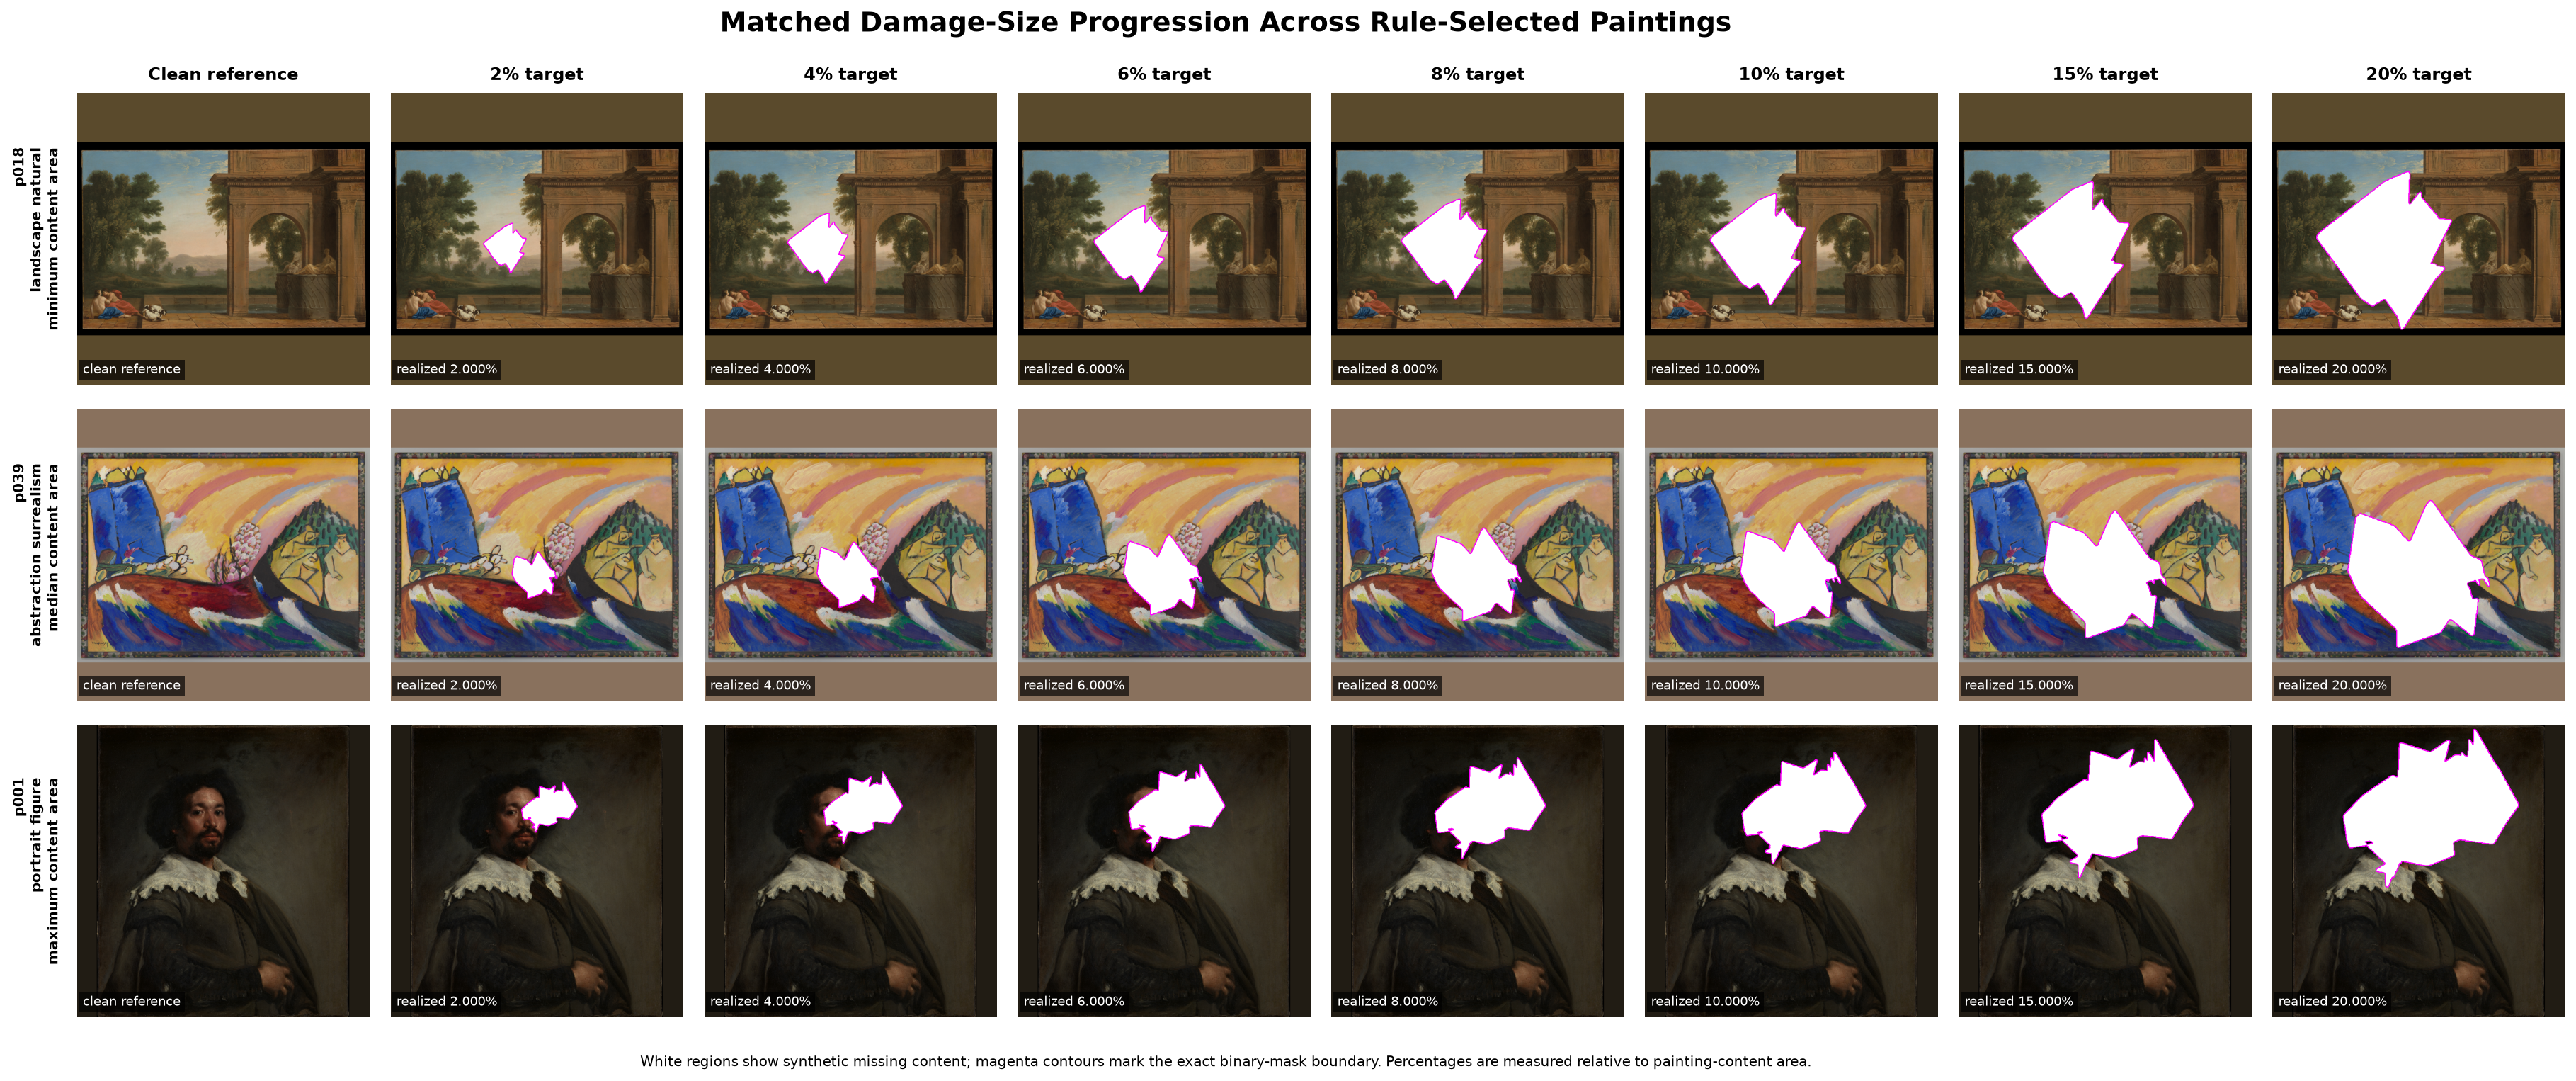

In [14]:
# ---------------------------------------------------------------------------
# Canonical figure setup
# ---------------------------------------------------------------------------

FIGURE_PATH = OUTPUT_PATHS[
    "damage_size_progression_figure"
]

FIGURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_SIZE_INCHES = (
    24.0,
    9.6,
)

progression_figure, progression_axes = (
    plt.subplots(
        nrows=len(
            EXAMPLE_PAINTING_IDS
        ),
        ncols=len(
            EXAMPLE_COLUMN_IDS
        ),
        figsize=FIGURE_SIZE_INCHES,
        dpi=FIGURE_DPI,
        squeeze=False,
    )
)

progression_figure.patch.set_facecolor(
    "white"
)

figure_panel_records = []
figure_clean_source_paths = []
rendered_contour_count = 0
rendered_realized_annotation_count = 0


# ---------------------------------------------------------------------------
# Render clean references and seven matched damage levels
# ---------------------------------------------------------------------------

for row_index, painting_id in enumerate(
    EXAMPLE_PAINTING_IDS
):
    cohort_rows = (
        sensitivity_cohort_df.loc[
            sensitivity_cohort_df[
                "painting_id"
            ]
            .astype(str)
            .eq(
                painting_id
            )
        ]
    )

    if len(
        cohort_rows
    ) != 1:
        raise RuntimeError(
            "Expected exactly one cohort row for "
            f"{painting_id}; observed "
            f"{len(cohort_rows)}."
        )

    cohort_row = (
        cohort_rows.iloc[
            0
        ]
    )

    category_label = (
        configured_category_by_painting[
            painting_id
        ]
        .replace(
            "_",
            " ",
        )
    )

    selection_role = (
        selection_role_by_painting[
            painting_id
        ]
    )

    clean_path = resolve_repo_path(
        str(
            cohort_row[
                "processed_path"
            ]
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    figure_clean_source_paths.append(
        clean_path.resolve()
    )

    with Image.open(
        clean_path
    ) as clean_handle:
        clean_image = (
            clean_handle
            .convert(
                "RGB"
            )
            .copy()
        )

    clean_axis = progression_axes[
        row_index,
        0,
    ]

    clean_axis.imshow(
        clean_image
    )

    clean_axis.text(
        0.02,
        0.03,
        "clean reference",
        transform=clean_axis.transAxes,
        color="white",
        fontsize=8,
        ha="left",
        va="bottom",
        bbox={
            "facecolor": "black",
            "alpha": 0.68,
            "edgecolor": "none",
            "pad": 2.5,
        },
    )

    clean_axis.text(
        -0.05,
        0.5,
        (
            f"{painting_id}\n"
            f"{category_label}\n"
            f"{selection_role}"
        ),
        transform=clean_axis.transAxes,
        fontsize=9,
        fontweight="semibold",
        ha="right",
        va="center",
        rotation=90,
    )

    if row_index == 0:
        clean_axis.set_title(
            "Clean reference",
            fontsize=11,
            fontweight="semibold",
            pad=8,
        )

    for column_index, (
        level_id,
        target_percentage,
    ) in enumerate(
        CONFIGURED_LEVELS,
        start=1,
    ):
        case_rows = (
            damage_size_cases_df.loc[
                (
                    damage_size_cases_df[
                        "painting_id"
                    ]
                    .astype(str)
                    .eq(
                        painting_id
                    )
                )
                &
                (
                    damage_size_cases_df[
                        "level_id"
                    ]
                    .astype(str)
                    .eq(
                        level_id
                    )
                )
            ]
        )

        if len(
            case_rows
        ) != 1:
            raise RuntimeError(
                "Expected exactly one figure case "
                f"for {painting_id}/{level_id}; "
                f"observed {len(case_rows)}."
            )

        case_row = (
            case_rows.iloc[
                0
            ]
        )

        damaged_path = resolve_repo_path(
            str(
                case_row[
                    "input_image_path"
                ]
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        mask_path = resolve_repo_path(
            str(
                case_row[
                    "mask_or_effect_path"
                ]
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        with Image.open(
            damaged_path
        ) as damaged_handle:
            damaged_image = (
                damaged_handle
                .convert(
                    "RGB"
                )
                .copy()
            )

        with Image.open(
            mask_path
        ) as mask_handle:
            mask_array = (
                np.asarray(
                    mask_handle.convert(
                        "L"
                    ),
                    dtype=np.uint8,
                )
                == 255
            )

        realized_percentage = (
            float(
                case_row[
                    "realized_damage_fraction"
                ]
            )
            * 100.0
        )

        panel_axis = progression_axes[
            row_index,
            column_index,
        ]

        panel_axis.imshow(
            damaged_image
        )

        if OVERLAY_MASK_CONTOUR:
            panel_axis.contour(
                mask_array.astype(
                    np.uint8
                ),
                levels=[
                    0.5,
                ],
                colors=[
                    "magenta",
                ],
                linewidths=0.65,
            )

            rendered_contour_count += 1

        if ANNOTATE_REALIZED_PERCENTAGE:
            panel_axis.text(
                0.02,
                0.03,
                (
                    f"realized "
                    f"{realized_percentage:.3f}%"
                ),
                transform=panel_axis.transAxes,
                color="white",
                fontsize=8,
                ha="left",
                va="bottom",
                bbox={
                    "facecolor": "black",
                    "alpha": 0.68,
                    "edgecolor": "none",
                    "pad": 2.5,
                },
            )

            rendered_realized_annotation_count += 1

        if row_index == 0:
            panel_axis.set_title(
                (
                    f"{target_percentage:.0f}% "
                    "target"
                ),
                fontsize=11,
                fontweight="semibold",
                pad=8,
            )

        figure_panel_records.append(
            {
                "case_id": str(
                    case_row[
                        "case_id"
                    ]
                ),
                "painting_id": painting_id,
                "level_id": level_id,
                "target_percentage": float(
                    target_percentage
                ),
                "realized_percentage": (
                    realized_percentage
                ),
                "damaged_path": to_repo_relative(
                    damaged_path,
                    PROJECT_ROOT,
                ),
                "mask_path": to_repo_relative(
                    mask_path,
                    PROJECT_ROOT,
                ),
                "mask_pixels": int(
                    mask_array.sum()
                ),
                "recorded_mask_pixels": int(
                    case_row[
                        "realized_damage_pixels"
                    ]
                ),
            }
        )


# ---------------------------------------------------------------------------
# Standardize axes and figure annotations
# ---------------------------------------------------------------------------

for axis in (
    progression_axes.ravel()
):
    axis.set_xticks([])
    axis.set_yticks([])

    for spine in (
        axis.spines.values()
    ):
        spine.set_visible(
            False
        )

progression_figure.suptitle(
    (
        "Matched Damage-Size Progression "
        "Across Rule-Selected Paintings"
    ),
    fontsize=17,
    fontweight="semibold",
    y=0.985,
)

progression_figure.text(
    0.5,
    0.012,
    (
        "White regions show synthetic missing content; "
        "magenta contours mark the exact binary-mask boundary. "
        "Percentages are measured relative to painting-content area."
    ),
    ha="center",
    va="bottom",
    fontsize=9,
)

progression_figure.subplots_adjust(
    left=0.075,
    right=0.995,
    bottom=0.06,
    top=0.91,
    wspace=0.025,
    hspace=0.08,
)


# ---------------------------------------------------------------------------
# Persist the one approved Batch 6 figure
# ---------------------------------------------------------------------------

progression_figure.savefig(
    FIGURE_PATH,
    format="png",
    dpi=FIGURE_DPI,
    facecolor="white",
    metadata={
        "Title": (
            "Matched Damage-Size Progression"
        ),
        "Description": (
            EXAMPLE_SELECTION_RULE
        ),
        "Software": (
            f"restoration_eval {PACKAGE_VERSION}"
        ),
    },
)

figure_panel_records_df = pd.DataFrame(
    figure_panel_records
)

print(
    "Saved canonical figure:",
    to_repo_relative(
        FIGURE_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Figure panels:",
    progression_axes.size,
)

print(
    "Generated-case panels:",
    len(
        figure_panel_records_df
    ),
)

print(
    "Contour overlays:",
    rendered_contour_count,
)

print(
    "Realized-percentage annotations:",
    rendered_realized_annotation_count,
)

plt.show()

In [15]:
# ---------------------------------------------------------------------------
# Reload the persisted figure independently
# ---------------------------------------------------------------------------

with Image.open(
    FIGURE_PATH
) as figure_handle:
    persisted_figure_format = (
        figure_handle.format
    )

    persisted_figure_mode = (
        figure_handle.mode
    )

    persisted_figure_dimensions = (
        figure_handle.size
    )

    figure_handle.verify()

persisted_figure_size_bytes = int(
    FIGURE_PATH.stat().st_size
)

persisted_figure_sha256 = (
    sha256_file(
        FIGURE_PATH
    )
)

expected_figure_dimensions = (
    int(
        round(
            FIGURE_SIZE_INCHES[
                0
            ]
            * FIGURE_DPI
        )
    ),
    int(
        round(
            FIGURE_SIZE_INCHES[
                1
            ]
            * FIGURE_DPI
        )
    ),
)


# ---------------------------------------------------------------------------
# Reconcile filesystem changes
# ---------------------------------------------------------------------------

batch_6_output_fingerprints_after = {
    path.resolve(): (
        int(
            path.stat().st_size
        ),
        sha256_file(
            path
        ),
    )
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

batch_6_changed_paths = {
    path
    for path in (
        set(
            batch_6_output_fingerprints_before
        )
        | set(
            batch_6_output_fingerprints_after
        )
    )
    if (
        batch_6_output_fingerprints_before
        .get(
            path
        )
        != batch_6_output_fingerprints_after
        .get(
            path
        )
    )
}

batch_6_unapproved_changed_paths = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        batch_6_changed_paths
        - {
            FIGURE_PATH.resolve(),
        }
    )
)

batch_6_files_after = set(
    batch_6_output_fingerprints_after
)

batch_6_new_files = (
    batch_6_files_after
    - set(
        batch_6_output_fingerprints_before
    )
)


# ---------------------------------------------------------------------------
# Batch 6 validation collector
# ---------------------------------------------------------------------------

BATCH_6_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_6_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "scientific_summary_and_figure"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Rule-based representative selection
# ---------------------------------------------------------------------------

selection_rule_passed = (
    EXAMPLE_SELECTION_RULE
    == (
        "minimum_median_maximum_"
        "content_area_within_pinned_cohort"
    )
    and EXAMPLE_PAINTING_IDS
    == derived_example_painting_ids
    and len(
        example_selection_df
    )
    == 3
)

add_batch_6_check(
    check_id="figure_selection_rule",
    description=(
        "Representative paintings are the "
        "independently derived minimum, median, "
        "and maximum content-area cases."
    ),
    expected={
        "selection_rule": (
            "minimum_median_maximum_"
            "content_area_within_pinned_cohort"
        ),
        "painting_ids": (
            derived_example_painting_ids
        ),
    },
    observed={
        "selection_rule": (
            EXAMPLE_SELECTION_RULE
        ),
        "painting_ids": (
            EXAMPLE_PAINTING_IDS
        ),
    },
    passed=selection_rule_passed,
)


# ---------------------------------------------------------------------------
# 2. Level-summary matched-design coverage
# ---------------------------------------------------------------------------

level_summary_passed = (
    tuple(
        batch_6_level_summary_df[
            "level_id"
        ].astype(str)
    )
    == LEVEL_IDS
    and len(
        batch_6_level_summary_df
    )
    == EXPECTED_TARGET_LEVEL_COUNT
    and batch_6_level_summary_df[
        "cases"
    ].eq(
        EXPECTED_PAINTING_COUNT
    ).all()
)

add_batch_6_check(
    check_id="figure_level_summary_coverage",
    description=(
        "The scientific summary covers all seven "
        "levels with all five paintings at each level."
    ),
    expected={
        "levels": LEVEL_IDS,
        "cases_per_level": (
            EXPECTED_PAINTING_COUNT
        ),
    },
    observed={
        "levels": tuple(
            batch_6_level_summary_df[
                "level_id"
            ].astype(str)
        ),
        "cases_per_level": (
            batch_6_level_summary_df[
                [
                    "level_id",
                    "cases",
                ]
            ].to_dict(
                orient="records"
            )
        ),
    },
    passed=level_summary_passed,
)


# ---------------------------------------------------------------------------
# 3. Figure source-case coverage
# ---------------------------------------------------------------------------

expected_figure_case_pairs = {
    (
        painting_id,
        level_id,
    )
    for painting_id in (
        EXAMPLE_PAINTING_IDS
    )
    for level_id in LEVEL_IDS
}

observed_figure_case_pairs = set(
    zip(
        figure_panel_records_df[
            "painting_id"
        ].astype(str),
        figure_panel_records_df[
            "level_id"
        ].astype(str),
    )
)

figure_source_coverage_passed = (
    len(
        figure_panel_records_df
    )
    == 21
    and figure_panel_records_df[
        "case_id"
    ].nunique()
    == 21
    and observed_figure_case_pairs
    == expected_figure_case_pairs
    and figure_panel_records_df[
        "mask_pixels"
    ].eq(
        figure_panel_records_df[
            "recorded_mask_pixels"
        ]
    ).all()
    and len(
        set(
            figure_clean_source_paths
        )
    )
    == 3
)

add_batch_6_check(
    check_id="figure_source_case_coverage",
    description=(
        "The figure uses exactly the 21 configured "
        "painting-level cases plus three unique clean "
        "references, with mask pixels reconciled."
    ),
    expected={
        "generated_panels": 21,
        "clean_references": 3,
        "mask_pixel_mismatches": 0,
    },
    observed={
        "generated_panels": len(
            figure_panel_records_df
        ),
        "clean_references": len(
            set(
                figure_clean_source_paths
            )
        ),
        "mask_pixel_mismatches": int(
            (
                figure_panel_records_df[
                    "mask_pixels"
                ]
                != figure_panel_records_df[
                    "recorded_mask_pixels"
                ]
            ).sum()
        ),
    },
    passed=figure_source_coverage_passed,
)


# ---------------------------------------------------------------------------
# 4. Canonical three-by-eight layout
# ---------------------------------------------------------------------------

figure_layout_passed = (
    progression_axes.shape
    == (
        3,
        8,
    )
    and len(
        progression_figure.axes
    )
    == 24
    and EXAMPLE_COLUMN_IDS
    == (
        "clean",
        *LEVEL_IDS,
    )
)

add_batch_6_check(
    check_id="canonical_figure_layout",
    description=(
        "The canonical progression uses three "
        "rule-selected painting rows and eight "
        "clean/level columns."
    ),
    expected={
        "axes_shape": [
            3,
            8,
        ],
        "axis_count": 24,
        "columns": (
            "clean",
            *LEVEL_IDS,
        ),
    },
    observed={
        "axes_shape": list(
            progression_axes.shape
        ),
        "axis_count": len(
            progression_figure.axes
        ),
        "columns": (
            EXAMPLE_COLUMN_IDS
        ),
    },
    passed=figure_layout_passed,
)


# ---------------------------------------------------------------------------
# 5. Contour and annotation coverage
# ---------------------------------------------------------------------------

overlay_annotation_passed = (
    OVERLAY_MASK_CONTOUR
    and ANNOTATE_REALIZED_PERCENTAGE
    and rendered_contour_count
    == 21
    and rendered_realized_annotation_count
    == 21
)

add_batch_6_check(
    check_id="figure_overlay_annotation_coverage",
    description=(
        "Every damaged panel contains a magenta "
        "mask contour and a realized-area annotation."
    ),
    expected={
        "contours": 21,
        "realized_annotations": 21,
    },
    observed={
        "contours": (
            rendered_contour_count
        ),
        "realized_annotations": (
            rendered_realized_annotation_count
        ),
    },
    passed=overlay_annotation_passed,
)


# ---------------------------------------------------------------------------
# 6. Notebook-owned figure path
# ---------------------------------------------------------------------------

figure_path_passed = (
    FIGURE_PATH.resolve()
    == (
        OUTPUT_ROOT
        / "figures"
        / "damage_size_progression.png"
    ).resolve()
    and FIGURE_PATH.resolve().is_relative_to(
        OUTPUT_ROOT.resolve()
    )
)

add_batch_6_check(
    check_id="figure_output_path_contract",
    description=(
        "The canonical figure is written only to "
        "the approved Notebook 05 figure path."
    ),
    expected=(
        "outputs/05_damage_size_sensitivity_"
        "dataset_generation/figures/"
        "damage_size_progression.png"
    ),
    observed=to_repo_relative(
        FIGURE_PATH,
        PROJECT_ROOT,
    ),
    passed=figure_path_passed,
)


# ---------------------------------------------------------------------------
# 7. Persisted figure readability and metadata
# ---------------------------------------------------------------------------

figure_reload_passed = (
    persisted_figure_format
    == "PNG"
    and persisted_figure_mode
    in {
        "RGB",
        "RGBA",
    }
    and persisted_figure_dimensions
    == expected_figure_dimensions
)

add_batch_6_check(
    check_id="persisted_figure_reload",
    description=(
        "The saved figure reloads as the expected "
        "full-resolution PNG with a standard colour mode."
    ),
    expected={
        "format": "PNG",
        "modes": [
            "RGB",
            "RGBA",
        ],
        "dimensions": (
            expected_figure_dimensions
        ),
    },
    observed={
        "format": (
            persisted_figure_format
        ),
        "mode": (
            persisted_figure_mode
        ),
        "dimensions": (
            persisted_figure_dimensions
        ),
    },
    passed=figure_reload_passed,
)


# ---------------------------------------------------------------------------
# 8. Positive file size and checksum
# ---------------------------------------------------------------------------

figure_file_integrity_passed = (
    persisted_figure_size_bytes
    > 0
    and len(
        persisted_figure_sha256
    )
    == 64
)

add_batch_6_check(
    check_id="persisted_figure_integrity",
    description=(
        "The canonical figure has a positive file "
        "size and a complete SHA-256 checksum."
    ),
    expected={
        "minimum_bytes": 1,
        "sha256_length": 64,
    },
    observed={
        "size_bytes": (
            persisted_figure_size_bytes
        ),
        "sha256": (
            persisted_figure_sha256
        ),
    },
    passed=figure_file_integrity_passed,
)


# ---------------------------------------------------------------------------
# 9. Approved Batch 6 write scope
# ---------------------------------------------------------------------------

batch_6_write_scope_passed = (
    not (
        batch_6_unapproved_changed_paths
    )
    and batch_6_new_files.issubset(
        {
            FIGURE_PATH.resolve(),
        }
    )
    and FIGURE_PATH.resolve()
    in batch_6_files_after
)

add_batch_6_check(
    check_id="batch_6_write_scope",
    description=(
        "Batch 6 creates or replaces only the "
        "approved canonical progression figure."
    ),
    expected={
        "unapproved_changed_paths": 0,
        "allowed_path": to_repo_relative(
            FIGURE_PATH,
            PROJECT_ROOT,
        ),
    },
    observed={
        "new_paths": sorted(
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in (
                batch_6_new_files
            )
        ),
        "unapproved_changed_paths": (
            batch_6_unapproved_changed_paths
        ),
    },
    passed=batch_6_write_scope_passed,
    details=(
        batch_6_unapproved_changed_paths
    ),
)


# ---------------------------------------------------------------------------
# 10. No premature persistence artifacts
# ---------------------------------------------------------------------------

current_batch_6_files = sorted(
    path
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
)

unexpected_non_png_files = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        current_batch_6_files
    )
    if path.suffix.lower()
    != ".png"
]

batch_6_stage_scope_passed = (
    len(
        current_batch_6_files
    )
    == 71
    and not (
        unexpected_non_png_files
    )
)

add_batch_6_check(
    check_id="batch_6_stage_scope",
    description=(
        "Before persistence, the output root contains "
        "only 70 generated images and the one approved "
        "progression figure."
    ),
    expected={
        "total_files": 71,
        "non_png_files": 0,
    },
    observed={
        "total_files": len(
            current_batch_6_files
        ),
        "non_png_files": len(
            unexpected_non_png_files
        ),
    },
    passed=batch_6_stage_scope_passed,
    details=unexpected_non_png_files,
)


# ---------------------------------------------------------------------------
# Batch 6 completion gate
# ---------------------------------------------------------------------------

BATCH_6_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_6_START_CHECK_COUNT
)

if BATCH_6_CHECK_COUNT != 10:
    raise RuntimeError(
        "Batch 6 must add exactly 10 checks; "
        f"observed {BATCH_6_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_6_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_6_START_CHECK_COUNT:
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 6 validation checks:"
)

display(
    batch_6_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nPersisted figure:"
)

display(
    pd.DataFrame(
        [
            {
                "relative_path": (
                    to_repo_relative(
                        FIGURE_PATH,
                        PROJECT_ROOT,
                    )
                ),
                "format": (
                    persisted_figure_format
                ),
                "mode": (
                    persisted_figure_mode
                ),
                "width": int(
                    persisted_figure_dimensions[
                        0
                    ]
                ),
                "height": int(
                    persisted_figure_dimensions[
                        1
                    ]
                ),
                "size_bytes": (
                    persisted_figure_size_bytes
                ),
                "sha256": (
                    persisted_figure_sha256
                ),
            }
        ]
    )
)

print(
    "\nBatch 6 completed successfully."
)

print(
    "Batch 6 checks:",
    BATCH_6_CHECK_COUNT,
)

print(
    "Total checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Current Notebook 05 output files:",
    len(
        current_batch_6_files
    ),
)

print(
    "Figure size (bytes):",
    persisted_figure_size_bytes,
)

print(
    "Next approved stage: Batch 7 - "
    "persist canonical tables, validation checks, "
    "artifact manifest, and provisional run manifest."
)

plt.close(
    progression_figure
)

Batch 6 validation checks:


,check_id,severity,expected,observed,passed
0,figure_selection_rule,blocking,"{""painting_ids"": [""p018"", ""p039"", ""p001""], ""se...","{""painting_ids"": [""p018"", ""p039"", ""p001""], ""se...",True
1,figure_level_summary_coverage,blocking,"{""cases_per_level"": 5, ""levels"": [""size_02pct""...","{""cases_per_level"": [{""cases"": 5, ""level_id"": ...",True
2,figure_source_case_coverage,blocking,"{""clean_references"": 3, ""generated_panels"": 21...","{""clean_references"": 3, ""generated_panels"": 21...",True
3,canonical_figure_layout,blocking,"{""axes_shape"": [3, 8], ""axis_count"": 24, ""colu...","{""axes_shape"": [3, 8], ""axis_count"": 24, ""colu...",True
4,figure_overlay_annotation_coverage,blocking,"{""contours"": 21, ""realized_annotations"": 21}","{""contours"": 21, ""realized_annotations"": 21}",True
5,figure_output_path_contract,blocking,outputs/05_damage_size_sensitivity_dataset_gen...,outputs/05_damage_size_sensitivity_dataset_gen...,True
6,persisted_figure_reload,blocking,"{""dimensions"": [3840, 1536], ""format"": ""PNG"", ...","{""dimensions"": [3840, 1536], ""format"": ""PNG"", ...",True
7,persisted_figure_integrity,blocking,"{""minimum_bytes"": 1, ""sha256_length"": 64}","{""sha256"": ""85a4113d6670aa3dbd0f309b905af9acd7...",True
8,batch_6_write_scope,blocking,"{""allowed_path"": ""outputs/05_damage_size_sensi...","{""new_paths"": [""outputs/05_damage_size_sensiti...",True
9,batch_6_stage_scope,blocking,"{""non_png_files"": 0, ""total_files"": 71}","{""non_png_files"": 0, ""total_files"": 71}",True



Persisted figure:


,relative_path,format,mode,width,height,size_bytes,sha256
0,outputs/05_damage_size_sensitivity_dataset_gen...,PNG,RGBA,3840,1536,4094033,85a4113d6670aa3dbd0f309b905af9acd750a1fde2256b...



Batch 6 completed successfully.
Batch 6 checks: 10
Total checks: 96
Blocking failures: 0
Current Notebook 05 output files: 71
Figure size (bytes): 4094033
Next approved stage: Batch 7 - persist canonical tables, validation checks, artifact manifest, and provisional run manifest.


## Batch 7 — Canonical Persistence and Provisional Handoff

This batch persists the validated Notebook 05 handoff:

- `data/cases.csv`;
- `metrics/generation_audit.csv`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- provisional `manifests/run_manifest.json`.

The 96 consolidated scientific checks remain separate from the persistence and handoff validation gates.

The run manifest remains in a `running` state until Batch 8 performs the final independent completion audit, project-path registry update, and completed-manifest rewrite.

In [16]:
# ---------------------------------------------------------------------------
# Batch 7 helper imports and expected counts
# ---------------------------------------------------------------------------

from restoration_eval.damage_sensitivity import (
    write_dataframe_atomic,
)

from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


EXPECTED_CONSOLIDATED_VALIDATION_ROWS = 96


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The consolidated Notebook 05 validation "
        "gate has not passed."
    )

validation_checks_df = (
    VALIDATION.to_dataframe()
)

if len(
    validation_checks_df
) != EXPECTED_CONSOLIDATED_VALIDATION_ROWS:
    raise RuntimeError(
        "Exactly "
        f"{EXPECTED_CONSOLIDATED_VALIDATION_ROWS} "
        "consolidated validation rows are required; "
        f"found {len(validation_checks_df)}."
    )

if len(
    damage_size_cases_df
) != EXPECTED_CASE_COUNT:
    raise RuntimeError(
        "The damage-size case table does not contain "
        "the expected number of rows."
    )

if len(
    damage_size_generation_audit_df
) != EXPECTED_AUDIT_ROW_COUNT:
    raise RuntimeError(
        "The generation audit does not contain "
        "the expected number of rows."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in (
    OUTPUT_PATHS.items()
):
    try:
        validated_output_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if (
            validated_output_path
            != output_path.resolve()
        ):
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(
                        output_path
                    ),
                    "issue": (
                        "resolved_path_mismatch"
                    ),
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(
                    output_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate "
        "Notebook 05 ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Atomic canonical CSV persistence
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    damage_size_cases_df,
    OUTPUT_PATHS[
        "damage_size_cases"
    ],
)

write_dataframe_atomic(
    damage_size_generation_audit_df,
    OUTPUT_PATHS[
        "damage_size_generation_audit"
    ],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUT_PATHS[
        "validation_checks"
    ],
)


# ---------------------------------------------------------------------------
# Immediate independent CSV reload
# ---------------------------------------------------------------------------

damage_size_cases_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "damage_size_cases"
        ],
        low_memory=False,
    )
)

damage_size_audit_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "damage_size_generation_audit"
        ],
        low_memory=False,
    )
)

validation_checks_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "validation_checks"
        ],
        low_memory=False,
    )
)


cases_reload_schema_result = (
    validate_dataframe(
        damage_size_cases_reloaded_df,
        DAMAGE_SIZE_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

audit_reload_schema_result = (
    validate_dataframe(
        damage_size_audit_reloaded_df,
        DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_reload_schema_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Reload identity evidence
# ---------------------------------------------------------------------------

expected_case_ids = set(
    damage_size_cases_df[
        "case_id"
    ].astype(str)
)

reloaded_case_ids = set(
    damage_size_cases_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_audit_case_ids = set(
    damage_size_generation_audit_df[
        "case_id"
    ].astype(str)
)

reloaded_audit_case_ids = set(
    damage_size_audit_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_mask_paths = set(
    damage_size_cases_df[
        "mask_or_effect_path"
    ].astype(str)
)

reloaded_mask_paths = set(
    damage_size_cases_reloaded_df[
        "mask_or_effect_path"
    ].astype(str)
)

expected_damaged_paths = set(
    damage_size_cases_df[
        "input_image_path"
    ].astype(str)
)

reloaded_damaged_paths = set(
    damage_size_cases_reloaded_df[
        "input_image_path"
    ].astype(str)
)

expected_validation_keys = {
    (
        str(
            check.validation_stage
        ),
        str(
            check.check_id
        ),
    )
    for check in (
        VALIDATION.checks
    )
}

reloaded_validation_keys = {
    (
        str(
            row.validation_stage
        ),
        str(
            row.check_id
        ),
    )
    for row in (
        validation_checks_reloaded_df
        .itertuples(
            index=False
        )
    )
}

all_reloaded_validation_checks_passed = bool(
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq(
        "true"
    )
    .all()
)


# ---------------------------------------------------------------------------
# Reload and checksum both generated image collections
# ---------------------------------------------------------------------------

reloaded_mask_files = sorted(
    path
    for path in (
        MASK_OUTPUT_DIRECTORY.rglob(
            "*.png"
        )
    )
    if path.is_file()
)

reloaded_damaged_files = sorted(
    path
    for path in (
        DAMAGED_OUTPUT_DIRECTORY.rglob(
            "*.png"
        )
    )
    if path.is_file()
)

reloaded_mask_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        reloaded_mask_files
    )
}

reloaded_damaged_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        reloaded_damaged_files
    )
}

mask_checksum_failures = []
damaged_checksum_failures = []

for case_row in (
    damage_size_cases_reloaded_df
    .itertuples(
        index=False
    )
):
    mask_path = resolve_repo_path(
        str(
            case_row.mask_or_effect_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    damaged_path = resolve_repo_path(
        str(
            case_row.input_image_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_mask_checksum = (
        sha256_file(
            mask_path
        )
    )

    observed_damaged_checksum = (
        sha256_file(
            damaged_path
        )
    )

    if (
        observed_mask_checksum
        != str(
            case_row.mask_sha256
        )
    ):
        mask_checksum_failures.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "relative_path": (
                    case_row.mask_or_effect_path
                ),
                "expected_checksum": (
                    case_row.mask_sha256
                ),
                "observed_checksum": (
                    observed_mask_checksum
                ),
            }
        )

    if (
        observed_damaged_checksum
        != str(
            case_row.damaged_image_sha256
        )
    ):
        damaged_checksum_failures.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "relative_path": (
                    case_row.input_image_path
                ),
                "expected_checksum": (
                    case_row.damaged_image_sha256
                ),
                "observed_checksum": (
                    observed_damaged_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Reload persisted canonical figure
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "damage_size_progression_figure"
    ]
) as figure_file:
    figure_file.load()

    persisted_figure_evidence = {
        "format": str(
            figure_file.format
        ),
        "mode": str(
            figure_file.mode
        ),
        "width": int(
            figure_file.width
        ),
        "height": int(
            figure_file.height
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "damage_size_progression_figure"
            ]
        ),
    }


# ---------------------------------------------------------------------------
# Separate canonical-persistence validation gate
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = (
    ValidationCollector()
)


def add_persistence_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


add_persistence_check(
    check_id="output_path_ownership",
    description=(
        "Every declared output remains inside "
        "the exact Notebook 05 output root."
    ),
    expected=[],
    observed=output_ownership_failures,
    passed=not output_ownership_failures,
)


cases_reload_passed = (
    cases_reload_schema_result.passed
    and not (
        cases_reload_schema_result
        .unexpected_columns
    )
    and len(
        damage_size_cases_reloaded_df
    )
    == EXPECTED_CASE_COUNT
    and reloaded_case_ids
    == expected_case_ids
    and reloaded_mask_paths
    == expected_mask_paths
    and reloaded_damaged_paths
    == expected_damaged_paths
)

add_persistence_check(
    check_id="damage_size_cases_csv_reload",
    description=(
        "Persisted cases.csv reloads under "
        "damage_size_cases.v1 with every expected "
        "case, mask path, and damaged-image path."
    ),
    expected={
        "rows": EXPECTED_CASE_COUNT,
        "schema_passed": True,
        "case_ids_match": True,
        "mask_paths_match": True,
        "damaged_paths_match": True,
    },
    observed={
        "rows": len(
            damage_size_cases_reloaded_df
        ),
        "schema": (
            cases_reload_schema_result
            .to_dict()
        ),
        "case_ids_match": (
            reloaded_case_ids
            == expected_case_ids
        ),
        "mask_paths_match": (
            reloaded_mask_paths
            == expected_mask_paths
        ),
        "damaged_paths_match": (
            reloaded_damaged_paths
            == expected_damaged_paths
        ),
    },
    passed=cases_reload_passed,
)


audit_reload_passed = (
    audit_reload_schema_result.passed
    and not (
        audit_reload_schema_result
        .unexpected_columns
    )
    and len(
        damage_size_audit_reloaded_df
    )
    == EXPECTED_AUDIT_ROW_COUNT
    and reloaded_audit_case_ids
    == expected_audit_case_ids
    and damage_size_audit_reloaded_df[
        "validation_status"
    ].eq(
        "passed"
    ).all()
)

add_persistence_check(
    check_id="generation_audit_csv_reload",
    description=(
        "Persisted generation_audit.csv reloads "
        "under damage_size_generation_audit.v1 "
        "with every expected passing case."
    ),
    expected={
        "rows": EXPECTED_AUDIT_ROW_COUNT,
        "schema_passed": True,
        "case_ids_match": True,
        "failed_cases": 0,
    },
    observed={
        "rows": len(
            damage_size_audit_reloaded_df
        ),
        "schema": (
            audit_reload_schema_result
            .to_dict()
        ),
        "case_ids_match": (
            reloaded_audit_case_ids
            == expected_audit_case_ids
        ),
        "failed_cases": int(
            damage_size_audit_reloaded_df[
                "validation_status"
            ]
            .ne(
                "passed"
            )
            .sum()
        ),
    },
    passed=audit_reload_passed,
)


validation_csv_reload_passed = (
    validation_reload_schema_result.passed
    and not (
        validation_reload_schema_result
        .unexpected_columns
    )
    and len(
        validation_checks_reloaded_df
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and reloaded_validation_keys
    == expected_validation_keys
    and all_reloaded_validation_checks_passed
)

add_persistence_check(
    check_id="validation_checks_csv_reload",
    description=(
        "Persisted checks.csv reloads under "
        "validation_checks.v1 with all 96 unique "
        "passing consolidated checks."
    ),
    expected={
        "rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "schema": (
            validation_reload_schema_result
            .to_dict()
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": (
            all_reloaded_validation_checks_passed
        ),
    },
    passed=validation_csv_reload_passed,
)


mask_collection_reload_passed = (
    len(
        reloaded_mask_files
    )
    == EXPECTED_MASK_FILE_COUNT
    and reloaded_mask_relative_paths
    == expected_mask_paths
    and not (
        mask_checksum_failures
    )
)

add_persistence_check(
    check_id="damage_size_mask_collection_reload",
    description=(
        "The persisted damage-size mask collection "
        "contains exactly 35 declared PNGs and every "
        "mask matches its case-table checksum."
    ),
    expected={
        "file_count": (
            EXPECTED_MASK_FILE_COUNT
        ),
        "paths_match": True,
        "checksum_failures": 0,
    },
    observed={
        "file_count": len(
            reloaded_mask_files
        ),
        "paths_match": (
            reloaded_mask_relative_paths
            == expected_mask_paths
        ),
        "checksum_failures": len(
            mask_checksum_failures
        ),
    },
    passed=mask_collection_reload_passed,
    details=mask_checksum_failures,
)


damaged_collection_reload_passed = (
    len(
        reloaded_damaged_files
    )
    == EXPECTED_DAMAGED_FILE_COUNT
    and reloaded_damaged_relative_paths
    == expected_damaged_paths
    and not (
        damaged_checksum_failures
    )
)

add_persistence_check(
    check_id="damage_size_damaged_collection_reload",
    description=(
        "The persisted damaged-image collection "
        "contains exactly 35 declared PNGs and every "
        "image matches its case-table checksum."
    ),
    expected={
        "file_count": (
            EXPECTED_DAMAGED_FILE_COUNT
        ),
        "paths_match": True,
        "checksum_failures": 0,
    },
    observed={
        "file_count": len(
            reloaded_damaged_files
        ),
        "paths_match": (
            reloaded_damaged_relative_paths
            == expected_damaged_paths
        ),
        "checksum_failures": len(
            damaged_checksum_failures
        ),
    },
    passed=damaged_collection_reload_passed,
    details=damaged_checksum_failures,
)


figure_reload_passed = (
    persisted_figure_evidence[
        "format"
    ]
    == "PNG"
    and persisted_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and persisted_figure_evidence[
        "width"
    ]
    == expected_figure_dimensions[
        0
    ]
    and persisted_figure_evidence[
        "height"
    ]
    == expected_figure_dimensions[
        1
    ]
    and persisted_figure_evidence[
        "sha256"
    ]
    == persisted_figure_sha256
)

add_persistence_check(
    check_id="damage_size_progression_figure_reload",
    description=(
        "The canonical progression figure reloads "
        "as a readable full-resolution PNG and "
        "retains its Batch 6 checksum."
    ),
    expected={
        "format": "PNG",
        "allowed_modes": [
            "RGB",
            "RGBA",
        ],
        "dimensions": (
            expected_figure_dimensions
        ),
        "checksum": (
            persisted_figure_sha256
        ),
    },
    observed=persisted_figure_evidence,
    passed=figure_reload_passed,
)


persistence_checks_df = (
    PERSISTENCE_VALIDATION
    .to_dataframe()
)

if len(
    persistence_checks_df
) != 7:
    raise RuntimeError(
        "Batch 7 must produce exactly seven "
        "canonical-persistence checks."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()

print(
    "Canonical persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Persisted cases:",
    damage_size_cases_reloaded_df.shape,
)

print(
    "Persisted generation audit:",
    damage_size_audit_reloaded_df.shape,
)

print(
    "Persisted consolidated checks:",
    validation_checks_reloaded_df.shape,
)

Canonical persistence validation passed: True


,check_id,severity,passed
0,output_path_ownership,blocking,True
1,damage_size_cases_csv_reload,blocking,True
2,generation_audit_csv_reload,blocking,True
3,validation_checks_csv_reload,blocking,True
4,damage_size_mask_collection_reload,blocking,True
5,damage_size_damaged_collection_reload,blocking,True
6,damage_size_progression_figure_reload,blocking,True


Persisted cases: (35, 55)
Persisted generation audit: (35, 67)
Persisted consolidated checks: (96, 8)


In [17]:
# ---------------------------------------------------------------------------
# Normalized artifact manifest
# ---------------------------------------------------------------------------

dataset_scope = str(
    sensitivity_config[
        "dataset"
    ][
        "dataset_scope"
    ]
)

experiment_id = str(
    sensitivity_config[
        "dataset"
    ][
        "experiment_id"
    ]
)

artifact_specifications = [
    {
        "artifact_key": (
            "damage_size_cases"
        ),
        "path": OUTPUT_PATHS[
            "damage_size_cases"
        ],
        "artifact_type": (
            "dataset_table"
        ),
        "output_key": (
            "damage_size_cases"
        ),
        "row_count": len(
            damage_size_cases_reloaded_df
        ),
    },
    {
        "artifact_key": (
            "damage_size_masks"
        ),
        "path": OUTPUT_PATHS[
            "damage_size_masks"
        ],
        "artifact_type": (
            "image_collection"
        ),
        "output_key": (
            "damage_size_masks"
        ),
        "row_count": len(
            reloaded_mask_files
        ),
    },
    {
        "artifact_key": (
            "damage_size_damaged_images"
        ),
        "path": OUTPUT_PATHS[
            "damage_size_damaged_images"
        ],
        "artifact_type": (
            "image_collection"
        ),
        "output_key": (
            "damage_size_damaged_images"
        ),
        "row_count": len(
            reloaded_damaged_files
        ),
    },
    {
        "artifact_key": (
            "damage_size_generation_audit"
        ),
        "path": OUTPUT_PATHS[
            "damage_size_generation_audit"
        ],
        "artifact_type": (
            "audit_table"
        ),
        "output_key": (
            "damage_size_generation_audit"
        ),
        "row_count": len(
            damage_size_audit_reloaded_df
        ),
    },
    {
        "artifact_key": (
            "damage_size_progression"
        ),
        "path": OUTPUT_PATHS[
            "damage_size_progression_figure"
        ],
        "artifact_type": "figure",
        "output_key": (
            "damage_size_progression_figure"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation_checks"
        ),
        "path": OUTPUT_PATHS[
            "validation_checks"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "output_key": (
            "validation_checks"
        ),
        "row_count": len(
            validation_checks_reloaded_df
        ),
    },
]

artifact_records = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=NOTEBOOK_STEM,
        path=specification[
            "path"
        ],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=OUTPUTS[
            specification[
                "output_key"
            ]
        ][
            "artifact_role"
        ],
        schema_version=OUTPUTS[
            specification[
                "output_key"
            ]
        ][
            "schema_version"
        ],
        dataset_scope=dataset_scope,
        experiment_id=experiment_id,
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification in (
        artifact_specifications
    )
]

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if len(
    artifact_manifest_df
) != EXPECTED_ARTIFACT_RECORD_COUNT:
    raise RuntimeError(
        "The artifact manifest does not contain "
        "the expected six records."
    )

write_artifact_manifest(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Universal run-manifest inputs and outputs
# ---------------------------------------------------------------------------

run_inputs = [
    {
        "input_key": input_key,
        **dict(
            input_contract
        ),
    }
    for input_key, input_contract in (
        INPUTS.items()
    )
]

run_outputs = [
    {
        "output_key": output_key,
        **dict(
            output_contract
        ),
    }
    for output_key, output_contract in (
        OUTPUTS.items()
    )
]

configuration_paths = [
    to_repo_relative(
        SENSITIVITY_CONFIG_PATH,
        PROJECT_ROOT,
    )
]

configuration_checksums_by_path = (
    configuration_checksums(
        [
            SENSITIVITY_CONFIG_PATH,
        ],
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Expected and observed run counts
# ---------------------------------------------------------------------------

level_case_counts = {
    str(
        level_id
    ): int(
        count
    )
    for level_id, count in (
        damage_size_cases_reloaded_df[
            "level_id"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

painting_case_counts = {
    str(
        painting_id
    ): int(
        count
    )
    for painting_id, count in (
        damage_size_cases_reloaded_df[
            "painting_id"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

expected_run_counts = {
    "painting_rows": (
        EXPECTED_PAINTING_COUNT
    ),
    "visual_categories": (
        EXPECTED_CATEGORY_COUNT
    ),
    "target_levels": (
        EXPECTED_TARGET_LEVEL_COUNT
    ),
    "damage_size_rows": (
        EXPECTED_CASE_COUNT
    ),
    "mask_files": (
        EXPECTED_MASK_FILE_COUNT
    ),
    "damaged_image_files": (
        EXPECTED_DAMAGED_FILE_COUNT
    ),
    "generation_audit_rows": (
        EXPECTED_AUDIT_ROW_COUNT
    ),
    "validation_rows": (
        EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    ),
    "artifact_records": (
        EXPECTED_ARTIFACT_RECORD_COUNT
    ),
    "canonical_figures": 1,
}

observed_run_counts = {
    "painting_rows": int(
        damage_size_cases_reloaded_df[
            "painting_id"
        ].nunique()
    ),
    "visual_categories": int(
        example_selection_df[
            "configured_category"
        ].nunique()
        + (
            EXPECTED_CATEGORY_COUNT
            - len(
                example_selection_df
            )
        )
    ),
    "target_levels": int(
        damage_size_cases_reloaded_df[
            "level_id"
        ].nunique()
    ),
    "damage_size_rows": len(
        damage_size_cases_reloaded_df
    ),
    "mask_files": len(
        reloaded_mask_files
    ),
    "damaged_image_files": len(
        reloaded_damaged_files
    ),
    "generation_audit_rows": len(
        damage_size_audit_reloaded_df
    ),
    "validation_rows": len(
        validation_checks_reloaded_df
    ),
    "artifact_records": len(
        artifact_manifest_df
    ),
    "canonical_figures": 1,
    "level_case_counts": (
        level_case_counts
    ),
    "painting_case_counts": (
        painting_case_counts
    ),
    "total_target_pixels": int(
        damage_size_audit_reloaded_df[
            "target_damage_pixels"
        ].sum()
    ),
    "total_realized_pixels": int(
        damage_size_audit_reloaded_df[
            "realized_damage_pixels"
        ].sum()
    ),
    "maximum_area_error_pp": float(
        damage_size_audit_reloaded_df[
            "absolute_percentage_point_error"
        ].max()
    ),
    "maximum_centroid_shift_pixels": float(
        damage_size_audit_reloaded_df[
            "centroid_shift_pixels"
        ].max()
    ),
    "content_boundary_contacts": int(
        damage_size_audit_reloaded_df[
            "touches_content_boundary"
        ].sum()
    ),
    "removed_previous_pixels": int(
        damage_size_audit_reloaded_df[
            "previous_pixels_removed"
        ].sum()
    ),
    "outside_mask_changes": int(
        damage_size_audit_reloaded_df[
            "outside_mask_changed_pixel_count"
        ].sum()
    ),
    "inside_fill_failures": int(
        damage_size_audit_reloaded_df[
            "inside_mask_not_fill_pixel_count"
        ].sum()
    ),
    "failed_cases": int(
        damage_size_audit_reloaded_df[
            "validation_status"
        ]
        .ne(
            "passed"
        )
        .sum()
    ),
    "missing_outputs": int(
        independent_validation_summary[
            "missing_output_count"
        ]
    ),
    "orphan_outputs": int(
        independent_validation_summary[
            "orphan_output_count"
        ]
    ),
    "total_generation_runtime_seconds": float(
        generation_evidence_df[
            "runtime_seconds"
        ].sum()
    ),
    "mean_generation_runtime_seconds": float(
        generation_evidence_df[
            "runtime_seconds"
        ].mean()
    ),
}


# ---------------------------------------------------------------------------
# Known limitations
# ---------------------------------------------------------------------------

upstream_limitations = [
    *preprocessing_run_manifest.get(
        "known_limitations",
        [],
    ),
    *mask_run_manifest.get(
        "known_limitations",
        [],
    ),
]

damage_size_specific_limitations = [
    (
        "The damage-size cohort contains five "
        "explicitly pinned paintings, one per "
        "controlled visual category; it is a matched "
        "sensitivity design rather than a population-"
        "representative artwork sample."
    ),
    (
        "The experiment scales only the canonical "
        "loss_large mask family. Results cannot be "
        "interpreted as damage-family robustness."
    ),
    (
        "Constant white fill is a controlled synthetic "
        "corruption baseline and is not a claim about "
        "the appearance of historical paint loss or "
        "a conservation treatment recommendation."
    ),
    (
        "Morphology preservation is evaluated through "
        "operational geometric diagnostics and does "
        "not establish conservation realism."
    ),
    (
        "Rounded target-pixel counts can produce tiny "
        "differences between requested and realized "
        "percentages; these errors are explicitly "
        "recorded and remain below tolerance."
    ),
    (
        "This generation notebook does not calculate "
        "restoration-performance curves, ranking "
        "changes, or infer damage-size thresholds. "
        "Those analyses belong to Notebook 22."
    ),
    (
        "Recorded generation runtimes are specific "
        "to the current CPU, storage, Python "
        "environment, and system load."
    ),
]

known_limitations = list(
    dict.fromkeys(
        str(
            limitation
        ).strip()
        for limitation in (
            upstream_limitations
            + damage_size_specific_limitations
        )
        if str(
            limitation
        ).strip()
    )
)


# ---------------------------------------------------------------------------
# Provisional running-state manifest
# ---------------------------------------------------------------------------

mask_dataset_versions = dict(
    mask_run_manifest[
        "dataset_versions"
    ]
)

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            sensitivity_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            sensitivity_config[
                "dataset"
            ][
                "dataset_version"
            ]
        ),
        "dataset_scope": (
            dataset_scope
        ),
        "execution_profile": (
            sensitivity_config[
                "dataset"
            ][
                "execution_profile"
            ]
        ),
        "experiment_id": (
            experiment_id
        ),
        "content_fingerprint": (
            mask_dataset_versions.get(
                "content_fingerprint",
                "",
            )
        ),
        "fingerprint_version": (
            mask_dataset_versions.get(
                "fingerprint_version",
                "",
            )
        ),
        "preprocessing_run_id": (
            preprocessing_run_manifest[
                "run_id"
            ]
        ),
        "mask_run_id": (
            mask_run_manifest[
                "run_id"
            ]
        ),
        "preprocessed_images_sha256": (
            sha256_file(
                UPSTREAM_GEOMETRY_PATH
            )
        ),
        "clean_images_sha256": (
            sha256_path(
                UPSTREAM_CLEAN_IMAGE_DIRECTORY
            )
        ),
        "canonical_masks_sha256": (
            sha256_file(
                UPSTREAM_MASKS_PATH
            )
        ),
        "canonical_mask_images_sha256": (
            sha256_path(
                UPSTREAM_MASK_IMAGE_DIRECTORY
            )
        ),
        "damage_size_cases_schema": (
            DAMAGE_SIZE_CASES_SCHEMA
            .version
        ),
        "damage_size_generation_audit_schema": (
            DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA
            .version
        ),
        "damage_size_config_schema": (
            DAMAGE_SIZE_CONFIG_SCHEMA_VERSION
        ),
        "damage_size_mask_collection_schema": (
            OUTPUTS[
                "damage_size_masks"
            ][
                "schema_version"
            ]
        ),
        "damage_size_damaged_collection_schema": (
            OUTPUTS[
                "damage_size_damaged_images"
            ][
                "schema_version"
            ]
        ),
        "generator_name": (
            sensitivity_config[
                "generator"
            ][
                "name"
            ]
        ),
        "generator_version": (
            sensitivity_config[
                "generator"
            ][
                "version"
            ]
        ),
        "seed_scheme_version": (
            sensitivity_config[
                "generator"
            ][
                "seed_scheme_version"
            ]
        ),
        "scaling_method": (
            sensitivity_config[
                "generator"
            ][
                "scaling_method"
            ]
        ),
        "nesting_policy": (
            sensitivity_config[
                "generator"
            ][
                "nesting_policy"
            ]
        ),
        "fill_strategy": (
            sensitivity_config[
                "generator"
            ][
                "fill_strategy"
            ]
        ),
        "fill_color_rgb": list(
            sensitivity_config[
                "generator"
            ][
                "fill_color_rgb"
            ]
        ),
        "cohort_painting_ids": list(
            COHORT_PAINTING_IDS
        ),
        "target_level_ids": list(
            LEVEL_IDS
        ),
        "target_percentages": list(
            TARGET_PERCENTAGES
        ),
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "manifest_handoff": {
            "status": "pending",
            "passed": False,
        },
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=known_limitations,
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            (
                "02_image_preprocessing."
                "preprocessed_images"
            ),
            (
                "02_image_preprocessing."
                "clean_images"
            ),
            (
                "03_canonical_mask_generation."
                "canonical_masks"
            ),
            (
                "03_canonical_mask_generation."
                "mask_images"
            ),
            "current inventory",
            "project paths registry",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [
            experiment_id,
        ],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(
    run_manifest[
        "run_id"
    ]
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    run_manifest,
)

print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "run_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_df
    ),
)

print(
    "Provisional run ID:",
    RUN_ID,
)

print(
    "Run status:",
    run_manifest[
        "run_status"
    ],
)

Artifact manifest written: outputs/05_damage_size_sensitivity_dataset_generation/manifests/artifacts.csv
Provisional run manifest written: outputs/05_damage_size_sensitivity_dataset_generation/manifests/run_manifest.json
Artifact records: 6
Provisional run ID: run_519fd38cca4c45d69dc8f43e90cae621
Run status: running


In [19]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        low_memory=False,
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as run_manifest_file:
    run_manifest_reloaded = (
        json.load(
            run_manifest_file
        )
    )

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact path and checksum reconciliation
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "damage_size_cases",
    "damage_size_masks",
    "damage_size_damaged_images",
    "damage_size_generation_audit",
    "damage_size_progression",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)

artifact_path_failures = []
artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = (
            resolve_repo_path(
                str(
                    artifact_row.relative_path
                ),
                PROJECT_ROOT,
                must_exist=True,
            )
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": str(
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        run_manifest_reloaded
    )
)

run_manifest_json_normalized = (
    json.loads(
        json.dumps(
            run_manifest,
            ensure_ascii=False,
        )
    )
)

run_manifest_matches_memory = (
    run_manifest_reloaded
    == run_manifest_json_normalized
)

run_manifest_state_passed = (
    not (
        run_manifest_missing_keys
    )
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and not (
        run_manifest_reloaded[
            "completion_gate_passed"
        ]
    )
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == inventory_run[
        "inventory_run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "preprocessing_run_id"
    ]
    == preprocessing_run_manifest[
        "run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "mask_run_id"
    ]
    == mask_run_manifest[
        "run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "generator_version"
    ]
    == GENERATOR_VERSION
    and run_manifest_reloaded[
        "configuration_checksums"
    ]
    == configuration_checksums_by_path
)


# ---------------------------------------------------------------------------
# Exact 76-file Notebook 05 output contract
# ---------------------------------------------------------------------------

expected_mask_relative_paths = set(
    damage_size_cases_reloaded_df[
        "mask_or_effect_path"
    ].astype(str)
)

expected_damaged_relative_paths = set(
    damage_size_cases_reloaded_df[
        "input_image_path"
    ].astype(str)
)

collection_output_keys = {
    "damage_size_masks",
    "damage_size_damaged_images",
}

expected_noncollection_relative_paths = {
    str(
        output_contract[
            "relative_path"
        ]
    )
    for output_key, output_contract in (
        OUTPUTS.items()
    )
    if output_key not in (
        collection_output_keys
    )
}

expected_output_relative_paths = (
    expected_mask_relative_paths
    | expected_damaged_relative_paths
    | expected_noncollection_relative_paths
)

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        observed_output_relative_paths
    )
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

EXPECTED_TOTAL_OUTPUT_FILES = (
    EXPECTED_MASK_FILE_COUNT
    + EXPECTED_DAMAGED_FILE_COUNT
    + len(
        expected_noncollection_relative_paths
    )
)

exact_output_set_passed = (
    EXPECTED_TOTAL_OUTPUT_FILES
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and len(
        observed_output_relative_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and not (
        undeclared_output_paths
    )
    and not (
        missing_output_paths
    )
    and not (
        temporary_output_paths
    )
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation gate
# ---------------------------------------------------------------------------

HANDOFF_VALIDATION = (
    ValidationCollector()
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_manifest_contract",
    check_description=(
        "artifacts.csv satisfies artifact_manifest.v1 "
        "and contains exactly the six declared "
        "externally meaningful artifacts."
    ),
    severity="blocking",
    expected={
        "record_count": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
    },
    observed={
        "record_count": len(
            artifact_manifest_reloaded_df
        ),
        "schema": (
            artifact_manifest_reload_result
            .to_dict()
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
    },
    passed=(
        artifact_manifest_reload_result
        .passed
        and not (
            artifact_manifest_reload_result
            .unexpected_columns
        )
        and len(
            artifact_manifest_reloaded_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and observed_artifact_keys
        == expected_artifact_keys
    ),
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_paths_and_checksums",
    check_description=(
        "Every artifact-manifest path is "
        "Notebook 05-owned, exists, and matches "
        "its recorded file or directory checksum."
    ),
    severity="blocking",
    expected={
        "path_failures": [],
        "checksum_failures": [],
    },
    observed={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="provisional_run_manifest",
    check_description=(
        "run_manifest.json reloads under "
        "run_manifest.v1 with current upstream runs, "
        "configuration checksum, inventory identity, "
        "and pending completion state."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": [],
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_in_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_in_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_passed,
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="exact_output_file_set",
    check_description=(
        "The Notebook 05 output root contains exactly "
        "35 masks, 35 damaged images, and six declared "
        "non-collection files with no temporary, "
        "missing, or undeclared artifacts."
    ),
    severity="blocking",
    expected={
        "file_count": (
            EXPECTED_TOTAL_OUTPUT_FILE_COUNT
        ),
        "mask_images": (
            EXPECTED_MASK_FILE_COUNT
        ),
        "damaged_images": (
            EXPECTED_DAMAGED_FILE_COUNT
        ),
        "noncollection_files": 6,
        "undeclared": [],
        "missing": [],
        "temporary": [],
    },
    observed={
        "file_count": len(
            observed_output_relative_paths
        ),
        "mask_images": len(
            expected_mask_relative_paths
        ),
        "damaged_images": len(
            expected_damaged_relative_paths
        ),
        "noncollection_files": len(
            expected_noncollection_relative_paths
        ),
        "undeclared": (
            undeclared_output_paths
        ),
        "missing": (
            missing_output_paths
        ),
        "temporary": (
            temporary_output_paths
        ),
    },
    passed=exact_output_set_passed,
)


handoff_checks_df = (
    HANDOFF_VALIDATION
    .to_dataframe()
)

if len(
    handoff_checks_df
) != 4:
    raise RuntimeError(
        "Batch 7 must produce exactly four "
        "manifest-handoff checks."
    )

HANDOFF_VALIDATION.raise_for_blocking()

if len(
    VALIDATION.checks
) != EXPECTED_CONSOLIDATED_VALIDATION_ROWS:
    raise RuntimeError(
        "Separate persistence and handoff checks "
        "must not modify the approved 96-row "
        "consolidated validation table."
    )


# ---------------------------------------------------------------------------
# Batch 7 summaries
# ---------------------------------------------------------------------------

display(
    artifact_manifest_reloaded_df[
        [
            "artifact_key",
            "artifact_type",
            "relative_path",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

display(
    handoff_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Manifest handoff validation passed:",
    HANDOFF_VALIDATION.overall_passed,
)

print(
    "Consolidated checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Persistence checks:",
    len(
        PERSISTENCE_VALIDATION.checks
    ),
)

print(
    "Manifest-handoff checks:",
    len(
        HANDOFF_VALIDATION.checks
    ),
)

print(
    "Notebook 05 output files:",
    len(
        observed_output_relative_paths
    ),
)

print(
    "Provisional run status:",
    run_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Next approved stage: Batch 8 - "
    "final independent reload, completion gate, "
    "project-path registry update, and completed "
    "run manifest."
)

,artifact_key,artifact_type,relative_path,row_count,file_count,validation_status
0,damage_size_cases,dataset_table,outputs/05_damage_size_sensitivity_dataset_gen...,35.0,1,passed
1,damage_size_masks,image_collection,outputs/05_damage_size_sensitivity_dataset_gen...,35.0,35,passed
2,damage_size_damaged_images,image_collection,outputs/05_damage_size_sensitivity_dataset_gen...,35.0,35,passed
3,damage_size_generation_audit,audit_table,outputs/05_damage_size_sensitivity_dataset_gen...,35.0,1,passed
4,damage_size_progression,figure,outputs/05_damage_size_sensitivity_dataset_gen...,NaN,1,passed
5,validation_checks,validation_table,outputs/05_damage_size_sensitivity_dataset_gen...,96.0,1,passed


,check_id,severity,passed
0,artifact_manifest_contract,blocking,True
1,artifact_paths_and_checksums,blocking,True
2,provisional_run_manifest,blocking,True
3,exact_output_file_set,blocking,True


Manifest handoff validation passed: True
Consolidated checks: 96
Persistence checks: 7
Manifest-handoff checks: 4
Notebook 05 output files: 76
Provisional run status: running
Next approved stage: Batch 8 - final independent reload, completion gate, project-path registry update, and completed run manifest.


## Batch 8 — Final Completion Gate and Project Registry

This batch performs an independent disk-based completion audit before exposing Notebook 05 artifacts through the global project-path registry.

It then:

- registers all six validated Notebook 05 artifacts under globally unique semantic keys;
- verifies the JSON and Markdown registry representations;
- rewrites the provisional run manifest as completed;
- performs final artifact-checksum and exact-output-set verification;
- records Notebook 05 as fully refactored and ready for inventory refresh.

The project inventory is refreshed only after the completed notebook has been independently inspected.

In [20]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

final_cases_df = pd.read_csv(
    OUTPUT_PATHS[
        "damage_size_cases"
    ],
    low_memory=False,
)

final_audit_df = pd.read_csv(
    OUTPUT_PATHS[
        "damage_size_generation_audit"
    ],
    low_memory=False,
)

final_validation_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)

final_artifact_manifest_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        low_memory=False,
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as final_run_file:
    final_running_manifest = (
        json.load(
            final_run_file
        )
    )


# ---------------------------------------------------------------------------
# Normalize nullable CSV sentinel fields
# ---------------------------------------------------------------------------

for column_name in (
    "previous_level_id",
    "previous_mask_id",
    "issue",
):
    if column_name in (
        final_cases_df.columns
    ):
        final_cases_df[
            column_name
        ] = (
            final_cases_df[
                column_name
            ]
            .fillna("")
            .astype(str)
        )

for column_name in (
    "previous_level_id",
    "issue",
):
    if column_name in (
        final_audit_df.columns
    ):
        final_audit_df[
            column_name
        ] = (
            final_audit_df[
                column_name
            ]
            .fillna("")
            .astype(str)
        )


# ---------------------------------------------------------------------------
# Final schema validation
# ---------------------------------------------------------------------------

final_cases_schema_result = (
    validate_dataframe(
        final_cases_df,
        DAMAGE_SIZE_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

final_audit_schema_result = (
    validate_dataframe(
        final_audit_df,
        DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Independent saved-dataset validation
# ---------------------------------------------------------------------------

final_damage_size_validation_result = (
    validate_saved_damage_size_dataset(
        final_cases_df,
        preprocessed_images_df,
        sensitivity_config,
        PROJECT_ROOT,
    )
)

final_recomputed_audit_df = (
    final_damage_size_validation_result
    .audit
    .copy()
)

for column_name in (
    "previous_level_id",
    "issue",
):
    final_recomputed_audit_df[
        column_name
    ] = (
        final_recomputed_audit_df[
            column_name
        ]
        .fillna("")
        .astype(str)
    )


# ---------------------------------------------------------------------------
# Compare persisted and independently recomputed audits
# ---------------------------------------------------------------------------

audit_comparison_columns = [
    column
    for column in (
        DAMAGE_SIZE_GENERATION_AUDIT_SCHEMA
        .required_columns
    )
    if column != "issue"
]

persisted_audit_comparison_df = (
    final_audit_df[
        audit_comparison_columns
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

recomputed_audit_comparison_df = (
    final_recomputed_audit_df[
        audit_comparison_columns
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

audit_column_mismatches = []

for column_name in (
    audit_comparison_columns
):
    persisted_values = (
        persisted_audit_comparison_df[
            column_name
        ]
    )

    recomputed_values = (
        recomputed_audit_comparison_df[
            column_name
        ]
    )

    if (
        pd.api.types.is_bool_dtype(
            persisted_values
        )
        or pd.api.types.is_bool_dtype(
            recomputed_values
        )
    ):
        column_matches = (
            persisted_values
            .astype(bool)
            .equals(
                recomputed_values
                .astype(bool)
            )
        )

    elif (
        pd.api.types.is_numeric_dtype(
            persisted_values
        )
        and pd.api.types.is_numeric_dtype(
            recomputed_values
        )
    ):
        column_matches = bool(
            np.allclose(
                persisted_values
                .astype(float),
                recomputed_values
                .astype(float),
                rtol=0.0,
                atol=1e-9,
                equal_nan=True,
            )
        )

    else:
        column_matches = (
            persisted_values
            .fillna("")
            .astype(str)
            .equals(
                recomputed_values
                .fillna("")
                .astype(str)
            )
        )

    if not column_matches:
        audit_column_mismatches.append(
            column_name
        )

final_audit_matches_recomputed = (
    not audit_column_mismatches
)


# ---------------------------------------------------------------------------
# Independent artifact verification
# ---------------------------------------------------------------------------

final_expected_artifact_keys = {
    "damage_size_cases",
    "damage_size_masks",
    "damage_size_damaged_images",
    "damage_size_generation_audit",
    "damage_size_progression",
    "validation_checks",
}

final_observed_artifact_keys = set(
    final_artifact_manifest_df[
        "artifact_key"
    ].astype(str)
)

final_artifact_path_failures = []
final_artifact_checksum_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = (
            resolve_repo_path(
                str(
                    artifact_row.relative_path
                ),
                PROJECT_ROOT,
                must_exist=True,
            )
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            final_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        final_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final figure and exact output-set verification
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "damage_size_progression_figure"
    ]
) as final_figure_file:
    final_figure_file.load()

    final_figure_evidence = {
        "format": str(
            final_figure_file.format
        ),
        "mode": str(
            final_figure_file.mode
        ),
        "width": int(
            final_figure_file.width
        ),
        "height": int(
            final_figure_file.height
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "damage_size_progression_figure"
            ]
        ),
    }

final_expected_mask_paths = set(
    final_cases_df[
        "mask_or_effect_path"
    ].astype(str)
)

final_expected_damaged_paths = set(
    final_cases_df[
        "input_image_path"
    ].astype(str)
)

final_collection_output_keys = {
    "damage_size_masks",
    "damage_size_damaged_images",
}

final_expected_noncollection_paths = {
    str(
        output_contract[
            "relative_path"
        ]
    )
    for output_key, output_contract in (
        OUTPUTS.items()
    )
    if output_key not in (
        final_collection_output_keys
    )
}

final_expected_output_paths = (
    final_expected_mask_paths
    | final_expected_damaged_paths
    | final_expected_noncollection_paths
)

final_observed_output_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

final_missing_output_paths = sorted(
    final_expected_output_paths
    - final_observed_output_paths
)

final_undeclared_output_paths = sorted(
    final_observed_output_paths
    - final_expected_output_paths
)

final_temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        final_observed_output_paths
    )
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

final_exact_output_set_passed = (
    len(
        final_observed_output_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and final_observed_output_paths
    == final_expected_output_paths
    and not final_missing_output_paths
    and not final_undeclared_output_paths
    and not final_temporary_output_paths
)


# ---------------------------------------------------------------------------
# Normalized paths and foreign-key relationships
# ---------------------------------------------------------------------------

normalized_case_path_columns = [
    "clean_image_path",
    "base_mask_path",
    "mask_or_effect_path",
    "input_image_path",
    "source_manifest_path",
]

normalized_case_paths_passed = all(
    not values.map(
        lambda item: (
            Path(
                str(
                    item
                )
            ).is_absolute()
            or "\\"
            in str(
                item
            )
        )
    ).any()
    for _, values in (
        final_cases_df[
            normalized_case_path_columns
        ].items()
    )
)

final_foreign_keys_passed = (
    set(
        final_cases_df[
            "processed_image_id"
        ].astype(str)
    )
    <= set(
        preprocessed_images_df[
            "processed_image_id"
        ].astype(str)
    )
    and set(
        final_cases_df[
            "base_mask_id"
        ].astype(str)
    )
    <= set(
        canonical_masks_df[
            "mask_id"
        ].astype(str)
    )
    and set(
        final_cases_df[
            "painting_id"
        ].astype(str)
    )
    == set(
        COHORT_PAINTING_IDS
    )
)


# ---------------------------------------------------------------------------
# Matched design evidence
# ---------------------------------------------------------------------------

final_painting_case_counts = {
    str(
        key
    ): int(
        value
    )
    for key, value in (
        final_cases_df[
            "painting_id"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

final_level_case_counts = {
    str(
        key
    ): int(
        value
    )
    for key, value in (
        final_cases_df[
            "level_id"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

final_matched_design_passed = (
    set(
        final_painting_case_counts
    )
    == set(
        COHORT_PAINTING_IDS
    )
    and all(
        count
        == EXPECTED_TARGET_LEVEL_COUNT
        for count in (
            final_painting_case_counts
            .values()
        )
    )
    and set(
        final_level_case_counts
    )
    == set(
        LEVEL_IDS
    )
    and all(
        count
        == EXPECTED_PAINTING_COUNT
        for count in (
            final_level_case_counts
            .values()
        )
    )
)


# ---------------------------------------------------------------------------
# Completion requirement table
# ---------------------------------------------------------------------------

completion_requirements = []


def add_completion_requirement(
    requirement_id,
    description,
    passed,
    evidence,
):
    completion_requirements.append(
        {
            "requirement_id": (
                requirement_id
            ),
            "description": (
                description
            ),
            "status": (
                "passed"
                if bool(
                    passed
                )
                else "failed"
            ),
            "passed": bool(
                passed
            ),
            "evidence": (
                evidence
            ),
        }
    )


add_completion_requirement(
    "approved_configuration",
    (
        "The approved damage-size configuration "
        "remains valid."
    ),
    not validate_damage_size_config(
        sensitivity_config
    ),
    (
        f"schema="
        f"{sensitivity_config['config_schema_version']}; "
        f"version="
        f"{sensitivity_config['config_version']}"
    ),
)

add_completion_requirement(
    "upstream_handoffs",
    (
        "Notebook 02 and Notebook 03 handoffs "
        "remain completed."
    ),
    (
        preprocessing_run_manifest[
            "run_status"
        ]
        == "completed"
        and mask_run_manifest[
            "run_status"
        ]
        == "completed"
    ),
    (
        f"preprocessing="
        f"{preprocessing_run_manifest['run_id']}; "
        f"masks={mask_run_manifest['run_id']}"
    ),
)

add_completion_requirement(
    "case_schema",
    (
        "Persisted cases.csv satisfies "
        "damage_size_cases.v1."
    ),
    (
        final_cases_schema_result.passed
        and not (
            final_cases_schema_result
            .unexpected_columns
        )
    ),
    str(
        final_cases_schema_result
        .to_dict()
    ),
)

add_completion_requirement(
    "case_cardinality",
    (
        "The persisted case table contains "
        "exactly 35 cases."
    ),
    len(
        final_cases_df
    )
    == EXPECTED_CASE_COUNT,
    (
        f"rows="
        f"{len(final_cases_df)}"
    ),
)

add_completion_requirement(
    "matched_design",
    (
        "Every pinned painting contains all seven "
        "levels and every level contains all five "
        "paintings."
    ),
    final_matched_design_passed,
    (
        f"paintings={final_painting_case_counts}; "
        f"levels={final_level_case_counts}"
    ),
)

add_completion_requirement(
    "identifier_uniqueness",
    (
        "Case, mask, damaged-image identifiers and "
        "generated paths remain unique."
    ),
    (
        not final_cases_df[
            "case_id"
        ].duplicated().any()
        and not final_cases_df[
            "mask_or_effect_id"
        ].duplicated().any()
        and not final_cases_df[
            "damaged_image_id"
        ].duplicated().any()
        and not final_cases_df[
            "mask_or_effect_path"
        ].duplicated().any()
        and not final_cases_df[
            "input_image_path"
        ].duplicated().any()
    ),
    (
        f"duplicate_cases="
        f"{int(final_cases_df['case_id'].duplicated().sum())}; "
        f"duplicate_masks="
        f"{int(final_cases_df['mask_or_effect_id'].duplicated().sum())}; "
        f"duplicate_damaged="
        f"{int(final_cases_df['damaged_image_id'].duplicated().sum())}"
    ),
)

add_completion_requirement(
    "normalized_foreign_keys",
    (
        "Cases retain valid Notebook 02 and "
        "Notebook 03 foreign keys."
    ),
    final_foreign_keys_passed,
    (
        f"processed_ids="
        f"{final_cases_df['processed_image_id'].nunique()}; "
        f"base_masks="
        f"{final_cases_df['base_mask_id'].nunique()}"
    ),
)

add_completion_requirement(
    "normalized_paths",
    (
        "All persisted case paths are normalized "
        "repository-relative paths."
    ),
    normalized_case_paths_passed,
    (
        f"path_columns="
        f"{normalized_case_path_columns}"
    ),
)

add_completion_requirement(
    "audit_schema",
    (
        "Persisted generation_audit.csv satisfies "
        "damage_size_generation_audit.v1."
    ),
    (
        final_audit_schema_result.passed
        and not (
            final_audit_schema_result
            .unexpected_columns
        )
        and len(
            final_audit_df
        )
        == EXPECTED_AUDIT_ROW_COUNT
    ),
    str(
        final_audit_schema_result
        .to_dict()
    ),
)

add_completion_requirement(
    "independent_reload_validation",
    (
        "The final independent saved-dataset "
        "validation passes all invariants."
    ),
    (
        final_damage_size_validation_result
        .passed
    ),
    str(
        dict(
            final_damage_size_validation_result
            .summary
        )
    ),
)

add_completion_requirement(
    "audit_recomputation",
    (
        "The independently recomputed audit "
        "reconciles with the persisted audit."
    ),
    final_audit_matches_recomputed,
    (
        f"mismatched_columns="
        f"{audit_column_mismatches}"
    ),
)

add_completion_requirement(
    "area_accuracy",
    (
        "Every persisted mask reaches its exact "
        "rounded target-pixel count within tolerance."
    ),
    (
        final_audit_df[
            "area_within_tolerance"
        ].astype(bool).all()
        and final_audit_df[
            "target_damage_pixels"
        ].eq(
            final_audit_df[
                "realized_damage_pixels"
            ]
        ).all()
    ),
    (
        f"maximum_error_pp="
        f"{float(final_audit_df['absolute_percentage_point_error'].max())}"
    ),
)

add_completion_requirement(
    "strict_nesting",
    (
        "Every saved progression remains strictly "
        "nested without removing previous pixels."
    ),
    (
        final_audit_df[
            "nested_with_previous"
        ].astype(bool).all()
        and final_audit_df[
            "previous_pixels_removed"
        ].eq(
            0
        ).all()
    ),
    (
        f"removed_pixels="
        f"{int(final_audit_df['previous_pixels_removed'].sum())}"
    ),
)

add_completion_requirement(
    "morphology_preservation",
    (
        "Saved masks retain the approved morphology "
        "and placement thresholds."
    ),
    (
        final_audit_df[
            "morphology_preservation_status"
        ].eq(
            "passed"
        ).all()
        and final_audit_df[
            "component_count_delta"
        ].eq(
            0
        ).all()
        and not final_audit_df[
            "touches_content_boundary"
        ].astype(bool).any()
    ),
    (
        f"maximum_centroid_shift="
        f"{float(final_audit_df['centroid_shift_pixels'].max())}; "
        f"boundary_contacts="
        f"{int(final_audit_df['touches_content_boundary'].sum())}"
    ),
)

add_completion_requirement(
    "mask_integrity",
    (
        "Every mask remains binary, content-only, "
        "and consistent with its recorded pixel count."
    ),
    (
        final_audit_df[
            "binary_values_valid"
        ].astype(bool).all()
        and final_audit_df[
            "content_only_valid"
        ].astype(bool).all()
        and final_audit_df[
            "metadata_mask_pixels_match"
        ].astype(bool).all()
    ),
    (
        f"binary_failures="
        f"{int((~final_audit_df['binary_values_valid'].astype(bool)).sum())}; "
        f"content_failures="
        f"{int((~final_audit_df['content_only_valid'].astype(bool)).sum())}"
    ),
)

add_completion_requirement(
    "pixel_integrity",
    (
        "No pixel outside any mask changes and every "
        "masked pixel contains the configured fill."
    ),
    (
        final_audit_df[
            "outside_mask_changed_pixel_count"
        ].eq(
            0
        ).all()
        and final_audit_df[
            "inside_mask_not_fill_pixel_count"
        ].eq(
            0
        ).all()
    ),
    (
        f"outside_changes="
        f"{int(final_audit_df['outside_mask_changed_pixel_count'].sum())}; "
        f"inside_fill_failures="
        f"{int(final_audit_df['inside_mask_not_fill_pixel_count'].sum())}"
    ),
)

add_completion_requirement(
    "checksum_integrity",
    (
        "All clean, base-mask, generated-mask, and "
        "damaged-image checksums reconcile."
    ),
    final_audit_df[
        [
            "clean_sha256_matches",
            "base_mask_sha256_matches",
            "mask_sha256_matches",
            "damaged_sha256_matches",
        ]
    ].astype(bool).all(
        axis=None
    ),
    (
        f"checksum_failures="
        f"{final_damage_size_validation_result.summary['checksum_failure_count']}"
    ),
)

add_completion_requirement(
    "image_geometry_and_format",
    (
        "Every generated output remains readable at "
        "768×768 with its canonical mode and format."
    ),
    (
        final_audit_df[
            "reload_passed"
        ].astype(bool).all()
        and final_audit_df[
            "dimensions_match"
        ].astype(bool).all()
        and final_cases_df[
            "width"
        ].eq(
            768
        ).all()
        and final_cases_df[
            "height"
        ].eq(
            768
        ).all()
        and final_cases_df[
            "mask_mode"
        ].eq(
            "L"
        ).all()
        and final_cases_df[
            "damaged_mode"
        ].eq(
            "RGB"
        ).all()
        and final_cases_df[
            "format"
        ].eq(
            "PNG"
        ).all()
    ),
    (
        f"rows={len(final_cases_df)}; "
        "dimensions=768x768; modes=L/RGB"
    ),
)

add_completion_requirement(
    "stale_orphan_hygiene",
    (
        "No missing, orphaned, undeclared, or "
        "temporary Notebook 05 output remains."
    ),
    (
        final_damage_size_validation_result
        .summary[
            "missing_output_count"
        ]
        == 0
        and final_damage_size_validation_result
        .summary[
            "orphan_output_count"
        ]
        == 0
        and not final_missing_output_paths
        and not final_undeclared_output_paths
        and not final_temporary_output_paths
    ),
    (
        f"missing="
        f"{final_damage_size_validation_result.summary['missing_output_count']}; "
        f"orphaned="
        f"{final_damage_size_validation_result.summary['orphan_output_count']}; "
        f"temporary={len(final_temporary_output_paths)}"
    ),
)

add_completion_requirement(
    "canonical_figure",
    (
        "The canonical progression figure remains "
        "a readable full-resolution PNG."
    ),
    (
        final_figure_evidence[
            "format"
        ]
        == "PNG"
        and final_figure_evidence[
            "mode"
        ]
        in {
            "RGB",
            "RGBA",
        }
        and (
            final_figure_evidence[
                "width"
            ],
            final_figure_evidence[
                "height"
            ],
        )
        == expected_figure_dimensions
        and final_figure_evidence[
            "sha256"
        ]
        == persisted_figure_sha256
    ),
    str(
        final_figure_evidence
    ),
)

final_validation_passed_values = (
    final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)

add_completion_requirement(
    "consolidated_validation",
    (
        "The consolidated validation table contains "
        "exactly 96 unique passing checks."
    ),
    (
        final_validation_schema_result.passed
        and not (
            final_validation_schema_result
            .unexpected_columns
        )
        and len(
            final_validation_df
        )
        == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        and final_validation_passed_values
        .eq(
            "true"
        ).all()
    ),
    (
        f"rows={len(final_validation_df)}; "
        f"failed="
        f"{int(final_validation_passed_values.ne('true').sum())}"
    ),
)

add_completion_requirement(
    "artifact_manifest_contract",
    (
        "The normalized artifact manifest contains "
        "the exact six contracted artifacts."
    ),
    (
        final_artifact_schema_result.passed
        and not (
            final_artifact_schema_result
            .unexpected_columns
        )
        and len(
            final_artifact_manifest_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and final_observed_artifact_keys
        == final_expected_artifact_keys
    ),
    str(
        sorted(
            final_observed_artifact_keys
        )
    ),
)

add_completion_requirement(
    "artifact_checksum_integrity",
    (
        "Every artifact path exists, is Notebook "
        "05-owned, and matches its checksum."
    ),
    (
        not final_artifact_path_failures
        and not (
            final_artifact_checksum_failures
        )
    ),
    (
        f"path_failures="
        f"{len(final_artifact_path_failures)}; "
        f"checksum_failures="
        f"{len(final_artifact_checksum_failures)}"
    ),
)

add_completion_requirement(
    "provisional_run_manifest",
    (
        "The provisional run manifest retains its "
        "approved pending-completion state."
    ),
    (
        final_running_manifest[
            "run_id"
        ]
        == RUN_ID
        and final_running_manifest[
            "run_status"
        ]
        == "running"
        and not final_running_manifest[
            "completion_gate_passed"
        ]
        and HANDOFF_VALIDATION
        .overall_passed
    ),
    (
        f"run_id="
        f"{final_running_manifest['run_id']}; "
        f"status="
        f"{final_running_manifest['run_status']}"
    ),
)

add_completion_requirement(
    "exact_output_contract",
    (
        "The Notebook 05 output root contains "
        "exactly the declared 76 files."
    ),
    final_exact_output_set_passed,
    (
        f"observed="
        f"{len(final_observed_output_paths)}; "
        f"missing={len(final_missing_output_paths)}; "
        f"undeclared={len(final_undeclared_output_paths)}"
    ),
)

add_completion_requirement(
    "normalized_downstream_handoff",
    (
        "Downstream records use the approved compact "
        "schemas and normalized paths."
    ),
    (
        normalized_case_paths_passed
        and final_cases_df.shape[
            1
        ]
        == 55
        and final_audit_df.shape[
            1
        ]
        == 67
    ),
    (
        f"case_columns="
        f"{final_cases_df.shape[1]}; "
        f"audit_columns="
        f"{final_audit_df.shape[1]}; "
        f"normalized_paths="
        f"{normalized_case_paths_passed}"
    ),
)

add_completion_requirement(
    "research_limitations",
    (
        "The run manifest records the matched-design, "
        "synthetic-damage, white-fill, and deferred-"
        "analysis interpretation limits."
    ),
    (
        len(
            final_running_manifest[
                "known_limitations"
            ]
        )
        >= 7
        and any(
            "white fill"
            in str(
                limitation
            ).lower()
            for limitation in (
                final_running_manifest[
                    "known_limitations"
                ]
            )
        )
        and any(
            "notebook 22"
            in str(
                limitation
            ).lower()
            for limitation in (
                final_running_manifest[
                    "known_limitations"
                ]
            )
        )
    ),
    (
        f"known_limitations="
        f"{len(final_running_manifest['known_limitations'])}"
    ),
)


completion_gate_df = pd.DataFrame(
    completion_requirements
)

if len(
    completion_gate_df
) != 27:
    raise RuntimeError(
        "The Notebook 05 completion gate must "
        "contain exactly 27 requirements."
    )

PRE_REGISTRY_COMPLETION_PASSED = bool(
    completion_gate_df[
        "passed"
    ].all()
)

if not PRE_REGISTRY_COMPLETION_PASSED:
    failed_completion_requirements = (
        completion_gate_df.loc[
            ~completion_gate_df[
                "passed"
            ],
            [
                "requirement_id",
                "evidence",
            ],
        ]
    )

    display(
        failed_completion_requirements
    )

    raise RuntimeError(
        "Notebook 05 failed its pre-registry "
        "completion gate."
    )

display(
    completion_gate_df[
        [
            "requirement_id",
            "status",
            "evidence",
        ]
    ]
)

print(
    "Pre-registry completion requirements:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        completion_gate_df
    ),
)

print(
    "Pre-registry completion passed:",
    PRE_REGISTRY_COMPLETION_PASSED,
)

,requirement_id,status,evidence
0,approved_configuration,passed,schema=damage_size_sensitivity_config.v1; vers...
1,upstream_handoffs,passed,preprocessing=run_5e54b2de32934e1c9303e7250b93...
2,case_schema,passed,"{'schema_name': 'damage_size_cases', 'schema_v..."
3,case_cardinality,passed,rows=35
4,matched_design,passed,"paintings={'p001': 7, 'p018': 7, 'p026': 7, 'p..."
5,identifier_uniqueness,passed,duplicate_cases=0; duplicate_masks=0; duplicat...
6,normalized_foreign_keys,passed,processed_ids=5; base_masks=5
7,normalized_paths,passed,"path_columns=['clean_image_path', 'base_mask_p..."
8,audit_schema,passed,{'schema_name': 'damage_size_generation_audit'...
9,independent_reload_validation,passed,"{'duplicate_case_id_count': 0, 'duplicate_mask..."


Pre-registry completion requirements: 27 / 27
Pre-registry completion passed: True


In [21]:
# ---------------------------------------------------------------------------
# Project-path registry update helpers
# ---------------------------------------------------------------------------

from restoration_eval.paths import (
    render_project_paths_markdown,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


if not PRE_REGISTRY_COMPLETION_PASSED:
    raise RuntimeError(
        "The project-path registry cannot be "
        "updated before the completion gate passes."
    )


# ---------------------------------------------------------------------------
# Globally unique Notebook 05 registry keys
# ---------------------------------------------------------------------------

GLOBAL_REGISTRY_KEY_BY_LOCAL = {
    "damage_size_cases": (
        "damage_size.cases"
    ),
    "damage_size_masks": (
        "damage_size.masks"
    ),
    "damage_size_damaged_images": (
        "damage_size.damaged_images"
    ),
    "damage_size_generation_audit": (
        "damage_size.generation_audit"
    ),
    "damage_size_progression": (
        "damage_size.figure_progression"
    ),
    "validation_checks": (
        "validation."
        "05_damage_size_sensitivity_dataset_generation"
    ),
}

if set(
    GLOBAL_REGISTRY_KEY_BY_LOCAL
) != final_expected_artifact_keys:
    raise RuntimeError(
        "The local-to-global registry mapping does "
        "not cover the exact six Notebook 05 "
        "artifact keys."
    )


# ---------------------------------------------------------------------------
# Normalize artifact records for the global registry
# ---------------------------------------------------------------------------

registry_artifact_records = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    local_artifact_key = str(
        artifact_row.artifact_key
    )

    registry_artifact_records.append(
        {
            "artifact_key": (
                GLOBAL_REGISTRY_KEY_BY_LOCAL[
                    local_artifact_key
                ]
            ),
            "producer_notebook": str(
                artifact_row.producer_notebook
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": str(
                artifact_row.experiment_id
            ),
            "validation_status": str(
                artifact_row.validation_status
            ),
            "row_count": (
                ""
                if pd.isna(
                    artifact_row.row_count
                )
                else int(
                    artifact_row.row_count
                )
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


# ---------------------------------------------------------------------------
# Update both registry representations
# ---------------------------------------------------------------------------

current_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

initial_registry_keys = {
    str(
        record[
            "artifact_key"
        ]
    )
    for record in (
        current_project_paths_registry[
            "artifacts"
        ]
    )
}

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        current_project_paths_registry,
        registry_artifact_records,
    )
)

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths_registry,
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Reload and reconcile both registry representations
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_contract_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

with registry_markdown_path.open(
    "r",
    encoding="utf-8-sig",
) as registry_markdown_file:
    registry_markdown_text = (
        registry_markdown_file.read()
    )

expected_registry_markdown = (
    render_project_paths_markdown(
        final_project_paths_registry
    )
)

registry_markdown_matches = (
    registry_markdown_text
    == expected_registry_markdown
)

registered_artifacts_by_key = {
    str(
        record[
            "artifact_key"
        ]
    ): record
    for record in (
        final_project_paths_registry[
            "artifacts"
        ]
    )
}

expected_global_registry_keys = set(
    GLOBAL_REGISTRY_KEY_BY_LOCAL
    .values()
)

registry_reconciliation_failures = []

for expected_record in (
    registry_artifact_records
):
    registry_key = str(
        expected_record[
            "artifact_key"
        ]
    )

    observed_record = (
        registered_artifacts_by_key
        .get(
            registry_key
        )
    )

    if observed_record is None:
        registry_reconciliation_failures.append(
            {
                "artifact_key": (
                    registry_key
                ),
                "issue": (
                    "missing_registry_record"
                ),
            }
        )

        continue

    for field in (
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "experiment_scope",
        "validation_status",
        "row_count",
        "file_count",
        "checksum",
    ):
        if str(
            observed_record.get(
                field,
                "",
            )
        ) != str(
            expected_record.get(
                field,
                "",
            )
        ):
            registry_reconciliation_failures.append(
                {
                    "artifact_key": (
                        registry_key
                    ),
                    "field": field,
                    "expected": (
                        expected_record.get(
                            field,
                            "",
                        )
                    ),
                    "observed": (
                        observed_record.get(
                            field,
                            "",
                        )
                    ),
                }
            )

registered_notebook_artifacts_df = (
    pd.DataFrame(
        [
            registered_artifacts_by_key[
                registry_key
            ]
            for registry_key in sorted(
                expected_global_registry_keys
            )
            if registry_key in (
                registered_artifacts_by_key
            )
        ]
    )
)


# ---------------------------------------------------------------------------
# Registry validation gate
# ---------------------------------------------------------------------------

REGISTRY_VALIDATION = (
    ValidationCollector()
)


REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_schema",
    check_description=(
        "The reloaded global project-path registry "
        "satisfies project_paths.v1."
    ),
    severity="blocking",
    expected=[],
    observed=registry_contract_errors,
    passed=not registry_contract_errors,
)


REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="notebook_artifact_registration",
    check_description=(
        "All six Notebook 05 artifacts are "
        "registered under globally unique semantic "
        "keys with matching evidence."
    ),
    severity="blocking",
    expected={
        "registered_keys": sorted(
            expected_global_registry_keys
        ),
        "reconciliation_failures": [],
    },
    observed={
        "registered_keys": sorted(
            expected_global_registry_keys
            & set(
                registered_artifacts_by_key
            )
        ),
        "reconciliation_failures": (
            registry_reconciliation_failures
        ),
    },
    passed=(
        expected_global_registry_keys
        <= set(
            registered_artifacts_by_key
        )
        and not (
            registry_reconciliation_failures
        )
        and len(
            registered_notebook_artifacts_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
    ),
)


expected_registry_key_set = (
    initial_registry_keys
    | expected_global_registry_keys
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_representation_sync",
    check_description=(
        "The JSON and Markdown project-path "
        "registries are synchronized and contain "
        "the expected complete artifact-key set."
    ),
    severity="blocking",
    expected={
        "markdown_matches": True,
        "registered_artifact_count": len(
            expected_registry_key_set
        ),
    },
    observed={
        "markdown_matches": (
            registry_markdown_matches
        ),
        "registered_artifact_count": len(
            final_project_paths_registry[
                "artifacts"
            ]
        ),
    },
    passed=(
        registry_markdown_matches
        and set(
            registered_artifacts_by_key
        )
        == expected_registry_key_set
        and len(
            final_project_paths_registry[
                "artifacts"
            ]
        )
        == len(
            expected_registry_key_set
        )
    ),
)


registry_checks_df = (
    REGISTRY_VALIDATION
    .to_dataframe()
)

if len(
    registry_checks_df
) != 3:
    raise RuntimeError(
        "Batch 8 must produce exactly three "
        "registry checks."
    )

REGISTRY_VALIDATION.raise_for_blocking()

display(
    registry_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "producer_notebook",
            "relative_path",
            "artifact_role",
            "schema_version",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

print(
    "Registry validation passed:",
    REGISTRY_VALIDATION.overall_passed,
)

print(
    "Registered Notebook 05 artifacts:",
    len(
        registered_notebook_artifacts_df
    ),
)

print(
    "Total registered project artifacts:",
    len(
        final_project_paths_registry[
            "artifacts"
        ]
    ),
)

print(
    "Registry JSON:",
    to_repo_relative(
        registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registry Markdown:",
    to_repo_relative(
        registry_markdown_path,
        PROJECT_ROOT,
    ),
)

,check_id,severity,passed
0,registry_schema,blocking,True
1,notebook_artifact_registration,blocking,True
2,registry_representation_sync,blocking,True


,artifact_key,producer_notebook,relative_path,artifact_role,schema_version,row_count,file_count,validation_status
0,damage_size.cases,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,primary_downstream,damage_size_cases.v1,35,1,passed
1,damage_size.damaged_images,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,primary_downstream,damage_size_damaged_collection.v1,35,35,passed
2,damage_size.figure_progression,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,thesis_reporting,figure.damage_size_progression.v1,,1,passed
3,damage_size.generation_audit,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,audit_reporting,damage_size_generation_audit.v1,35,1,passed
4,damage_size.masks,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,primary_downstream,damage_size_mask_collection.v1,35,35,passed
5,validation.05_damage_size_sensitivity_dataset_...,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,validation,validation_checks.v1,96,1,passed


Registry validation passed: True
Registered Notebook 05 artifacts: 6
Total registered project artifacts: 28
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [22]:
# ---------------------------------------------------------------------------
# Final completed run manifest
# ---------------------------------------------------------------------------

if not (
    REGISTRY_VALIDATION
    .overall_passed
):
    raise RuntimeError(
        "The run manifest cannot be completed "
        "before registry validation passes."
    )

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

final_run_manifest = (
    json.loads(
        json.dumps(
            run_manifest,
            ensure_ascii=False,
        )
    )
)

final_validation_summary = dict(
    final_run_manifest[
        "validation_summary"
    ]
)

final_validation_summary.update(
    {
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "manifest_handoff": (
            HANDOFF_VALIDATION
            .summary()
        ),
        "completion_gate": {
            "status": "passed",
            "passed": True,
            "requirement_count": len(
                completion_gate_df
            ),
            "failed_requirement_ids": (
                completion_gate_df.loc[
                    ~completion_gate_df[
                        "passed"
                    ],
                    "requirement_id",
                ].tolist()
            ),
        },
        "registry_update": (
            REGISTRY_VALIDATION
            .summary()
        ),
    }
)

final_observed_counts = dict(
    final_run_manifest[
        "observed_counts"
    ]
)

final_observed_counts.update(
    {
        "completion_requirements": len(
            completion_gate_df
        ),
        "registered_project_artifacts": len(
            registered_notebook_artifacts_df
        ),
        "total_project_registry_artifacts": len(
            final_project_paths_registry[
                "artifacts"
            ]
        ),
    }
)

final_run_manifest.update(
    {
        "run_status": "completed",
        "completed_at_utc": (
            RUN_COMPLETED_AT_UTC
        ),
        "validation_summary": (
            final_validation_summary
        ),
        "observed_counts": (
            final_observed_counts
        ),
        "refactor_status": (
            "refactored"
        ),
        "validation_status": (
            "passed"
        ),
        "completion_gate_passed": True,
    }
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    final_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload completed manifest
# ---------------------------------------------------------------------------

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as completed_manifest_file:
    final_run_manifest_reloaded = (
        json.load(
            completed_manifest_file
        )
    )

final_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        final_run_manifest_reloaded
    )
)

final_manifest_state_passed = (
    not final_manifest_missing_keys
    and final_run_manifest_reloaded
    == final_run_manifest
    and final_run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and final_run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and final_run_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and bool(
        final_run_manifest_reloaded[
            "completed_at_utc"
        ]
    )
    and final_run_manifest_reloaded[
        "refactor_status"
    ]
    == "refactored"
    and final_run_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and final_run_manifest_reloaded[
        "completion_gate_passed"
    ]
)


# ---------------------------------------------------------------------------
# Final artifact and output integrity
# ---------------------------------------------------------------------------

artifact_path_failures_after_completion = []
artifact_checksum_failures_after_completion = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = (
            resolve_repo_path(
                str(
                    artifact_row.relative_path
                ),
                PROJECT_ROOT,
                must_exist=True,
            )
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures_after_completion.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures_after_completion.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )

completed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

completed_output_set_passed = (
    completed_output_relative_paths
    == final_expected_output_paths
    and len(
        completed_output_relative_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
)


# ---------------------------------------------------------------------------
# Finalization validation
# ---------------------------------------------------------------------------

FINALIZATION_VALIDATION = (
    ValidationCollector()
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="completed_run_manifest",
    check_description=(
        "The completed run manifest reloads with "
        "the original run ID, completion timestamp, "
        "refactored status, and passed gate."
    ),
    severity="blocking",
    expected={
        "run_status": "completed",
        "refactor_status": "refactored",
        "validation_status": "passed",
        "completion_gate_passed": True,
        "missing_required_keys": [],
    },
    observed={
        "run_status": (
            final_run_manifest_reloaded
            .get(
                "run_status"
            )
        ),
        "refactor_status": (
            final_run_manifest_reloaded
            .get(
                "refactor_status"
            )
        ),
        "validation_status": (
            final_run_manifest_reloaded
            .get(
                "validation_status"
            )
        ),
        "completion_gate_passed": (
            final_run_manifest_reloaded
            .get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            final_manifest_missing_keys
        ),
    },
    passed=final_manifest_state_passed,
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_artifact_integrity",
    check_description=(
        "All six artifact-manifest records still "
        "resolve and match their checksums after "
        "completion."
    ),
    severity="blocking",
    expected={
        "artifact_records": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "path_failures": 0,
        "checksum_failures": 0,
    },
    observed={
        "artifact_records": len(
            final_artifact_manifest_df
        ),
        "path_failures": len(
            artifact_path_failures_after_completion
        ),
        "checksum_failures": len(
            artifact_checksum_failures_after_completion
        ),
    },
    passed=(
        len(
            final_artifact_manifest_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and not (
            artifact_path_failures_after_completion
        )
        and not (
            artifact_checksum_failures_after_completion
        )
    ),
    details={
        "path_failures": (
            artifact_path_failures_after_completion
        ),
        "checksum_failures": (
            artifact_checksum_failures_after_completion
        ),
    },
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_output_set",
    check_description=(
        "The completed Notebook 05 output root "
        "still contains exactly the declared "
        "76 files."
    ),
    severity="blocking",
    expected={
        "file_count": (
            EXPECTED_TOTAL_OUTPUT_FILE_COUNT
        ),
        "missing": 0,
        "undeclared": 0,
    },
    observed={
        "file_count": len(
            completed_output_relative_paths
        ),
        "missing": len(
            final_expected_output_paths
            - completed_output_relative_paths
        ),
        "undeclared": len(
            completed_output_relative_paths
            - final_expected_output_paths
        ),
    },
    passed=completed_output_set_passed,
)


finalization_checks_df = (
    FINALIZATION_VALIDATION
    .to_dataframe()
)

if len(
    finalization_checks_df
) != 3:
    raise RuntimeError(
        "Batch 8 must produce exactly three "
        "finalization checks."
    )

FINALIZATION_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Final notebook completion state
# ---------------------------------------------------------------------------

NOTEBOOK_COMPLETION_PASSED = (
    PRE_REGISTRY_COMPLETION_PASSED
    and REGISTRY_VALIDATION
    .overall_passed
    and FINALIZATION_VALIDATION
    .overall_passed
    and PERSISTENCE_VALIDATION
    .overall_passed
    and HANDOFF_VALIDATION
    .overall_passed
    and VALIDATION.overall_passed
    and len(
        VALIDATION.checks
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
)

if not NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 05 did not satisfy its final "
        "completion state."
    )

run_manifest = (
    final_run_manifest
)

run_manifest_reloaded = (
    final_run_manifest_reloaded
)


# ---------------------------------------------------------------------------
# Final status tables
# ---------------------------------------------------------------------------

final_status_df = pd.DataFrame(
    [
        {
            "notebook_id": NOTEBOOK_ID,
            "notebook_stem": (
                NOTEBOOK_STEM
            ),
            "run_id": RUN_ID,
            "run_status": (
                final_run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "refactor_status": (
                final_run_manifest_reloaded[
                    "refactor_status"
                ]
            ),
            "validation_status": (
                final_run_manifest_reloaded[
                    "validation_status"
                ]
            ),
            "canonical_output_files": len(
                completed_output_relative_paths
            ),
            "mask_files": len(
                final_expected_mask_paths
            ),
            "damaged_image_files": len(
                final_expected_damaged_paths
            ),
            "case_rows": len(
                final_cases_df
            ),
            "generation_audit_rows": len(
                final_audit_df
            ),
            "artifact_manifest_records": len(
                final_artifact_manifest_df
            ),
            "consolidated_validation_rows": len(
                VALIDATION.checks
            ),
            "completion_requirements": len(
                completion_gate_df
            ),
            "registered_project_artifacts": len(
                registered_notebook_artifacts_df
            ),
            "completed_at_utc": (
                final_run_manifest_reloaded[
                    "completed_at_utc"
                ]
            ),
        }
    ]
)


post_gate_completion_rows = pd.DataFrame(
    [
        {
            "requirement_id": (
                "post_gate_registry_update"
            ),
            "status": (
                "passed"
                if REGISTRY_VALIDATION
                .overall_passed
                else "failed"
            ),
            "evidence": (
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}; "
                f"registry_checks="
                f"{len(REGISTRY_VALIDATION.checks)}"
            ),
        },
        {
            "requirement_id": (
                "completed_run_manifest"
            ),
            "status": (
                "passed"
                if final_manifest_state_passed
                else "failed"
            ),
            "evidence": (
                f"run_status="
                f"{final_run_manifest_reloaded['run_status']}; "
                f"completion_gate="
                f"{final_run_manifest_reloaded['completion_gate_passed']}"
            ),
        },
        {
            "requirement_id": (
                "final_artifact_and_output_integrity"
            ),
            "status": (
                "passed"
                if FINALIZATION_VALIDATION
                .overall_passed
                else "failed"
            ),
            "evidence": (
                f"output_files="
                f"{len(completed_output_relative_paths)}; "
                f"artifact_checksum_failures="
                f"{len(artifact_checksum_failures_after_completion)}"
            ),
        },
        {
            "requirement_id": (
                "notebook_completion"
            ),
            "status": (
                "passed"
                if NOTEBOOK_COMPLETION_PASSED
                else "failed"
            ),
            "evidence": (
                f"consolidated_checks="
                f"{len(VALIDATION.checks)}; "
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}"
            ),
        },
    ]
)

final_completion_summary_df = (
    pd.concat(
        [
            completion_gate_df[
                [
                    "requirement_id",
                    "status",
                    "evidence",
                ]
            ],
            post_gate_completion_rows,
        ],
        ignore_index=True,
    )
)

print(
    "Final Notebook 05 status:"
)

display(
    final_status_df
)

print(
    "Finalization validation:"
)

display(
    finalization_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Registered project-path artifacts:"
)

display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "relative_path",
            "artifact_role",
            "schema_version",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

print(
    "Completion requirements passed:",
    int(
        final_completion_summary_df[
            "status"
        ]
        .eq(
            "passed"
        )
        .sum()
    ),
    "/",
    len(
        final_completion_summary_df
    ),
)

print(
    "Notebook completion passed:",
    NOTEBOOK_COMPLETION_PASSED,
)

print(
    "\nNotebook 05 is ready for independent final "
    "inspection and project-inventory refresh."
)

display(
    final_completion_summary_df
)

Final Notebook 05 status:


,notebook_id,notebook_stem,run_id,run_status,refactor_status,validation_status,canonical_output_files,mask_files,damaged_image_files,case_rows,generation_audit_rows,artifact_manifest_records,consolidated_validation_rows,completion_requirements,registered_project_artifacts,completed_at_utc
0,05,05_damage_size_sensitivity_dataset_generation,run_519fd38cca4c45d69dc8f43e90cae621,completed,refactored,passed,76,35,35,35,35,6,96,27,6,2026-08-19T18:34:06.256241Z


Finalization validation:


,check_id,severity,passed
0,completed_run_manifest,blocking,True
1,final_artifact_integrity,blocking,True
2,final_output_set,blocking,True


Registered project-path artifacts:


,artifact_key,relative_path,artifact_role,schema_version,row_count,file_count,validation_status
0,damage_size.cases,outputs/05_damage_size_sensitivity_dataset_gen...,primary_downstream,damage_size_cases.v1,35,1,passed
1,damage_size.damaged_images,outputs/05_damage_size_sensitivity_dataset_gen...,primary_downstream,damage_size_damaged_collection.v1,35,35,passed
2,damage_size.figure_progression,outputs/05_damage_size_sensitivity_dataset_gen...,thesis_reporting,figure.damage_size_progression.v1,,1,passed
3,damage_size.generation_audit,outputs/05_damage_size_sensitivity_dataset_gen...,audit_reporting,damage_size_generation_audit.v1,35,1,passed
4,damage_size.masks,outputs/05_damage_size_sensitivity_dataset_gen...,primary_downstream,damage_size_mask_collection.v1,35,35,passed
5,validation.05_damage_size_sensitivity_dataset_...,outputs/05_damage_size_sensitivity_dataset_gen...,validation,validation_checks.v1,96,1,passed


Completion requirements passed: 31 / 31
Notebook completion passed: True

Notebook 05 is ready for independent final inspection and project-inventory refresh.


,requirement_id,status,evidence
0,approved_configuration,passed,schema=damage_size_sensitivity_config.v1; vers...
1,upstream_handoffs,passed,preprocessing=run_5e54b2de32934e1c9303e7250b93...
2,case_schema,passed,"{'schema_name': 'damage_size_cases', 'schema_v..."
3,case_cardinality,passed,rows=35
4,matched_design,passed,"paintings={'p001': 7, 'p018': 7, 'p026': 7, 'p..."
5,identifier_uniqueness,passed,duplicate_cases=0; duplicate_masks=0; duplicat...
6,normalized_foreign_keys,passed,processed_ids=5; base_masks=5
7,normalized_paths,passed,"path_columns=['clean_image_path', 'base_mask_p..."
8,audit_schema,passed,{'schema_name': 'damage_size_generation_audit'...
9,independent_reload_validation,passed,"{'duplicate_case_id_count': 0, 'duplicate_mask..."
